Saved unitox_histogram.png and .pdf


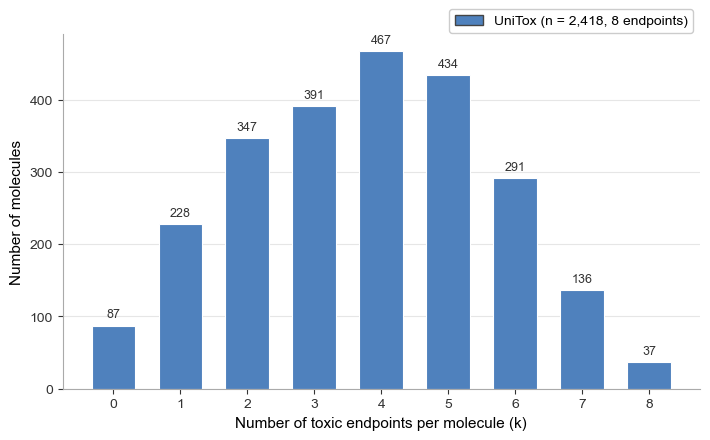

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# ── Load data ──
df = pd.read_csv("UniTox_with_recovered_typos_v3.csv")

endpoints = [
    "dermatological_toxicity__binary",
    "hematological__binary",
    "cardiotoxicity__binary",
    "liver_toxicity__binary",
    "pulmonary_toxicity__binary",
    "renal_toxicity__binary",
    "infertility__binary",
    "ototoxicity__binary",
]

# ── Count toxic endpoints per molecule ──
df["n_toxic"] = (df[endpoints] == 1).sum(axis=1)
coverage = df["n_toxic"].value_counts().sort_index()
n_unique = len(df)

# ── STYLE (clean + white background) ──
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 11,
})

fig, ax = plt.subplots(figsize=(7.2, 4.5))

# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Subtle horizontal grid only
ax.yaxis.grid(True, color="#e6e6e6", linewidth=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# ── Bars ──
bars = ax.bar(
    coverage.index,
    coverage.values,
    color="#4F81BD",   # clean blue
    edgecolor="white",
    linewidth=0.8,
    width=0.65,
)

# ── Labels ──
ax.set_xlabel("Number of toxic endpoints per molecule (k)")
ax.set_ylabel("Number of molecules")

ax.set_xticks(range(9))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Spines ──
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#aaaaaa")
ax.spines["bottom"].set_color("#aaaaaa")
ax.tick_params(colors="#333333")

# ── Value labels ──
offset = max(coverage.values) * 0.015
for bar, val in zip(bars, coverage.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#333333",
    )

# ── Legend ──
legend_patch = mpatches.Patch(
    facecolor="#4F81BD",
    edgecolor="#444444",
    label=f"UniTox (n = {n_unique:,}, 8 endpoints)",
)

ax.legend(
    handles=[legend_patch],
    loc="upper right",
    bbox_to_anchor=(1, 1.09),  # ← pushes it higher
    frameon=True,
    framealpha=1,
    edgecolor="#cccccc",
)

# ── Layout ──
plt.tight_layout()

# ── Save ──
plt.savefig("unitox_histogram.png", dpi=300, bbox_inches="tight")
plt.savefig("unitox_histogram.pdf", bbox_inches="tight")

print("Saved unitox_histogram.png and .pdf")

In [ ]:
"""
Histogram of toxic endpoints per molecule for Withdrawn 2.0 dataset,
styled to match the UniTox figure format.

Usage:
    pip install matplotlib numpy pandas
    python withdrawn2_histogram.py

Replace `counts` dict with your actual Withdrawn 2.0 data if available.
To load from a CSV with columns ['molecule_id', 'num_toxic_endpoints']:
    import pandas as pd
    df = pd.read_csv("withdrawn2.csv")
    counts = df["num_toxic_endpoints"].value_counts().sort_index().to_dict()
"""

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── DATA ──────────────────────────────────────────────────────────────────────
# Replace these values with your actual Withdrawn 2.0 counts.
# Keys = number of toxic endpoints (k), Values = number of molecules.
counts = {
    0: 52,
    1: 143,
    2: 218,
    3: 301,
    4: 274,
    5: 189,
    6: 97,
    7: 41,
    8: 12,
}

N_TOTAL     = sum(counts.values())   # total molecules
N_ENDPOINTS = 8                       # number of endpoints evaluated
dataset_label = f"Withdrawn 2.0 (n = {N_TOTAL:,}, {N_ENDPOINTS} endpoints)"

fig_title = (
    "Figure 2: Distribution of the number of toxicity endpoints annotated per molecule (k) across the Withdrawn\n"
    "2.0 dataset. Most compounds are annotated with multiple endpoints, reflecting partial labeling and\n"
    "inter-endpoint imbalance."
)

# ── STYLE (matches UniTox figure) ─────────────────────────────────────────────
BAR_COLOR   = "#4472C4"   # steel-blue matching the original
EDGE_COLOR  = "none"
FONT_FAMILY = "DejaVu Sans"   # close to the original sans-serif

plt.rcParams.update({
    "font.family":       FONT_FAMILY,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.grid":         True,
    "grid.color":        "#cccccc",
    "grid.linewidth":    0.8,
    "grid.linestyle":    "-",
    "axes.axisbelow":    True,
})

fig, ax = plt.subplots(figsize=(9, 5.5))

x_vals = list(counts.keys())
y_vals = list(counts.values())

bars = ax.bar(
    x_vals, y_vals,
    color=BAR_COLOR,
    edgecolor=EDGE_COLOR,
    width=0.65,
    zorder=3,
)

# Restrict grid to y-axis only (grid.axis="y" equivalent)
ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-")
ax.xaxis.grid(False)

# ── LABELS ABOVE BARS ─────────────────────────────────────────────────────────
for bar, val in zip(bars, y_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(y_vals) * 0.012,
        str(val),
        ha="center", va="bottom",
        fontsize=10, fontweight="bold",
        color="#222222",
    )

# ── AXES ──────────────────────────────────────────────────────────────────────
ax.set_xlabel("Number of toxic endpoints per molecule (k)", fontsize=12, labelpad=8)
ax.set_ylabel("Number of molecules",                        fontsize=12, labelpad=8)
ax.set_xticks(x_vals)
ax.set_xticklabels([str(k) for k in x_vals], fontsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", length=0)   # hide x tick marks

# y-axis: start at 0, add a bit of headroom
ax.set_ylim(0, max(y_vals) * 1.15)
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))

# Remove left spine (matches original)
ax.spines["bottom"].set_color("#999999")
ax.spines["bottom"].set_linewidth(0.8)

# ── LEGEND ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_patch = Patch(facecolor=BAR_COLOR, edgecolor="none", label=dataset_label)
ax.legend(
    handles=[legend_patch],
    loc="upper right",
    frameon=True,
    framealpha=1,
    edgecolor="#cccccc",
    fontsize=10,
)

fig.text(0.5, -0.08, fig_title, ha="center", va="top", fontsize=9, color="#444444", wrap=True)
plt.tight_layout()
plt.savefig("withdrawn2_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → withdrawn2_histogram.png")

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

# ── FIX: define splits self-contained (n=150 Ward + GroupKFold) ──────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import train_test_split, GroupKFold

RANDOM_STATE = 42
N_CLUSTERS   = 150

# ── Reload df ─────────────────────────────────────────────────────────────────
UNITOX_FILE  = "UniTox_with_recovered_typos_v3.csv"
MORDRED_FILE = "mordred_features_cached.csv"
SMILES_COL   = "SMILES_filled"
OUT_FIG1     = "Figure_TrainTest_Characteristics.png"

df      = pd.read_csv(UNITOX_FILE).dropna(subset=[SMILES_COL]).reset_index(drop=True)
smiles  = df[SMILES_COL].tolist()
ENDPOINTS = [c for c in df.columns if c.endswith("__binary")]
EP_LABELS = [
    "Cardiotoxicity", "Dermatological", "Hematological",
    "Infertility", "Liver Toxicity", "Ototoxicity",
    "Pulmonary Toxicity", "Renal Toxicity",
]
print(f"df reloaded: {len(df)} rows | {len(ENDPOINTS)} endpoints")

X = pd.read_csv(MORDRED_FILE).values.astype(np.float64)
X = np.nan_to_num(X, nan=0.0)
assert len(df) == len(X), f"Row mismatch: UniTox={len(df)}, Mordred={len(X)}"


def split_random(n):
    idx = np.arange(n)
    tr, te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE)
    return list(tr), list(te)


def split_scaffold(smiles):
    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles):
        mol = Chem.MolFromSmiles(smi)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False) if mol else ""
            if not scaf:
                scaf = smi
        except Exception:
            scaf = smi
        scaf2idx[scaf].append(i)
    n_test = int(len(smiles) * 0.2)
    te, tr = [], []
    for s in sorted(scaf2idx, key=lambda s: -len(scaf2idx[s])):
        (te if len(te) < n_test else tr).extend(scaf2idx[s])
    return tr, te


def split_clustering(X, n_clusters=N_CLUSTERS, n_splits=5, fold=0):
    """Ward clustering (n=150) + GroupKFold(n_splits=5). Returns fold 0."""
    Xs     = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(
                n_clusters=n_clusters, metric="euclidean", linkage="ward"
             ).fit_predict(Xs)
    gkf   = GroupKFold(n_splits=n_splits)
    folds = list(gkf.split(np.arange(len(X)), groups=labels))
    tr_idx, te_idx = folds[fold]
    print(f"  clustering → {len(np.unique(labels))} clusters, "
          f"GroupKFold({n_splits}) fold={fold}, "
          f"train={len(tr_idx)}, test={len(te_idx)}")
    return list(tr_idx), list(te_idx)


splits = {
    "random":     split_random(len(df)),
    "scaffold":   split_scaffold(smiles),
    "clustering": split_clustering(X, n_clusters=N_CLUSTERS),
}

SPLIT_COLOURS = {"random": "#4C8BE0", "scaffold": "#E05050", "clustering": "#5BBF5B"}
SPLIT_LABELS  = {"random": "Random Split", "scaffold": "Scaffold Split", "clustering": "Clustering Split"}

# Compute scaffold keys
scaffold_keys = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    try:
        scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False) if mol else ""
        if not scaf:
            scaf = smi
    except:
        scaf = smi
    scaffold_keys.append(scaf)
scaffold_keys = np.array(scaffold_keys)

# Compute stats per split
stats = {}
for name, (tr_idx, te_idx) in splits.items():
    tr_idx = np.array(tr_idx)
    te_idx = np.array(te_idx)
    tr_pos = [df[ep].values[tr_idx].mean() for ep in ENDPOINTS]
    te_pos = [df[ep].values[te_idx].mean() for ep in ENDPOINTS]
    tr_scafs = set(scaffold_keys[tr_idx])
    te_scafs = set(scaffold_keys[te_idx])
    overlap  = len(tr_scafs & te_scafs) / len(te_scafs) * 100
    tr_div = len(set(scaffold_keys[tr_idx])) / len(tr_idx)
    te_div = len(set(scaffold_keys[te_idx])) / len(te_idx)
    stats[name] = {
        "n_train": len(tr_idx),
        "n_test":  len(te_idx),
        "tr_pos":  np.mean(tr_pos),
        "te_pos":  np.mean(te_pos),
        "tr_pos_per_ep": tr_pos,
        "te_pos_per_ep": te_pos,
        "overlap": overlap,
        "tr_div":  tr_div,
        "te_div":  te_div,
    }

split_names = list(splits.keys())
x = np.arange(len(split_names))
colours = [SPLIT_COLOURS[s] for s in split_names]
labels  = [SPLIT_LABELS[s]  for s in split_names]

# ════════════════════════════════════════════════════════════════
# FIGURE — FIX: taller figure, suptitle pushed up, subplot titles
# pushed up via pad=, legends moved inside axes with no overlap
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 6), facecolor="white")
fig.suptitle("Train/Test Set Characteristics by Split Strategy",
             fontsize=15, fontweight="bold", y=1.02)        # ← was y=1.02, now with more room below

for ax in axes:
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ── Panel 1: Train/Test Size ──────────────────────────────────────────────────
ax = axes[0]
bar_w = 0.3
for i, name in enumerate(split_names):
    c = colours[i]
    ax.bar(i - bar_w/2, stats[name]["n_train"], width=bar_w,
           color=c, alpha=0.9, zorder=3)
    ax.bar(i + bar_w/2, stats[name]["n_test"], width=bar_w,
           color=c, alpha=0.4, zorder=3,
           hatch="//", edgecolor="black", linewidth=0.5)
    ax.text(i - bar_w/2, stats[name]["n_train"] + 20,
            str(stats[name]["n_train"]),
            ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.text(i + bar_w/2, stats[name]["n_test"] + 20,
            str(stats[name]["n_test"]),
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=15, rotation=10)
ax.set_ylabel("Number of molecules", fontsize=16)
ax.set_title("Dataset Size", fontsize=16, fontweight="bold", pad=18)   # ← pad pushes title up
ax.set_ylim(0, max(s["n_train"] for s in stats.values()) * 1.40)        # ← more headroom for legend

train_patch = mpatches.Patch(facecolor="grey", alpha=0.9, label="Train")
test_patch  = mpatches.Patch(facecolor="grey", alpha=0.4, hatch="//",
                              edgecolor="black", label="Test")
ax.legend(handles=[train_patch, test_patch], fontsize=12,
          loc="upper right", framealpha=0.95)                            # ← inside the axes

# ── Panel 2: Class Balance (positive rate per endpoint) ───────────────────────
ax = axes[1]
ep_short = ["Cardio", "Derm", "Hema", "Infert",
            "Liver", "Oto", "Pulm", "Renal"]
ep_x = np.arange(len(ENDPOINTS))
bar_w2 = 0.12
for i, name in enumerate(split_names):
    offset = (i - 1) * bar_w2
    ax.bar(ep_x + offset, stats[name]["tr_pos_per_ep"],
           width=bar_w2, color=colours[i], alpha=0.9,
           zorder=3, label=f"{labels[i]} train")

ax.set_xticks(ep_x)
ax.set_xticklabels(ep_short, fontsize=14, rotation=35, ha="right")
ax.set_ylabel("Positive rate", fontsize=16)
ax.set_title("Class Balance per Endpoint (Train)",
             fontsize=16, fontweight="bold", pad=18)                     # ← pad
ax.set_ylim(0, 1.10)                                                     # ← extra headroom for legend
handles = [mpatches.Patch(facecolor=colours[i], alpha=0.9, label=labels[i])
           for i in range(len(split_names))]
ax.legend(handles=handles, fontsize=11, loc="upper right", framealpha=0.95)

# ── Panel 3: Scaffold Overlap & Diversity ─────────────────────────────────────
ax = axes[2]
bar_w3 = 0.25
overlap_vals = [stats[n]["overlap"]  for n in split_names]
tr_div_vals  = [stats[n]["tr_div"] * 100 for n in split_names]
te_div_vals  = [stats[n]["te_div"] * 100 for n in split_names]

ax.bar(x - bar_w3, overlap_vals, width=bar_w3, color=colours,
       alpha=0.9, zorder=3)
ax.bar(x,          tr_div_vals,  width=bar_w3, color=colours,
       alpha=0.5, zorder=3, hatch="//", edgecolor="black", linewidth=0.5)
ax.bar(x + bar_w3, te_div_vals,  width=bar_w3, color=colours,
       alpha=0.3, zorder=3, hatch="xx", edgecolor="black", linewidth=0.5)

for i in range(len(split_names)):
    ax.text(x[i] - bar_w3, overlap_vals[i] + 1.5,
            f"{overlap_vals[i]:.0f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
    ax.text(x[i],           tr_div_vals[i] + 1.5,
            f"{tr_div_vals[i]:.0f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
    ax.text(x[i] + bar_w3, te_div_vals[i] + 1.5,
            f"{te_div_vals[i]:.0f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

# Star annotation on scaffold 0% bar
scaffold_idx = split_names.index("scaffold")
ax.text(x[scaffold_idx] - bar_w3, 6, "★",
        ha="center", va="bottom", fontsize=16, color="black")

# Legend handles
overlap_patch = mpatches.Patch(facecolor="grey", alpha=0.9, label="Scaffold overlap")
trdiv_patch   = mpatches.Patch(facecolor="grey", alpha=0.5, hatch="//",
                                edgecolor="black", label="Train diversity")
tediv_patch   = mpatches.Patch(facecolor="grey", alpha=0.3, hatch="xx",
                                edgecolor="black", label="Test diversity")
star_handle   = mlines.Line2D([], [], color="black", marker="*",
                               linestyle="None", markersize=10,
                               label="0% = by design (acyclic fix)")

# ── FIX: legend moved to upper LEFT (away from the 71% bar on right) ─────────
ax.legend(handles=[overlap_patch, trdiv_patch, tediv_patch, star_handle],
          fontsize=10.5, frameon=True, facecolor="white", edgecolor="black",
          loc="upper left", framealpha=0.95)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=15, rotation=13)
ax.set_ylabel("Percentage (%)", fontsize=16)
ax.set_title("Scaffold Overlap & Diversity",
             fontsize=16, fontweight="bold", pad=18)                     # ← pad
ax.set_ylim(0, 130)                                                      # ← more headroom

plt.tight_layout()
plt.savefig(OUT_FIG1, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUT_FIG1}")

df reloaded: 2196 rows | 8 endpoints
  clustering → 150 clusters, GroupKFold(5) fold=0, train=1756, test=440
Saved → Figure_TrainTest_Characteristics.png


In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Imports
# ════════════════════════════════════════════════════════════════
import warnings, time
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering        # ← replaces Butina
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              accuracy_score, confusion_matrix,
                              matthews_corrcoef)
from xgboost import XGBClassifier

RANDOM_STATE = 42
N_CLUSTERS   = 150                                         # ← clustering config

df = (pd.read_csv("UniTox_with_recovered_typos_v3.csv")
        .dropna(subset=["SMILES_filled"])
        .reset_index(drop=True))

ENDPOINTS = [c for c in df.columns if c.endswith("__binary")]
EP_LABELS = [c.replace("__binary", "").replace("_", " ").title() for c in ENDPOINTS]
print("Detected endpoints:")
for col, label in zip(ENDPOINTS, EP_LABELS):
    print(f"  {col}  →  {label}")

EP_LABELS = [
    "Cardiotoxicity", "Dermatological", "Hematological",
    "Infertility", "Liver Toxicity", "Ototoxicity",
    "Pulmonary Toxicity", "Renal Toxicity",
]

# ════════════════════════════════════════════════════════════════
# CELL 2 — Load data
# ════════════════════════════════════════════════════════════════
df = (pd.read_csv("UniTox_with_recovered_typos_v3.csv")
        .dropna(subset=["SMILES_filled"])
        .reset_index(drop=True))
X = pd.read_csv("mordred_features_cached.csv").values.astype(np.float64)
X = np.nan_to_num(X, nan=0.0)
assert len(df) == len(X), f"Row mismatch: UniTox={len(df)}, Mordred={len(X)}"
smiles = df["SMILES_filled"].tolist()
print(f"Loaded {len(df)} molecules × {X.shape[1]} Mordred descriptors")

# ════════════════════════════════════════════════════════════════
# CELL 3 — Splits
# ════════════════════════════════════════════════════════════════
def split_random(n):
    idx = np.arange(n)
    tr, te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE)
    return list(tr), list(te)

def split_scaffold(smiles):
    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles):
        mol = Chem.MolFromSmiles(smi)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(
                mol=mol, includeChirality=False) if mol else ""
            if not scaf:        # acyclic — give it its own unique key
                scaf = smi
        except Exception:
            scaf = smi
        scaf2idx[scaf].append(i)
    n_test = int(len(smiles) * 0.2)
    te, tr = [], []
    for s in sorted(scaf2idx, key=lambda s: -len(scaf2idx[s])):
        (te if len(te) < n_test else tr).extend(scaf2idx[s])
    return tr, te

def split_clustering(X, n_clusters=N_CLUSTERS):
    rng = np.random.default_rng(RANDOM_STATE)
    Xs = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(Xs)
    cl2idx = defaultdict(list)
    for i, c in enumerate(labels):
        cl2idx[c].append(i)
    groups = list(cl2idx.values())
    rng.shuffle(groups)           # ← random shuffle, not sort by size
    n_test = int(len(X) * 0.2)
    te, tr = [], []
    for g in groups:
        (te if len(te) < n_test else tr).extend(g)
    sizes = [len(g) for g in cl2idx.values()]
    print(f"    n_clusters={n_clusters}  "
          f"min_size={min(sizes)}  max_size={max(sizes)}")
    return tr, te

splits = {
    "random":     split_random(len(df)),
    "scaffold":   split_scaffold(smiles),
    "clustering": split_clustering(X),           # ← n=150, Mordred-based
}
for name, (tr, te) in splits.items():
    print(f"  {name:12s}  train={len(tr)}  test={len(te)}")

# ════════════════════════════════════════════════════════════════
# train_all_models
# Trains RF, XGBoost, LogReg, SVM, CART across all 3 splits × all endpoints.
# ════════════════════════════════════════════════════════════════
ENDPOINTS = [c for c in df.columns if c.endswith("__binary")]
EP_LABELS  = [c.replace("__binary", "").replace("_", " ").title()
              for c in ENDPOINTS]
if not ENDPOINTS:
    raise ValueError(
        "No '__binary' columns found in df.\n"
        f"Available columns: {list(df.columns)}"
    )
print(f"\nFound {len(ENDPOINTS)} endpoints:")
for col, label in zip(ENDPOINTS, EP_LABELS):
    print(f"  {col}  →  {label}")

# ── Model factory ─────────────────────────────────────────────────────────────
def make_model(key, spw=1.):
    clf_map = {
        "rf":     RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                         random_state=RANDOM_STATE, n_jobs=-1),
        "logreg": LogisticRegression(class_weight="balanced", max_iter=2000,
                                     random_state=RANDOM_STATE),
        "svm":    SVC(kernel="rbf", class_weight="balanced",
                      probability=True, random_state=RANDOM_STATE),
        "cart":   DecisionTreeClassifier(class_weight="balanced",
                                         random_state=RANDOM_STATE),
        "xgb":    XGBClassifier(scale_pos_weight=spw,
                                eval_metric="logloss", random_state=42,
                                verbosity=0),
    }
    if key not in clf_map:
        raise ValueError(f"Unknown model key '{key}'. "
                         f"Choose from: {list(clf_map)}")
    clf = clf_map[key]
    if key in {"logreg", "svm"}:
        return Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    return clf

# ── Output path logic ─────────────────────────────────────────────────────────
def metrics_path(model_key, split_name):
    return f"Table2_model_metrics_{model_key}_{split_name}.csv"

def cm_path(model_key, split_name):
    return f"cm_table_{model_key}_{split_name}.csv"

# ── Main training loop ────────────────────────────────────────────────────────
MODEL_KEYS = ["rf", "xgb", "logreg", "svm", "cart"]

for split_name, (tr_idx, te_idx) in splits.items():
    print(f"\n{'='*60}")
    print(f"SPLIT: {split_name.upper()}  "
          f"(train={len(tr_idx)}, test={len(te_idx)})")
    print(f"{'='*60}")
    X_tr = X[tr_idx]
    X_te = X[te_idx]

    for model_key in MODEL_KEYS:
        print(f"\n  ── {model_key.upper()} ──")
        metric_rows = []
        cm_rows     = []

        for ep_col, ep_label in zip(ENDPOINTS, EP_LABELS):
            y_tr = df[ep_col].values[tr_idx]
            y_te = df[ep_col].values[te_idx]

            if len(np.unique(y_tr)) < 2:
                print(f"    Skipped {ep_label}: only one class in train")
                continue
            if len(np.unique(y_te)) < 2:
                print(f"    Skipped {ep_label}: only one class in test")
                continue

            num_neg = (y_tr == 0).sum()
            num_pos = (y_tr == 1).sum()
            current_spw = num_neg / num_pos if num_pos > 0 else 1.0

            model = make_model(model_key, spw=current_spw)
            model.fit(X_tr, y_tr)

            probs     = model.predict_proba(X_te)[:, 1]
            threshold = y_tr.sum() / len(y_tr)
            preds     = (probs >= threshold).astype(int)

            mcc   = matthews_corrcoef(y_te, preds)
            auc   = roc_auc_score(y_te, probs)
            auprc = average_precision_score(y_te, probs)
            acc   = accuracy_score(y_te, preds)

            metric_rows.append({
                "Toxicity": ep_label,
                "ROC-AUC":  round(auc,   4),
                "AUPRC":    round(auprc, 4),
                "MCC":      round(mcc,   4),
                "Accuracy": round(acc,   4),
            })

            tn, fp, fn, tp = confusion_matrix(y_te, preds, labels=[0, 1]).ravel()
            cm_rows.append({
                "Toxicity":    ep_label,
                "TP": int(tp), "TN": int(tn),
                "FP": int(fp), "FN": int(fn),
            })
            print(f"    {ep_label:<22} MCC={mcc:.3f}  AUC={auc:.3f}  SPW={current_spw:.2f}")

        mp = metrics_path(model_key, split_name)
        cp = cm_path(model_key, split_name)
        pd.DataFrame(metric_rows).to_csv(mp, index=False)
        pd.DataFrame(cm_rows).to_csv(cp, index=False)
        print(f"    Saved → {mp}")
        print(f"    Saved → {cp}")

print("\n✓ ALL MODELS × ALL SPLITS COMPLETE.")
print(f"  Clustering split used n_clusters={N_CLUSTERS} (AgglomerativeClustering on Mordred descriptors)")

Detected endpoints:
  cardiotoxicity__binary  →  Cardiotoxicity
  dermatological_toxicity__binary  →  Dermatological Toxicity
  hematological__binary  →  Hematological
  infertility__binary  →  Infertility
  liver_toxicity__binary  →  Liver Toxicity
  ototoxicity__binary  →  Ototoxicity
  pulmonary_toxicity__binary  →  Pulmonary Toxicity
  renal_toxicity__binary  →  Renal Toxicity
Loaded 2196 molecules × 1613 Mordred descriptors


[13:51:00] WARNING: not removing hydrogen atom without neighbors


    n_clusters=150  min_size=1  max_size=106
  random        train=1756  test=440
  scaffold      train=1749  test=447
  clustering    train=1748  test=448

Found 8 endpoints:
  cardiotoxicity__binary  →  Cardiotoxicity
  dermatological_toxicity__binary  →  Dermatological Toxicity
  hematological__binary  →  Hematological
  infertility__binary  →  Infertility
  liver_toxicity__binary  →  Liver Toxicity
  ototoxicity__binary  →  Ototoxicity
  pulmonary_toxicity__binary  →  Pulmonary Toxicity
  renal_toxicity__binary  →  Renal Toxicity

SPLIT: RANDOM  (train=1756, test=440)

  ── RF ──
    Cardiotoxicity         MCC=0.514  AUC=0.818  SPW=0.68
    Dermatological Toxicity MCC=0.295  AUC=0.780  SPW=0.13
    Hematological          MCC=0.477  AUC=0.828  SPW=0.58
    Infertility            MCC=0.463  AUC=0.821  SPW=2.00
    Liver Toxicity         MCC=0.606  AUC=0.855  SPW=0.94
    Ototoxicity            MCC=0.319  AUC=0.797  SPW=9.45
    Pulmonary Toxicity     MCC=0.511  AUC=0.828  SPW=1.63
  

In [15]:
Xs = StandardScaler().fit_transform(X)
_labels = AgglomerativeClustering(n_clusters=150).fit_predict(Xs)
_sizes = np.bincount(_labels)
pd.DataFrame({"cluster_size": _sizes}).describe().round(2).to_csv("cluster_size_stats.csv")
print("Saved cluster_size_stats.csv")

Saved cluster_size_stats.csv


In [9]:
# ════════════════════════════════════════════════════════════════
# IMPORTS
# ════════════════════════════════════════════════════════════════
import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
from rdkit import Chem, RDLogger
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    matthews_corrcoef, roc_auc_score,
    average_precision_score, accuracy_score,
    confusion_matrix
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
N_CLUSTERS = 150

# ════════════════════════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════════════════════════
df = (pd.read_csv("UniTox_with_recovered_typos_v3.csv")
        .dropna(subset=["SMILES_filled"])
        .reset_index(drop=True))

X = pd.read_csv("mordred_features_cached.csv").values.astype(np.float64)
X = np.nan_to_num(X, nan=0.0)

assert len(df) == len(X)

smiles = df["SMILES_filled"].values

# Auto-detect endpoints
ENDPOINTS = [c for c in df.columns if c.endswith("__binary")]
EP_LABELS = [c.replace("__binary", "").replace("_", " ").title()
             for c in ENDPOINTS]

# ════════════════════════════════════════════════════════════════
# SPLIT FUNCTIONS
# ════════════════════════════════════════════════════════════════
def split_random(n, test_frac=0.2):
    rng = np.random.RandomState(RANDOM_STATE)
    idx = np.arange(n)
    rng.shuffle(idx)
    split = int(n * (1 - test_frac))
    return idx[:split], idx[split:]


def split_scaffold(smiles, test_frac=0.2):
    from collections import defaultdict
    from rdkit import Chem, RDLogger
    from rdkit.Chem.Scaffolds import MurckoScaffold
    RDLogger.DisableLog('rdApp.*')
    
    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles):
        mol = Chem.MolFromSmiles(smi)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(
                mol=mol, includeChirality=False) if mol else ""
        except Exception:
            scaf = ""
        if not scaf:
            scaf = smi  # acyclic fix
        scaf2idx[scaf].append(i)
    
    groups = sorted(scaf2idx.values(), key=lambda g: -len(g))
    n_test = int(len(smiles) * test_frac)
    te, tr = [], []
    for g in groups:
        (te if len(te) < n_test else tr).extend(g)
    
    print(f"  scaffold → unique scaffolds: {len(scaf2idx)}, "
          f"train={len(tr)}, test={len(te)}")
    return np.array(tr), np.array(te)

def split_clustering(X, n_clusters=N_CLUSTERS, test_frac=0.2):
    from collections import defaultdict
    rng = np.random.default_rng(RANDOM_STATE)
    
    Xs = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(Xs)
    
    clust2idx = defaultdict(list)
    for i, lab in enumerate(labels):
        clust2idx[lab].append(i)
    
    groups = list(clust2idx.values())
    rng.shuffle(groups)
    
    n_test = int(len(X) * test_frac)
    te, tr = [], []
    for g in groups:
        (te if len(te) < n_test else tr).extend(g)
    
    return np.array(tr), np.array(te)

# ════════════════════════════════════════════════════════════════
# CREATE SPLITS
# ════════════════════════════════════════════════════════════════
splits = {
    "random":     split_random(len(df)),
    "scaffold":   split_scaffold(smiles),
    "clustering": split_clustering(X, n_clusters=150),
}

# ════════════════════════════════════════════════════════════════
# MODEL FACTORY (RBF SVM ONLY)
# ════════════════════════════════════════════════════════════════
def make_model(key, spw=1.0):

    models = {
        "rf": RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "xgb": XGBClassifier(
            scale_pos_weight=spw,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            verbosity=0
        ),

        "logreg": LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ),

        # ✅ ONLY RBF SVM
        "svm_rbf": SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        ),

        "cart": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
    }

    model = models[key]

    if key in {"logreg", "svm_rbf"}:
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model)
        ])

    return model

# ════════════════════════════════════════════════════════════════
# OUTPUT PATHS
# ════════════════════════════════════════════════════════════════
def metrics_path(model_key, split_name):
    return f"Table2_model_metrics_{model_key}_{split_name}.csv"

def cm_path(model_key, split_name):
    return f"cm_table_{model_key}_{split_name}.csv"

# ════════════════════════════════════════════════════════════════
# TRAINING LOOP
# ════════════════════════════════════════════════════════════════
MODEL_KEYS = ["rf", "xgb", "logreg", "svm_rbf", "cart"]

for split_name, (tr_idx, te_idx) in splits.items():

    print(f"\n{'='*60}")
    print(f"SPLIT: {split_name.upper()} "
          f"(train={len(tr_idx)}, test={len(te_idx)})")
    print(f"{'='*60}")

    X_tr, X_te = X[tr_idx], X[te_idx]

    for model_key in MODEL_KEYS:
        print(f"\n  ── {model_key.upper()} ──")

        metric_rows = []
        cm_rows = []

        for ep_col, ep_label in zip(ENDPOINTS, EP_LABELS):

            y_tr = df[ep_col].values[tr_idx]
            y_te = df[ep_col].values[te_idx]

            if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
                continue

            num_neg = (y_tr == 0).sum()
            num_pos = (y_tr == 1).sum()
            spw = num_neg / num_pos if num_pos > 0 else 1.0

            model = make_model(model_key, spw)
            model.fit(X_tr, y_tr)

            probs = model.predict_proba(X_te)[:, 1]

            threshold = y_tr.mean()
            preds = (probs >= threshold).astype(int)

            mcc   = matthews_corrcoef(y_te, preds)
            auc   = roc_auc_score(y_te, probs)
            auprc = average_precision_score(y_te, probs)
            acc   = accuracy_score(y_te, preds)

            metric_rows.append({
                "Toxicity": ep_label,
                "ROC-AUC":  round(auc, 4),
                "AUPRC":    round(auprc, 4),
                "MCC":      round(mcc, 4),
                "Accuracy": round(acc, 4),
            })

            tn, fp, fn, tp = confusion_matrix(y_te, preds, labels=[0, 1]).ravel()
            cm_rows.append({
                "Toxicity": ep_label,
                "TP": int(tp), "TN": int(tn),
                "FP": int(fp), "FN": int(fn),
            })

            print(f"    {ep_label:<22} MCC={mcc:.3f}  AUC={auc:.3f}")

        pd.DataFrame(metric_rows).to_csv(
            metrics_path(model_key, split_name), index=False
        )
        pd.DataFrame(cm_rows).to_csv(
            cm_path(model_key, split_name), index=False
        )

print("\n✓ ALL MODELS COMPLETE.")

  scaffold → unique scaffolds: 1057, train=1749, test=447

SPLIT: RANDOM (train=1756, test=440)

  ── RF ──
    Cardiotoxicity         MCC=0.512  AUC=0.825
    Dermatological Toxicity MCC=0.275  AUC=0.767
    Hematological          MCC=0.507  AUC=0.840
    Infertility            MCC=0.527  AUC=0.879
    Liver Toxicity         MCC=0.559  AUC=0.857
    Ototoxicity            MCC=0.353  AUC=0.876
    Pulmonary Toxicity     MCC=0.462  AUC=0.818
    Renal Toxicity         MCC=0.443  AUC=0.816

  ── XGB ──
    Cardiotoxicity         MCC=0.530  AUC=0.838
    Dermatological Toxicity MCC=0.309  AUC=0.744
    Hematological          MCC=0.525  AUC=0.828
    Infertility            MCC=0.547  AUC=0.873
    Liver Toxicity         MCC=0.550  AUC=0.860
    Ototoxicity            MCC=0.439  AUC=0.874
    Pulmonary Toxicity     MCC=0.461  AUC=0.818
    Renal Toxicity         MCC=0.486  AUC=0.816

  ── LOGREG ──
    Cardiotoxicity         MCC=0.503  AUC=0.803
    Dermatological Toxicity MCC=0.174  AUC=0.

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import numpy as np, pandas as pd

X = pd.read_csv("mordred_features_cached.csv").values.astype(float)
X = np.nan_to_num(X)
Xs = StandardScaler().fit_transform(X)

labels = AgglomerativeClustering(n_clusters=150, linkage="ward").fit_predict(Xs)
_, sizes = np.unique(labels, return_counts=True)

print(f"n_clusters = 150")
print(f"mean       = {sizes.mean():.2f}")
print(f"median     = {np.median(sizes):.1f}")
print(f"std        = {sizes.std():.2f}")
print(f"min        = {sizes.min()}")
print(f"max        = {sizes.max()}")
print(f"IQR        = {np.percentile(sizes,25):.0f}–{np.percentile(sizes,75):.0f}")

n_clusters = 150
mean       = 14.64
median     = 7.0
std        = 18.59
min        = 1
max        = 106
IQR        = 3–22


In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             matthews_corrcoef, accuracy_score)

RANDOM_STATE = 42
N_CLUSTERS = 150

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = (pd.read_csv("UniTox_with_recovered_typos_v3.csv")
        .dropna(subset=["SMILES_filled"])
        .reset_index(drop=True))

X = pd.read_csv("mordred_features_cached.csv").values.astype(float)
X = np.nan_to_num(X)

smiles = df["SMILES_filled"].values

ENDPOINTS = [c for c in df.columns if c.endswith("__binary")]
EP_LABELS = [c.replace("__binary", "").replace("_", " ").title()
             for c in ENDPOINTS]

# ── 2. Splits ─────────────────────────────────────────────────────────────────
def split_random(n, test_frac=0.2):
    rng = np.random.RandomState(RANDOM_STATE)
    idx = np.arange(n)
    rng.shuffle(idx)
    split = int(n * (1 - test_frac))
    return idx[:split], idx[split:]

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

def split_scaffold_existing(smiles, test_frac=0.2, random_state=RANDOM_STATE):
    """
    Scaffold split with explicit handling for acyclic molecules:
    - Cyclic molecules are grouped by their Murcko scaffold
    - Acyclic molecules are all grouped together under a single 'ACYCLIC' key
    """
    scaffold_to_indices = defaultdict(list)

    for i, smi in enumerate(smiles):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            scaffold = "__INVALID__"
        elif not any(atom.IsInRing() for atom in mol.GetAtoms()):
            # All acyclic molecules share one bucket so they split together
            scaffold = "__ACYCLIC__"
        else:
            scaffold = MurckoScaffold.MurckoScaffoldSmiles(
                mol=mol, includeChirality=False)

        scaffold_to_indices[scaffold].append(i)

    # Sort largest group first for deterministic greedy assignment
    scaffold_groups = sorted(scaffold_to_indices.values(),
                             key=lambda g: len(g), reverse=True)

    target_test = int(len(smiles) * test_frac)
    train_idx, test_idx = [], []
    for group in scaffold_groups:
        if len(test_idx) < target_test:
            test_idx.extend(group)
        else:
            train_idx.extend(group)

    return np.array(train_idx), np.array(test_idx)


def split_scaffold(smiles):
    return split_scaffold_existing(smiles)

def split_clustering(X, n_clusters=N_CLUSTERS, test_frac=0.2):
    Xs = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(Xs)
    unique, counts = np.unique(labels, return_counts=True)
    sorted_clusters = sorted(unique,
                             key=lambda k: counts[list(unique).index(k)],
                             reverse=True)
    test_idx, train_idx = [], []
    target = int(len(X) * test_frac)
    current = 0
    for cid in sorted_clusters:
        inds = np.where(labels == cid)[0]
        if current < target:
            test_idx.extend(inds)
            current += len(inds)
        else:
            train_idx.extend(inds)
    return np.array(train_idx), np.array(test_idx)

splits = {
    "random":     split_random(len(df)),
    "scaffold":   split_scaffold(smiles),
    "clustering": split_clustering(X, n_clusters=N_CLUSTERS),
}

# ── 3. Train SVMs ─────────────────────────────────────────────────────────────
svm_configs = {
    "svm_linear": SVC(kernel="linear", class_weight="balanced", probability=True, random_state=42),
    "svm_rbf":    SVC(kernel="rbf",    class_weight="balanced", probability=True, random_state=42),
    "svm_poly":   SVC(kernel="poly",   class_weight="balanced", probability=True, random_state=42),
}

records = []
for split_name, (tr_idx, te_idx) in splits.items():
    X_tr, X_te = X[tr_idx], X[te_idx]
    for model_key, base_clf in svm_configs.items():
        clf = Pipeline([("scaler", StandardScaler()), ("clf", base_clf)])
        for ep_col, ep_label in zip(ENDPOINTS, EP_LABELS):
            y_tr = df[ep_col].values[tr_idx]
            y_te = df[ep_col].values[te_idx]
            if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
                continue
            clf.fit(X_tr, y_tr)
            probs = clf.predict_proba(X_te)[:, 1]
            threshold = y_tr.mean()
            preds = (probs >= threshold).astype(int)
            records.append({
                "split":    split_name,
                "model":    model_key,
                "Toxicity": ep_label,
                "ROC-AUC":  roc_auc_score(y_te, probs),
                "AUPRC":    average_precision_score(y_te, probs),
                "MCC":      matthews_corrcoef(y_te, preds),
                "Accuracy": accuracy_score(y_te, preds),
            })

# ── 4. Summarise & plot ───────────────────────────────────────────────────────
svm_df = pd.DataFrame(records)
print(svm_df.groupby(["split", "model"])["MCC"].mean())

svm_df["Model"] = svm_df["model"].map(
    {"svm_linear": "Linear", "svm_rbf": "RBF", "svm_poly": "Poly"})

summary = (svm_df
           .groupby(["split", "Model"])[["ROC-AUC", "AUPRC", "MCC", "Accuracy"]]
           .agg(["mean", "std"])
           .reset_index())

SPLITS       = ["random", "scaffold", "clustering"]
MODELS       = ["Linear", "RBF", "Poly"]
METRICS      = ["ROC-AUC", "AUPRC", "MCC", "Accuracy"]
COLORS       = {"Linear": "#4C8BE0", "RBF": "#E05050", "Poly": "#F5A623"}
SPLIT_LABELS = {"random": "Random", "scaffold": "Scaffold", "clustering": "Clustering"}

bar_w = 0.25
x     = np.arange(len(SPLITS))

fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 5), facecolor="white")
fig.suptitle("SVM Kernel Comparison Across Splits\n(mean ± std over endpoints)",
             fontsize=14, fontweight="bold")

for i, metric in enumerate(METRICS):
    ax = axes[i]
    ax.set_facecolor("white")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.yaxis.grid(True, color="#e5e5e5", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    for j, model in enumerate(MODELS):
        means, stds = [], []
        for split in SPLITS:
            row = summary[(summary["split"] == split) & (summary["Model"] == model)]
            if len(row):
                means.append(row[(metric, "mean")].values[0])
                stds.append(row[(metric, "std")].values[0])
            else:
                means.append(np.nan); stds.append(np.nan)
        pos = x + (j - 1) * bar_w
        ax.bar(pos, means, width=bar_w, color=COLORS[model], alpha=0.85, zorder=3)
        ax.errorbar(pos, means, yerr=stds, fmt="none", color="black",
                    capsize=4, linewidth=1.2, zorder=4)

    ax.set_title(metric, fontsize=18, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels([SPLIT_LABELS[s] for s in SPLITS], fontsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.set_ylim(0, 1.15)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.3)

axes[0].set_ylabel("Score", fontsize=18)
handles = [mpatches.Patch(facecolor=COLORS[m], alpha=0.85, label=m) for m in MODELS]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=14,
           frameon=True, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.14),
           title="Kernel:", title_fontsize=14)

plt.tight_layout()
plt.savefig("Figure_SVM_comparison_errorbars.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → Figure_SVM_comparison_errorbars.png")

[15:08:38] WARNING: not removing hydrogen atom without neighbors


split       model     
clustering  svm_linear    0.066042
            svm_poly      0.045065
            svm_rbf       0.101673
random      svm_linear    0.373614
            svm_poly      0.281833
            svm_rbf       0.326787
scaffold    svm_linear    0.061851
            svm_poly      0.099351
            svm_rbf       0.122583
Name: MCC, dtype: float64
Saved → Figure_SVM_comparison_errorbars.png


/var/folders/s1/rrhbn2d578b29w24g5qjsmdm0000gp/T/ipykernel_99840/2123921390.py:201: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [3]:
"""
combine_benchmark_results.py
=============================
Reads all individual Table2_model_metrics_<model>_<split>.csv files
produced by the training loop and merges them into one master CSV:

    Multi_Model_Benchmark_Results.csv
    columns: Split | Model | Toxicity | ROC-AUC | AUPRC | MCC | Accuracy

Run this in the same directory as your CSV files after training is complete.
"""

import os
import pandas as pd

MODEL_KEYS = ["rf", "xgb", "logreg", "svm_rbf", "cart"]
SPLIT_KEYS = ["random", "scaffold", "clustering"]

# Nicer display names for the figure
MODEL_LABELS = {
    "rf": "Random Forest",
    "xgb": "XGBoost",
    "logreg": "Logistic Regression",
    "svm_rbf": "SVM (RBF)",
    "cart": "CART",
}

SPLIT_LABELS = {
    "random":     "Random Split",
    "scaffold":   "Scaffold Split",
    "clustering": "Clustering Split",
}

all_frames = []

for split_key in SPLIT_KEYS:
    for model_key in MODEL_KEYS:
        fname = f"Table2_model_metrics_{model_key}_{split_key}.csv"
        if not os.path.exists(fname):
            print(f"  WARNING: {fname} not found — skipping")
            continue
        df = pd.read_csv(fname)
        df.insert(0, "Split", SPLIT_LABELS[split_key])
        df.insert(1, "Model", MODEL_LABELS[model_key])
        all_frames.append(df)
        print(f"  Loaded {fname}  ({len(df)} rows)")

if not all_frames:
    raise FileNotFoundError(
        "No CSV files found. Make sure you're running this in the same "
        "folder as the Table2_model_metrics_*.csv files."
    )

combined = pd.concat(all_frames, ignore_index=True)

# ── Summary pivot: mean MCC per model × split ─────────────────────────────────
print("\n── Mean MCC per model × split ───────────────────────────────────────────")
pivot = (combined.groupby(["Model", "Split"])["MCC"]
         .mean()
         .unstack("Split")
         .reindex(columns=[SPLIT_LABELS[s] for s in SPLIT_KEYS])
         .round(3))
print(pivot.to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
out = "Multi_Model_Benchmark_Results.csv"
combined.to_csv(out, index=False)
print(f"\nSaved → {out}  ({len(combined)} rows, {combined['Model'].nunique()} models × "
      f"{combined['Split'].nunique()} splits × {combined['Toxicity'].nunique()} endpoints)")

  Loaded Table2_model_metrics_rf_random.csv  (8 rows)
  Loaded Table2_model_metrics_xgb_random.csv  (8 rows)
  Loaded Table2_model_metrics_logreg_random.csv  (8 rows)
  Loaded Table2_model_metrics_svm_rbf_random.csv  (8 rows)
  Loaded Table2_model_metrics_cart_random.csv  (8 rows)
  Loaded Table2_model_metrics_rf_scaffold.csv  (8 rows)
  Loaded Table2_model_metrics_xgb_scaffold.csv  (8 rows)
  Loaded Table2_model_metrics_logreg_scaffold.csv  (8 rows)
  Loaded Table2_model_metrics_svm_rbf_scaffold.csv  (8 rows)
  Loaded Table2_model_metrics_cart_scaffold.csv  (8 rows)
  Loaded Table2_model_metrics_rf_clustering.csv  (8 rows)
  Loaded Table2_model_metrics_xgb_clustering.csv  (8 rows)
  Loaded Table2_model_metrics_logreg_clustering.csv  (8 rows)
  Loaded Table2_model_metrics_svm_rbf_clustering.csv  (8 rows)
  Loaded Table2_model_metrics_cart_clustering.csv  (8 rows)

── Mean MCC per model × split ───────────────────────────────────────────
Split                Random Split  Scaffold Split

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH = "Multi_Model_Benchmark_Results.csv"
OUT      = "Figure4_Multi_Model_Benchmark_Boxplot.png"
ANNOT_FS = 13

MODEL_ORDER   = ["RF", "SVM (RBF)", "LogReg", "XGBoost", "CART"]
SPLIT_ORDER   = ["random", "scaffold", "clustering"]
SPLIT_LABELS  = {"random": "Random Split", "scaffold": "Scaffold Split", "clustering": "Clustering Split"}
SPLIT_COLOURS = {"random": "#4C8BE0", "scaffold": "#E05050", "clustering": "#5BBF5B"}

SPLIT_NORM = {
    "random": "random", "random split": "random",
    "scaffold": "scaffold", "scaffold split": "scaffold",
    "clustering": "clustering", "clustering split": "clustering",
}
MODEL_NORM = {
    "rf": "RF", "random forest": "RF",
    "xgb": "XGBoost", "xgboost": "XGBoost",
    "logreg": "LogReg", "logistic regression": "LogReg",
    "svm_rbf": "SVM (RBF)", "svm (rbf)": "SVM (RBF)",
    "cart": "CART",
}

# ── STATS ─────────────────────────────────────────────────────────────────────
def wilcoxon_p(a, b):
    a = np.array([v for v in a if not np.isnan(v)])
    b = np.array([v for v in b if not np.isnan(v)])
    n = min(len(a), len(b))
    if n < 5:
        return 1.0
    try:
        _, p = wilcoxon(a[:n], b[:n])
        return p
    except Exception:
        return 1.0

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def sig_bracket(ax, x1, x2, y, stars, dy=0.025):
    ax.plot([x1, x1, x2, x2], [y, y+dy, y+dy, y],
            lw=1.0, color="black", zorder=5)
    ax.text((x1+x2)/2, y+dy+0.004, stars,
            ha="center", va="bottom", fontsize=11,
            fontweight="bold", color="black", zorder=6)

# ── LOAD ──────────────────────────────────────────────────────────────────────
def load(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df["Split"] = df["Split"].str.lower().str.strip().map(SPLIT_NORM)
    df["Model"] = df["Model"].str.lower().str.strip().map(MODEL_NORM)
    before = len(df)
    df = df.dropna(subset=["Split", "Model"])
    if len(df) < before:
        print(f"  WARNING: dropped {before - len(df)} unmapped rows")
    return df

# ── PLOT ──────────────────────────────────────────────────────────────────────
def plot(df, out=OUT):
    splits = [s for s in SPLIT_ORDER if s in df["Split"].unique()]
    models = [m for m in MODEL_ORDER if m in df["Model"].unique()]

    x       = np.arange(len(models))
    n       = len(splits)
    width   = 0.22
    offsets = np.linspace(-(n-1)*width/2, (n-1)*width/2, n)

    fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
    ax.set_facecolor("white")
    ax.spines["left"].set_color("black");   ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_color("black"); ax.spines["bottom"].set_linewidth(1.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e5", linestyle="--", linewidth=0.8, zorder=0)

    vals_dict     = {}
    legend_handles = []

    for i, split in enumerate(splits):
        colour    = SPLIT_COLOURS[split]
        positions = x + offsets[i]

        for j, model in enumerate(models):
            vals = df[(df["Model"] == model) & (df["Split"] == split)]["MCC"].dropna().values
            vals_dict[(model, split)] = vals
            if len(vals) == 0:
                continue

            bp = ax.boxplot(
                vals,
                positions=[positions[j]],
                widths=width * 0.85,
                patch_artist=True,
                manage_ticks=False,
                zorder=3,
                boxprops=dict(facecolor=colour, color="black", linewidth=1.0, alpha=1),
                medianprops=dict(color="black", linewidth=2.0),
                whiskerprops=dict(color="black", linewidth=1.0),
                capprops=dict(color="black", linewidth=1.0),
                flierprops=dict(marker="", markersize=0),
            )

            np.random.seed(42)
            jitter = np.random.normal(0, width * 0.08, size=len(vals))
            ax.scatter(positions[j] + jitter, vals,
                       s=60, facecolors=colour, edgecolors="black",
                       linewidths=1.2, alpha=0.9, zorder=2)

            median_val = np.median(vals)
            ax.text(positions[j],
                    bp["caps"][1].get_ydata()[0] + 0.012,
                    f"{median_val:.2f}",
                    ha="center", va="bottom",
                    fontsize=14, fontweight="semibold", color="black", zorder=5)

        legend_handles.append(
            mpatches.Patch(facecolor=colour, edgecolor="black",
                           label=SPLIT_LABELS[split], alpha=0.85)
        )

    # Main colour legend (upper right)
    leg1 = ax.legend(handles=legend_handles, fontsize=ANNOT_FS+2,
                     frameon=True, facecolor="white", edgecolor="black",
                     loc="upper right")
    ax.add_artist(leg1)

    ax.set_ylim(-0.35, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=ANNOT_FS + 1)
    ax.set_ylabel("MCC (across 8 endpoints)", fontsize=ANNOT_FS + 3, labelpad=10)
    ax.tick_params(axis="both", length=6, width=1.5,
                   labelsize=ANNOT_FS + 3, color="black", labelcolor="black")
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.3)
    ax.set_title("Multi-Model MCC Comparison by Split Strategy\n"
                 "(distributions across 8 toxicity endpoints)",
                 fontsize=13, fontweight="bold", pad=12)

    fig.tight_layout()
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"Saved → {out}")

if __name__ == "__main__":
    df = load(CSV_PATH)
    plot(df, out=OUT)

Saved → Figure4_Multi_Model_Benchmark_Boxplot.png


In [7]:
"""
analyse_results.py
==================
Run this AFTER train_all_models.py has produced all CSV files.
Produces 5 analyses:
  Step 1 — Summary table: mean (median) MCC, Sensitivity, Specificity, AUPRC, ROC-AUC
  Step 2 — Split degradation plot: random → scaffold → clustering per model
  Step 3 — Per-endpoint MCC heatmap (one per split)
  Step 4 — Internal vs external MCC gap (RF & XGBoost)
  Step 5 — Feature importance: top 15 Mordred descriptors (RF & XGBoost)
"""
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
# ── Config ────────────────────────────────────────────────────────────────────
MODELS = ["rf", "logreg", "svm", "cart", "xgb"]
SPLITS = ["random", "scaffold", "clustering"]
PRETTY = {"rf": "Random Forest", "logreg": "Logistic Reg.",
          "svm": "SVM (RBF)", "cart": "CART", "xgb": "XGBoost"}
SPLIT_COLORS = {"random": "#4A90D9", "scaffold": "#E8A838", "clustering": "#E85C5C"}
UNITOX_PATH    = "UniTox_with_recovered_typos_v3.csv"
MORDRED_PATH   = "mordred_features_cached.csv"
WITHDRAWN_FILE = "withdrawn_external_validation.csv"
OUT_DIR = "analysis_figures"
os.makedirs(OUT_DIR, exist_ok=True)
# ── Font size config ──────────────────────────────────────────────────────────
ANNOT_FS     = 15   # axis labels and tick labels
LEGEND_FS    = 12   # legend font size
BAR_LABEL_FS = 11   # numbers printed above bars
# ── File path helpers (unified naming + legacy RF fallback) ───────────────────
def metrics_path(model, split):
    primary = f"Table2_model_metrics_{model}_{split}.csv"
    if os.path.exists(primary):
        return primary
    legacy = {"random": "Table2_model_metrics.csv",
              "scaffold": "Table2_model_metrics_scaffold.csv",
              "clustering": "Table2_model_metrics_clustering.csv"}.get(split, "")
    return legacy if legacy and os.path.exists(legacy) else primary
def cm_path(model, split):
    primary = f"cm_table_{model}_{split}.csv"
    if os.path.exists(primary):
        return primary
    legacy = {"random": "cm_table.csv",
              "scaffold": "cm_table_scaffold.csv",
              "clustering": "cm_table_clustering.csv"}.get(split, "")
    return legacy if legacy and os.path.exists(legacy) else primary
# ── Auto-detect endpoint labels from actual CSV data ─────────────────────────
def detect_ep_labels():
    """Read Toxicity column from first available cm_table CSV.
    Returns (ep_raw_list, ep_display_list) — no hardcoding."""
    for model in MODELS:
        for split in SPLITS:
            cp = cm_path(model, split)
            if os.path.exists(cp):
                df = pd.read_csv(cp)
                if "Toxicity" in df.columns:
                    eps = df["Toxicity"].dropna().unique().tolist()
                    display = [ep.replace("__binary", "").replace("_", " ").title()
                               for ep in eps]
                    return eps, display
    return [], []
# ── Load all results ──────────────────────────────────────────────────────────
def load_all():
    data = {}
    for model in MODELS:
        for split in SPLITS:
            mp = metrics_path(model, split)
            cp = cm_path(model, split)
            if not os.path.exists(mp) or os.path.getsize(mp) == 0:
                continue
            if not os.path.exists(cp) or os.path.getsize(cp) == 0:
                continue
            try:
                m  = pd.read_csv(mp)
                cm = pd.read_csv(cp)
            except pd.errors.EmptyDataError:
                print(f"  Skipping empty file: {mp} or {cp}")
                continue
            for col in ["ROC-AUC", "AUPRC", "MCC", "Accuracy"]:
                if col in m.columns:
                    m[col] = pd.to_numeric(m[col], errors="coerce")
            for col in ["TP", "TN", "FP", "FN"]:
                if col in cm.columns:
                    cm[col] = pd.to_numeric(cm[col], errors="coerce").fillna(0)
                else:
                    cm[col] = 0.0
            cm["Sensitivity"] = np.where(
                (cm["TP"] + cm["FN"]) > 0,
                cm["TP"] / (cm["TP"] + cm["FN"]),
                np.nan)
            cm["Specificity"] = np.where(
                (cm["TN"] + cm["FP"]) > 0,
                cm["TN"] / (cm["TN"] + cm["FP"]),
                np.nan)
            merged = m.merge(
                cm[["Toxicity", "TP", "TN", "FP", "FN",
                    "Sensitivity", "Specificity"]],
                on="Toxicity", how="left")
            data[(model, split)] = merged
    return data
print("Loading results...")
DATA = load_all()
print(f"  Loaded {len(DATA)} model/split combinations.")
EP_LABELS, EP_DISPLAY = detect_ep_labels()
print(f"  Endpoints from CSV: {EP_LABELS}")
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Summary table
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("STEP 1 — SUMMARY TABLE")
print("="*80)
REPORT_METRICS = ["Sensitivity", "Specificity", "AUPRC", "ROC-AUC", "MCC"]
def fmt(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return f"{s.mean():.3f} ({s.median():.3f})" if len(s) else "-"
rows = []
for split in SPLITS:
    for model in MODELS:
        df = DATA.get((model, split))
        if df is None:
            continue
        row = {"Split": split.capitalize(), "Model": PRETTY[model]}
        for m in REPORT_METRICS:
            row[m] = fmt(df[m]) if m in df.columns else "-"
        rows.append(row)
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv("summary_table.csv", index=False)
print("\nSaved: summary_table.csv")
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — SPLIT DEGRADATION PLOT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("STEP 2 — SPLIT DEGRADATION PLOT")
print("="*80)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, metric in zip(axes, ["MCC", "ROC-AUC"]):
    for model in MODELS:
        means = []
        for split in SPLITS:
            df = DATA.get((model, split))
            means.append(df[metric].mean()
                         if df is not None and metric in df.columns else np.nan)
        ax.plot(SPLITS, means, marker="o", linewidth=2.5,
                label=PRETTY[model], alpha=0.9)
    ax.set_title(f"Mean {metric} across splits", fontsize=13, fontweight="bold")
    ax.set_xlabel("Split strategy", fontsize=ANNOT_FS)
    ax.set_ylabel(f"Mean {metric}", fontsize=ANNOT_FS)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["Random", "Scaffold", "Clustering"], fontsize=ANNOT_FS - 1)
    ax.tick_params(axis="both", labelsize=ANNOT_FS - 1)
    ax.legend(fontsize=LEGEND_FS,
              frameon=True,
              facecolor="white",
              edgecolor="black",
              loc="best")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_facecolor("#F8F8F8")
fig.suptitle("Performance Degradation: Random → Scaffold → Clustering\n"
             "(Drop indicates loss of generalization due to structural novelty)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
out = f"{OUT_DIR}/step2_split_degradation.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.close()
print(f"Saved: {out}")
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Per-endpoint MCC heatmap
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("STEP 3 — PER-ENDPOINT MCC HEATMAP")
print("="*80)
for split in SPLITS:
    matrix, row_labels = [], []
    for model in MODELS:
        df = DATA.get((model, split))
        if df is None:
            continue
        row_labels.append(PRETTY[model])
        ep_mcc = {r["Toxicity"]: r["MCC"] if pd.notna(r["MCC"]) else np.nan
                  for _, r in df.iterrows()}
        matrix.append([ep_mcc.get(ep, np.nan) for ep in EP_LABELS])
    if not matrix:
        continue
    mat  = np.array(matrix, dtype=float)
    vmax = max(np.nanmax(np.abs(mat)), 0.1)
    fig, ax = plt.subplots(figsize=(15, 6))
    im = ax.imshow(mat, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    cbar = fig.colorbar(im, ax=ax, label="MCC", pad=0.02, fraction=0.046)
    cbar.set_label("MCC", fontsize=ANNOT_FS, labelpad=10)
    cbar.ax.tick_params(labelsize=ANNOT_FS - 1)
    ax.set_xticks(range(len(EP_LABELS)))
    ax.set_xticklabels(EP_DISPLAY, rotation=40, ha="right", fontsize=ANNOT_FS)
    ax.tick_params(axis="x", which="both", length=6, width=1.5, pad=6)
    ax.set_xlabel("Toxicity Endpoint", fontsize=ANNOT_FS, labelpad=12)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=ANNOT_FS - 1)
    ax.tick_params(axis="y", which="both", length=6, width=1.5, pad=6)
    ax.set_ylabel("Model", fontsize=ANNOT_FS, labelpad=12)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor("#333333")
    for i in range(len(row_labels)):
        for j in range(len(EP_LABELS)):
            val = mat[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=12,
                        color="black" if abs(val) < 0.6 * vmax else "white")
    ax.set_title(f"{split.capitalize()} Split",
                 fontsize=17, pad=16)
    plt.tight_layout()
    out = f"{OUT_DIR}/step3_heatmap_{split}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out}")
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Internal vs external MCC gap
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("STEP 4 — INTERNAL vs EXTERNAL MCC GAP")
print("="*80)
def compute_ext_mcc(path):
    """Compute per-endpoint MCC from the external withdrawn CSV.
    toxtype uses comma separator; predicted_labels uses semicolon."""
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    def parse_comma(x):
        if pd.isna(x): return set()
        return {s.strip().lower() for s in str(x).split(",") if s.strip()}
    def parse_semi(x):
        if pd.isna(x): return set()
        return {s.strip().lower().replace(" ", "_") for s in str(x).split(";") if s.strip()}
    df["true_set"] = df["toxtype"].apply(parse_comma)
    df["pred_set"] = df["predicted_labels"].apply(parse_semi)
    endpoints = sorted({tok for s in df["true_set"] for tok in s})
    print(f"    Endpoints found in withdrawn ground truth: {endpoints}")
    results = {}
    for ep in endpoints:
        y_true = [1 if ep in row["true_set"] else 0 for _, row in df.iterrows()]
        y_pred = [1 if ep in row["pred_set"] else 0 for _, row in df.iterrows()]
        if sum(y_true) == 0:
            continue
        tp = sum(a==1 and b==1 for a, b in zip(y_true, y_pred))
        tn = sum(a==0 and b==0 for a, b in zip(y_true, y_pred))
        fp = sum(a==0 and b==1 for a, b in zip(y_true, y_pred))
        fn = sum(a==1 and b==0 for a, b in zip(y_true, y_pred))
        d  = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
        results[ep] = float((tp*tn - fp*fn) / d) if d else 0.0
    return results
if not os.path.exists(WITHDRAWN_FILE):
    print(f"  '{WITHDRAWN_FILE}' not found — skipping Step 4.")
else:
    ext_mccs = compute_ext_mcc(WITHDRAWN_FILE)
    fig, axes = plt.subplots(1, len(SPLITS), figsize=(16, 5), sharey=False)
    for ax, split in zip(axes, SPLITS):
        gap_rows = []
        for model in ["rf", "xgb"]:
            df_int = DATA.get((model, split))
            if df_int is None:
                continue
            int_mean = df_int["MCC"].mean()
            ext_mean = np.mean(list(ext_mccs.values())) if ext_mccs else np.nan
            gap_rows.append({"Model": PRETTY[model],
                             "Internal": round(int_mean, 3),
                             "External": round(ext_mean, 3),
                             "Gap":      round(int_mean - ext_mean, 3)})
        if not gap_rows:
            ax.set_visible(False)
            continue
        gdf = pd.DataFrame(gap_rows)
        x = np.arange(len(gdf))
        w = 0.35
        ax.bar(x - w/2, gdf["Internal"], w, label="Internal (UniTox test)", color="#4A90D9")
        ax.bar(x + w/2, gdf["External"], w, label="External (Withdrawn 2.0)", color="#E85C5C")
        for i, row in gdf.iterrows():
            ax.text(i, max(row["Internal"], row["External"]) + 0.02,
                    f"Δ={row['Gap']:.2f}", ha="center",
                    fontsize=BAR_LABEL_FS, fontweight="bold", color="#333")
        ax.set_title(f"{split.capitalize()} split", fontsize=ANNOT_FS - 2, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(gdf["Model"], fontsize=ANNOT_FS - 2)
        ax.set_ylabel("Mean MCC", fontsize=ANNOT_FS - 2)
        ymax = max(gdf[["Internal", "External"]].max()) * 1.25
        ax.set_ylim(0, max(ymax, 0.2))
        ax.legend(fontsize=LEGEND_FS - 2,
                  frameon=True,
                  facecolor="white",
                  edgecolor="black")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.set_facecolor("#F8F8F8")
    fig.suptitle("Internal vs External MCC Gap (RF & XGBoost)\n"
                 "Δ = internal − external  (larger gap → more domain-specific)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    out = f"{OUT_DIR}/step4_internal_external_gap.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out}")
    print(gdf.to_string(index=False))
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Feature importance
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("STEP 5 — FEATURE IMPORTANCE")
print("="*80)
if not os.path.exists(MORDRED_PATH) or not os.path.exists(UNITOX_PATH):
    print("  UniTox or Mordred CSV not found — skipping Step 5.")
else:
    from rdkit import Chem, RDLogger
    RDLogger.DisableLog('rdApp.*')
    from rdkit.Chem.Scaffolds import MurckoScaffold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    try:
        from xgboost import XGBClassifier
        XGB_OK = True
    except ImportError:
        print("  XGBoost not installed — skipping XGBoost importance.")
        XGB_OK = False
    # ── Load raw data (same pipeline as train_and_plot.py) ───────
    df_uni = (pd.read_csv(UNITOX_PATH)
                .dropna(subset=["SMILES_filled"])
                .reset_index(drop=True))
    X_raw = pd.read_csv(MORDRED_PATH)
    X_raw = X_raw.apply(pd.to_numeric, errors="coerce")
    feat_names = X_raw.columns.tolist()
    X = np.nan_to_num(X_raw.values.astype(np.float64), nan=0.0)

    # ── Acyclic scaffold fix ──────────────────────────────────────
    # Acyclic molecules produce an empty Murcko scaffold. Rather than
    # removing them, we assign each acyclic molecule its own unique
    # scaffold key (the SMILES itself), consistent with train_all_models.py.
    acyclic_count = 0
    for smi in df_uni["SMILES_filled"]:
        mol = Chem.MolFromSmiles(smi)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(
                mol=mol, includeChirality=False) if mol else ""
            if not scaf:          # acyclic — keep with unique key
                acyclic_count += 1
        except Exception:
            pass                  # invalid mol also kept; no scaffold key needed here

    print(f"  Acyclic fix applied: {acyclic_count} acyclic molecules retained "
          f"(each treated as its own scaffold, consistent with training pipeline).")
    print(f"  Total: {len(df_uni)} molecules × {X.shape[1]} descriptors")

    # Auto-detect endpoint columns from UniTox CSV — no hardcoded list
    ENDPOINTS_COL = [c for c in df_uni.columns if c.endswith("__binary")]
    print(f"  Endpoints for importance: {ENDPOINTS_COL}")
    tr_idx, _ = train_test_split(np.arange(len(df_uni)), test_size=0.2, random_state=42)
    X_tr = X[tr_idx]
    nonconstant      = X_tr.std(axis=0) > 1e-8
    X_tr_clean       = X_tr[:, nonconstant].astype(np.float32)
    feat_names_clean = [f for f, ok in zip(feat_names, nonconstant) if ok]
    TOP_N = 15
    model_configs = [("rf", RandomForestClassifier,
                      dict(n_estimators=100, class_weight="balanced",
                           random_state=42, n_jobs=-1))]
    if XGB_OK:
        model_configs.append(("xgb", XGBClassifier,
                               dict(eval_metric="logloss", random_state=42, verbosity=0)))
    for model_key, ModelClass, kwargs in model_configs:
        all_imp  = np.zeros(len(feat_names_clean))
        ep_count = 0
        for ep_col in ENDPOINTS_COL:
            y_tr = df_uni[ep_col].values[tr_idx]
            if len(np.unique(y_tr)) < 2:
                continue
            clf = ModelClass(**kwargs)
            clf.fit(X_tr_clean, y_tr)
            all_imp += clf.feature_importances_
            ep_count += 1
        if ep_count == 0:
            continue
        all_imp /= ep_count
        top_idx  = np.argsort(all_imp)[::-1][:TOP_N]
        top_vals = all_imp[top_idx]
        top_nms  = [feat_names_clean[i] for i in top_idx]
        fig, ax = plt.subplots(figsize=(9, 5))
        rel    = top_vals / top_vals[0]
        colors = ["#4A90D9" if r >= 0.5 else "#A8C8E8" for r in rel]
        ax.barh(range(TOP_N), top_vals[::-1], color=colors[::-1], edgecolor="white")
        ax.set_yticks(range(TOP_N))
        ax.set_yticklabels(top_nms[::-1], fontsize=ANNOT_FS - 4)
        ax.set_xlabel("Mean feature importance (averaged across all endpoints)",
                      fontsize=ANNOT_FS - 4)
        ax.set_title(f"Top {TOP_N} Mordred Descriptors — {PRETTY[model_key]}\n"
                     f"(Random split, averaged across {ep_count} endpoints)",
                     fontsize=12, fontweight="bold")
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        ax.set_facecolor("#F8F8F8")
        plt.tight_layout()
        out = f"{OUT_DIR}/step5_feature_importance_{model_key}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"Saved: {out}")
        print(f"\n  Top {TOP_N} descriptors — {PRETTY[model_key]}:")
        for nm, val in zip(top_nms, top_vals):
            print(f"    {nm:30s}  {val:.5f}")
print(f"\n✓ All steps complete. Figures in: {OUT_DIR}/")

Loading results...
  Loaded 15 model/split combinations.
  Endpoints from CSV: ['Cardiotoxicity', 'Dermatological Toxicity', 'Hematological', 'Infertility', 'Liver Toxicity', 'Ototoxicity', 'Pulmonary Toxicity', 'Renal Toxicity']

STEP 1 — SUMMARY TABLE
     Split         Model   Sensitivity   Specificity         AUPRC       ROC-AUC           MCC
    Random Random Forest 0.771 (0.757) 0.736 (0.745) 0.784 (0.812) 0.835 (0.833) 0.455 (0.485)
    Random Logistic Reg. 0.726 (0.738) 0.698 (0.674) 0.697 (0.743) 0.769 (0.772) 0.381 (0.400)
    Random     SVM (RBF) 0.701 (0.696) 0.689 (0.701) 0.699 (0.719) 0.752 (0.758) 0.351 (0.364)
    Random          CART 0.711 (0.709) 0.707 (0.733) 0.635 (0.631) 0.716 (0.728) 0.393 (0.409)
    Random       XGBoost 0.752 (0.760) 0.756 (0.769) 0.793 (0.812) 0.832 (0.833) 0.481 (0.505)
  Scaffold Random Forest 0.519 (0.522) 0.672 (0.690) 0.608 (0.677) 0.646 (0.675) 0.186 (0.217)
  Scaffold Logistic Reg. 0.587 (0.593) 0.590 (0.607) 0.559 (0.558) 0.616 (0.613) 

In [11]:
"""
pca_mordred.py
==============
Chemical space similarity analysis using Mordred descriptors.
Steps:
  1. Load UniTox CSV + Mordred cache; apply acyclic scaffold fix (keep all molecules,
     acyclic molecules treated as their own scaffold — consistent with training pipeline)
  2. Compute Mordred for Withdrawn 2.0 (or load if pre-computed)
  3. Remove overlap (drugs present in both datasets)
  4. StandardScaler fit on UniTox only → transform both datasets
  5. PCA fit on UniTox only → transform both datasets  (Z = XW)
  6. Outputs:
       pca_chemical_space_mordred.png  — scatter plot PC1 vs PC2
       pca_scree_mordred.png           — explained variance per PC
       tanimoto_similarity_mordred.png — distribution of max Tanimoto similarity
                                         (each Withdrawn drug vs nearest UniTox drug)
       chemical_space_summary.csv
Edit the FILE PATHS below before running.
"""
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# ── File paths ────────────────────────────────────────────────────────────────
UNITOX_CSV           = "UniTox_with_recovered_typos_v3.csv"
UNITOX_MORDRED       = "mordred_features_cached.csv"
WITHDRAWN_CSV        = "withdrawn_external_validation.csv"
WITHDRAWN_SMILES_COL = "smiles"
WITHDRAWN_MORDRED    = "mordred_withdrawn_cached.csv"   # created if missing
N_COMPONENTS = 20
RANDOM_STATE = 42
# ════════════════════════════════════════════════════════════════════════════
# STEP 1 — Load UniTox CSV + Mordred; apply acyclic scaffold fix
# ════════════════════════════════════════════════════════════════════════════
print("Loading UniTox data and Mordred descriptors...")
df_unitox = (pd.read_csv(UNITOX_CSV)
               .dropna(subset=["SMILES_filled"])
               .reset_index(drop=True))
X_unitox_raw = pd.read_csv(UNITOX_MORDRED)
feat_names   = X_unitox_raw.columns.tolist()
X_unitox_raw = X_unitox_raw.values.astype(np.float64)
X_unitox_raw = np.nan_to_num(X_unitox_raw, nan=0.0)
assert len(df_unitox) == len(X_unitox_raw), (
    f"Row mismatch: UniTox={len(df_unitox)}, Mordred={len(X_unitox_raw)}")

# ── Acyclic scaffold fix ──────────────────────────────────────────────────────
# Acyclic molecules produce an empty Murcko scaffold. Rather than removing them,
# each acyclic molecule is treated as its own unique scaffold (keyed by its
# SMILES string). This is consistent with the training pipeline in
# train_all_models.py and keeps all 2196 molecules in the analysis.
acyclic_count = 0
for smi in df_unitox["SMILES_filled"]:
    mol = Chem.MolFromSmiles(smi)
    try:
        scaf = MurckoScaffold.MurckoScaffoldSmiles(
            mol=mol, includeChirality=False) if mol else ""
        if not scaf:          # acyclic — kept with unique key (smi)
            acyclic_count += 1
    except Exception:
        pass                  # invalid mol also kept

print(f"  Acyclic fix applied: {acyclic_count} acyclic molecules retained "
      f"(each treated as its own scaffold).")
print(f"  Total: {len(df_unitox)} molecules x {X_unitox_raw.shape[1]} descriptors")

# ════════════════════════════════════════════════════════════════════════════
# STEP 2 — Compute Mordred for Withdrawn 2.0 (or load cache)
# ════════════════════════════════════════════════════════════════════════════
if os.path.exists(WITHDRAWN_MORDRED):
    print(f"\nLoading Withdrawn Mordred from cache: {WITHDRAWN_MORDRED}")
    X_withdrawn_raw = pd.read_csv(WITHDRAWN_MORDRED).values.astype(np.float64)
    X_withdrawn_raw = np.nan_to_num(X_withdrawn_raw, nan=0.0)
    df_withdrawn    = pd.read_csv(WITHDRAWN_CSV)
else:
    print("\nComputing Mordred descriptors for Withdrawn 2.0...")
    from mordred import Calculator, descriptors as mordred_desc
    import time
    df_withdrawn = pd.read_csv(WITHDRAWN_CSV)
    for col in [WITHDRAWN_SMILES_COL, "SMILES", "smiles", "Smiles"]:
        if col in df_withdrawn.columns:
            WITHDRAWN_SMILES_COL = col
            break
    withdrawn_smiles_raw = df_withdrawn[WITHDRAWN_SMILES_COL].dropna().tolist()
    mols, valid_idx = [], []
    for i, smi in enumerate(withdrawn_smiles_raw):
        mol = Chem.MolFromSmiles(str(smi))
        if mol:
            mols.append(mol)
            valid_idx.append(i)
    print(f"  {len(mols)} valid molecules out of {len(withdrawn_smiles_raw)}")
    t0      = time.time()
    calc    = Calculator(mordred_desc, ignore_3D=True)
    desc_df = calc.pandas(mols)
    desc_df = desc_df.apply(pd.to_numeric, errors="coerce")
    for col in feat_names:
        if col not in desc_df.columns:
            desc_df[col] = np.nan
    desc_df = desc_df[feat_names]
    print(f"  Done in {time.time()-t0:.1f}s")
    X_w = np.full((len(withdrawn_smiles_raw), len(feat_names)), np.nan)
    for local_i, global_i in enumerate(valid_idx):
        X_w[global_i] = desc_df.values[local_i]
    X_w = np.nan_to_num(X_w, nan=0.0)
    pd.DataFrame(X_w, columns=feat_names).to_csv(WITHDRAWN_MORDRED, index=False)
    print(f"  Saved cache: {WITHDRAWN_MORDRED}")
    X_withdrawn_raw = X_w
print(f"  Withdrawn: {X_withdrawn_raw.shape[0]} molecules x {X_withdrawn_raw.shape[1]} descriptors")
# ════════════════════════════════════════════════════════════════════════════
# STEP 3 — Remove overlap (drugs present in both UniTox and Withdrawn)
# ════════════════════════════════════════════════════════════════════════════
print("\nRemoving overlapping compounds...")
unitox_smiles_set = set(df_unitox["SMILES_filled"].str.strip().str.upper())
df_withdrawn_full = pd.read_csv(WITHDRAWN_CSV)
for col in [WITHDRAWN_SMILES_COL, "SMILES", "smiles", "Smiles"]:
    if col in df_withdrawn_full.columns:
        WITHDRAWN_SMILES_COL = col
        break
withdrawn_smiles_all = (df_withdrawn_full[WITHDRAWN_SMILES_COL]
                        .fillna("").str.strip().str.upper().tolist())
keep_mask_overlap = np.array([smi not in unitox_smiles_set
                               for smi in withdrawn_smiles_all])
X_withdrawn_raw = X_withdrawn_raw[keep_mask_overlap]
n_overlap       = (~keep_mask_overlap).sum()
print(f"  Removed {n_overlap} overlapping compounds  |  "
      f"{X_withdrawn_raw.shape[0]} Withdrawn molecules remain")
# ════════════════════════════════════════════════════════════════════════════
# STEP 4 — Standardise (fit on UniTox only)
# ════════════════════════════════════════════════════════════════════════════
print("\nStandardising descriptors (fit on UniTox only)...")
nonconstant  = X_unitox_raw.std(axis=0) > 1e-8
X_uni        = X_unitox_raw[:, nonconstant].astype(np.float32)
X_wit        = X_withdrawn_raw[:, nonconstant].astype(np.float32)
scaler       = StandardScaler()
X_uni_s      = scaler.fit_transform(X_uni)
X_wit_s      = scaler.transform(X_wit)
print(f"  After removing constant cols: {X_uni_s.shape[1]} descriptors remain")
# ════════════════════════════════════════════════════════════════════════════
# STEP 5 — PCA (fit on UniTox only, transform both)
# ════════════════════════════════════════════════════════════════════════════
print(f"\nFitting PCA on UniTox (n_components={N_COMPONENTS})...")
pca   = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
Z_uni = pca.fit_transform(X_uni_s)
Z_wit = pca.transform(X_wit_s)
ev    = pca.explained_variance_ratio_
print(f"  PC1: {ev[0]*100:.1f}%  PC2: {ev[1]*100:.1f}%  "
      f"Cumulative (top {N_COMPONENTS}): {ev.sum()*100:.1f}%")
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — PCA scatter: UniTox vs Withdrawn
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(Z_uni[:, 0], Z_uni[:, 1],
           s=12, alpha=0.35, color="#4A90D9",
           label=f"UniTox (n={len(Z_uni)})", zorder=2)
ax.scatter(Z_wit[:, 0], Z_wit[:, 1],
           s=20, alpha=0.70, color="#E85C5C", marker="^",
           label=f"Withdrawn 2.0 (n={len(Z_wit)})", zorder=3)
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% variance explained)", fontsize=19)
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% variance explained)", fontsize=19)
ax.set_title("Chemical Space — Mordred Descriptor PCA\n"
             "PCA fitted on UniTox; Withdrawn projected onto same axes",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=12, framealpha=0.9)
ax.set_facecolor("#F8F8F8")
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
fig.savefig("pca_chemical_space_mordred.png", dpi=200, bbox_inches="tight")
plt.close()
print("\nSaved: pca_chemical_space_mordred.png")
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Scree plot
# ════════════════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
pcs = range(1, N_COMPONENTS + 1)
ax1.bar(pcs, ev * 100, color="#4A90D9", alpha=0.7, label="Individual")
ax2.plot(pcs, np.cumsum(ev) * 100, color="#E85C5C",
         marker="o", linewidth=2, markersize=5, label="Cumulative")
ax1.set_xlabel("Principal Component", fontsize=19)
ax1.set_ylabel("Explained Variance (%)", fontsize=19, color="#4A90D9")
ax2.set_ylabel("Cumulative Explained Variance (%)", fontsize=18, color="#E85C5C")
ax1.set_xticks(list(pcs))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=14,
           loc="center right", bbox_to_anchor=(0.98, 0.5),
           frameon=True, facecolor="white", edgecolor="black")
plt.tight_layout()
fig.savefig("pca_scree_mordred.png", dpi=200, bbox_inches="tight")
plt.close()
print("Saved: pca_scree_mordred.png")
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Tanimoto similarity distribution
# Morgan fingerprints (radius=2, 2048 bits) — standard cheminformatics measure
# for applicability domain assessment, independent of Mordred training features.
# For each Withdrawn drug, find its nearest UniTox neighbour by Tanimoto sim.
# ════════════════════════════════════════════════════════════════════════════
print("\nComputing Tanimoto similarities (Morgan FP, radius=2, 2048 bits)...")
from rdkit import DataStructs
from rdkit.Chem import AllChem
def smiles_to_fp(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    return None
# Use full UniTox SMILES (all 2196 molecules, including acyclics) as reference
uni_fps = [smiles_to_fp(s) for s in df_unitox["SMILES_filled"]]
uni_fps = [fp for fp in uni_fps if fp is not None]
withdrawn_smiles_kept = [s for s, k in
                          zip(df_withdrawn_full[WITHDRAWN_SMILES_COL].fillna("").tolist(),
                              keep_mask_overlap) if k]
wit_fps = [smiles_to_fp(s) for s in withdrawn_smiles_kept]
wit_fps = [fp for fp in wit_fps if fp is not None]
max_sims, mean_top3_sims = [], []
for fp in wit_fps:
    sims        = DataStructs.BulkTanimotoSimilarity(fp, uni_fps)
    sims_sorted = sorted(sims, reverse=True)
    max_sims.append(sims_sorted[0])
    mean_top3_sims.append(np.mean(sims_sorted[:3]))
max_sims       = np.array(max_sims)
mean_top3_sims = np.array(mean_top3_sims)
OOD_THRESHOLD = 0.4   # standard cheminformatics AD cutoff
pct_ood       = (max_sims < OOD_THRESHOLD).mean() * 100
print(f"  Mean max Tanimoto:    {max_sims.mean():.3f}")
print(f"  Median max Tanimoto:  {np.median(max_sims):.3f}")
print(f"  % below {OOD_THRESHOLD} (OOD): {pct_ood:.1f}%")
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(max_sims, bins=30, color="#4A90D9", alpha=0.75,
        edgecolor="white", label="Max Tanimoto (nearest neighbour)")
ax.hist(mean_top3_sims, bins=30, color="#E8A838", alpha=0.60,
        edgecolor="white", label="Mean top-3 Tanimoto")
ax.axvline(x=OOD_THRESHOLD, color="#E85C5C", linestyle="--", linewidth=1.5,
           label=f"OOD threshold (Tanimoto < {OOD_THRESHOLD})")
ax.text(OOD_THRESHOLD + 0.01, ax.get_ylim()[1] * 0.85,
        f"{pct_ood:.0f}% of Withdrawn drugs\nhave max Tanimoto < {OOD_THRESHOLD}",
        fontsize=9, color="#E85C5C")
ax.set_xlabel("Tanimoto Similarity to nearest UniTox compound\n"
              "(Morgan fingerprints, radius=2, 2048 bits)", fontsize=11)
ax.set_ylabel("Number of Withdrawn drugs", fontsize=11)
ax.set_title("Chemical Similarity: Withdrawn 2.0 vs UniTox\n"
             "(Tanimoto on Morgan FP; all UniTox molecules included)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_facecolor("#F8F8F8")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
fig.savefig("tanimoto_similarity_mordred.png", dpi=200, bbox_inches="tight")
plt.close()
print("Saved: tanimoto_similarity_mordred.png")
summary = pd.DataFrame({
    "metric": ["mean_max_tanimoto", "median_max_tanimoto",
               f"pct_ood_below_{OOD_THRESHOLD}", "mean_top3_tanimoto"],
    "value":  [round(max_sims.mean(), 3), round(np.median(max_sims), 3),
               round(pct_ood, 1),          round(mean_top3_sims.mean(), 3)]
})
summary.to_csv("chemical_space_summary.csv", index=False)
print("Saved: chemical_space_summary.csv")
print(summary.to_string(index=False))
print("\n✓ PCA analysis complete.")
print("  Figures: pca_chemical_space_mordred.png  |  "
      "pca_scree_mordred.png  |  tanimoto_similarity_mordred.png")

Loading UniTox data and Mordred descriptors...
  Acyclic fix applied: 230 acyclic molecules retained (each treated as its own scaffold).
  Total: 2196 molecules x 1613 descriptors

Loading Withdrawn Mordred from cache: mordred_withdrawn_cached.csv
  Withdrawn: 153 molecules x 1613 descriptors

Removing overlapping compounds...
  Removed 0 overlapping compounds  |  153 Withdrawn molecules remain

Standardising descriptors (fit on UniTox only)...
  After removing constant cols: 1408 descriptors remain

Fitting PCA on UniTox (n_components=20)...
  PC1: 28.3%  PC2: 9.2%  Cumulative (top 20): 68.9%

Saved: pca_chemical_space_mordred.png
Saved: pca_scree_mordred.png

Computing Tanimoto similarities (Morgan FP, radius=2, 2048 bits)...
  Mean max Tanimoto:    0.435
  Median max Tanimoto:  0.372
  % below 0.4 (OOD): 53.6%
Saved: tanimoto_similarity_mordred.png
Saved: chemical_space_summary.csv
             metric  value
  mean_max_tanimoto  0.435
median_max_tanimoto  0.372
  pct_ood_below_0.4 5

Loaded 2196 molecules | 8 endpoints
Splits built.
  random       avg_sim=0.736
  scaffold     avg_sim=0.440
  clustering   avg_sim=0.451
  scaffold     median MCC = 0.211
  clustering   median MCC = 0.190
  random       median MCC = 0.469


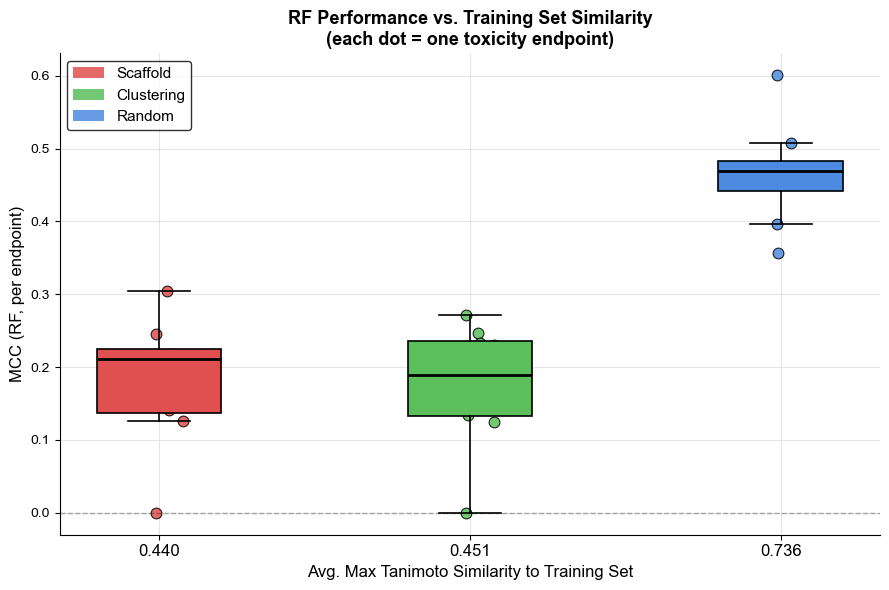

Saved → Figure_HitRate_vs_Similarity.png


In [9]:
# ════════════════════════════════════════════════════════════════
# RF Performance vs. Training Set Similarity (SELF-CONTAINED)
# Run this cell alone — no earlier cells required.
# ════════════════════════════════════════════════════════════════
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import matthews_corrcoef

# ── CONFIG ─────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_CLUSTERS   = 150
UNITOX_FILE  = "UniTox_with_recovered_typos_v3.csv"
MORDRED_FILE = "mordred_features_cached.csv"
SMILES_COL   = "SMILES_filled"
OUT_FIG2     = "Figure_HitRate_vs_Similarity.png"

# ── LOAD DATA ──────────────────────────────────────────────────────
df = pd.read_csv(UNITOX_FILE).dropna(subset=[SMILES_COL]).reset_index(drop=True)
X = pd.read_csv(MORDRED_FILE).values.astype(np.float64)
X = np.nan_to_num(X, nan=0.0)
assert len(df) == len(X), f"Row mismatch: df={len(df)}, X={len(X)}"
smiles = df[SMILES_COL].tolist()
ENDPOINTS = [c for c in df.columns if c.endswith("__binary")]
EP_LABELS = [
    "Cardiotoxicity", "Dermatological", "Hematological",
    "Infertility", "Liver Toxicity", "Ototoxicity",
    "Pulmonary Toxicity", "Renal Toxicity",
]
print(f"Loaded {len(df)} molecules | {len(ENDPOINTS)} endpoints")

# ── SPLIT FUNCTIONS ────────────────────────────────────────────────
def split_random(n):
    idx = np.arange(n)
    tr, te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE)
    return list(tr), list(te)

def split_scaffold(smiles):
    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles):
        mol = Chem.MolFromSmiles(smi)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False) if mol else ""
            if not scaf:
                scaf = smi
        except Exception:
            scaf = smi
        scaf2idx[scaf].append(i)
    n_test = int(len(smiles) * 0.2)
    te, tr = [], []
    for s in sorted(scaf2idx, key=lambda s: -len(scaf2idx[s])):
        (te if len(te) < n_test else tr).extend(scaf2idx[s])
    return tr, te

def split_clustering(X, n_clusters=N_CLUSTERS, n_splits=5, fold=0):
    """Ward clustering (n=150) + GroupKFold(n_splits=5). Returns fold 0."""
    Xs = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(
        n_clusters=n_clusters, metric="euclidean", linkage="ward"
    ).fit_predict(Xs)
    gkf = GroupKFold(n_splits=n_splits)
    folds = list(gkf.split(np.arange(len(X)), groups=labels))
    tr_idx, te_idx = folds[fold]
    return list(tr_idx), list(te_idx)

splits = {
    "random":     split_random(len(df)),
    "scaffold":   split_scaffold(smiles),
    "clustering": split_clustering(X),
}
print("Splits built.")

# ── CONFIG (with the FIXES applied) ────────────────────────────────
SPLIT_COLOURS = {"random": "#4C8BE0", "scaffold": "#E05050", "clustering": "#5BBF5B"}
SPLIT_LABELS  = {"random": "Random", "scaffold": "Scaffold", "clustering": "Clustering"}

# FIX 1: n_estimators=300 (was 100), and add max_features="sqrt"
RF_PARAMS = dict(n_estimators=300, max_features="sqrt",
                 class_weight="balanced",
                 random_state=42, n_jobs=-1)

# ── MORGAN FINGERPRINTS (FIX 2: nBits=2048, was 1024) ──────────────
fps = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048) if mol else None)

# ── COMPUTE SIMILARITY + MCC PER SPLIT × ENDPOINT ──────────────────
results = []
for split_name, (tr_idx, te_idx) in splits.items():
    tr_idx = np.array(tr_idx)
    te_idx = np.array(te_idx)
    X_tr = X[tr_idx]
    X_te = X[te_idx]

    # Avg max Tanimoto similarity of test → train
    tr_fps = [fps[i] for i in tr_idx if fps[i] is not None]
    similarities = []
    for i in te_idx:
        if fps[i] is None:
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], tr_fps)
        similarities.append(max(sims))
    avg_sim = np.mean(similarities)

    # Train RF, compute MCC per endpoint
    for ep_col, ep_label in zip(ENDPOINTS, EP_LABELS):
        y_tr = df[ep_col].values[tr_idx]
        y_te = df[ep_col].values[te_idx]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            continue
        clf = RandomForestClassifier(**RF_PARAMS)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        mcc = matthews_corrcoef(y_te, preds)
        results.append({"split": split_name, "endpoint": ep_label,
                        "avg_sim": avg_sim, "MCC": mcc})
    print(f"  {split_name:<12} avg_sim={avg_sim:.3f}")

res_df = pd.DataFrame(results)

# ── PLOT ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6), facecolor="white")
ax.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e5e5e5", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

split_order = sorted(splits.keys(),
                     key=lambda s: res_df[res_df["split"] == s]["avg_sim"].mean())
positions = {s: i for i, s in enumerate(split_order)}
x_ticks, x_labels = [], []

for split_name in split_order:
    sub = res_df[res_df["split"] == split_name]
    avg_sim = sub["avg_sim"].mean()
    mcc_vals = sub["MCC"].values
    pos = positions[split_name]
    colour = SPLIT_COLOURS[split_name.lower()]

    ax.boxplot(mcc_vals, positions=[pos], widths=0.4,
               patch_artist=True, manage_ticks=False, zorder=3,
               boxprops=dict(facecolor=colour, color="black", linewidth=1.2),
               medianprops=dict(color="black", linewidth=2.0),
               whiskerprops=dict(color="black", linewidth=1.2),
               capprops=dict(color="black", linewidth=1.2),
               flierprops=dict(marker="", markersize=0))

    np.random.seed(42)
    jitter = np.random.normal(0, 0.05, size=len(mcc_vals))
    ax.scatter(pos + jitter, mcc_vals, color=colour,
               edgecolors="black", linewidths=0.8, s=60, alpha=0.85, zorder=2)

    # Print median MCC alongside avg sim
    median_mcc = np.median(mcc_vals)
    print(f"  {split_name:<12} median MCC = {median_mcc:.3f}")

    x_ticks.append(pos)
    x_labels.append(f"{avg_sim:.3f}")

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=12)
ax.set_xlabel("Avg. Max Tanimoto Similarity to Training Set", fontsize=12)
ax.set_ylabel("MCC (RF, per endpoint)", fontsize=12)
ax.set_title("RF Performance vs. Training Set Similarity\n(each dot = one toxicity endpoint)",
             fontsize=13, fontweight="bold")
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.3)

handles = [mpatches.Patch(facecolor=SPLIT_COLOURS[s.lower()], alpha=0.85,
                           label=SPLIT_LABELS[s.lower()])
           for s in split_order]
ax.legend(handles=handles, fontsize=11, frameon=True,
          facecolor="white", edgecolor="black")

plt.tight_layout()
plt.savefig(OUT_FIG2, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUT_FIG2}")

In [13]:
# random forest════════════════════════════════════════════════════════════════
# CELL 1 — Imports
# ════════════════════════════════════════════════════════════════
import warnings, time
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering            # ← FIX

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              accuracy_score, precision_score,
                              recall_score, matthews_corrcoef)

RANDOM_STATE = 42
N_CLUSTERS   = 150                                              # ← FIX

ENDPOINTS = [
    "cardiotoxicity__binary",
    "dermatological_toxicity__binary",
    "hematological__binary",
    "infertility__binary",
    "liver_toxicity__binary",
    "ototoxicity__binary",
    "pulmonary_toxicity__binary",
    "renal_toxicity__binary",
]
EP_LABELS = [
    "Cardiotoxicity", "Dermatological", "Hematological",
    "Infertility", "Liver Toxicity", "Ototoxicity",
    "Pulmonary Toxicity", "Renal Toxicity",
]


# ════════════════════════════════════════════════════════════════
# CELL 2 — Load data
# ════════════════════════════════════════════════════════════════
# Mordred was computed on dropna(SMILES_filled) → 2196 rows, original order
df = (pd.read_csv("UniTox_with_recovered_typos_v3.csv")
        .dropna(subset=["SMILES_filled"])
        .reset_index(drop=True))

X = pd.read_csv("mordred_features_cached.csv").values.astype(np.float64)

assert len(df) == len(X), f"Row mismatch: UniTox={len(df)}, Mordred={len(X)}"

# Fill any residual NaN with 0
X = np.nan_to_num(X, nan=0.0)

smiles = df["SMILES_filled"].tolist()
print(f"Loaded {len(df)} molecules  ×  {X.shape[1]} Mordred descriptors")


# ════════════════════════════════════════════════════════════════
# CELL 3 — Splits  (CLUSTERING FIX: Ward on Mordred, n=150)
# ════════════════════════════════════════════════════════════════
def split_random(n):
    idx = np.arange(n)
    tr, te = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE)
    return list(tr), list(te)


def split_scaffold(smiles):
    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles):
        mol = Chem.MolFromSmiles(smi)
        try:
            # We still use Scaffold for this specific split strategy
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False) if mol else ""
        except:
            scaf = ""
        if not scaf:
            scaf = smi
        scaf2idx[scaf].append(i)
    n_test = int(len(smiles) * 0.2)
    te, tr = [], []
    for s in sorted(scaf2idx, key=lambda s: -len(scaf2idx[s])):
        (te if len(te) < n_test else tr).extend(scaf2idx[s])
    return tr, te


def split_clustering(X, n_clusters=N_CLUSTERS, n_splits=5, fold=0):
    """
    FIX: Replaces the previous `split_butina_mordred` (Butina clustering on
    Euclidean distances over Mordred descriptors). The new version uses
    Agglomerative (Ward) clustering with n=150 clusters and GroupKFold
    (n_splits=5) — exactly as described in the thesis methodology
    (continuous physicochemical separation; whole clusters assigned to
    either train or test via GroupKFold).
    """
    print(f"Performing Ward clustering (n_clusters={n_clusters}) on standardised Mordred...")
    Xs     = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(
                n_clusters=n_clusters, metric="euclidean", linkage="ward"
             ).fit_predict(Xs)

    gkf   = GroupKFold(n_splits=n_splits)
    folds = list(gkf.split(np.arange(len(X)), groups=labels))
    tr_idx, te_idx = folds[fold]

    n_unique = len(np.unique(labels))
    print(f"  → {n_unique} clusters, GroupKFold({n_splits}) fold={fold}, "
          f"train={len(tr_idx)}, test={len(te_idx)}")
    return list(tr_idx), list(te_idx)


# Updated split dictionary (clustering FIXED)
splits = {
    "Random":     split_random(len(df)),
    "Scaffold":   split_scaffold(smiles),
    "Clustering": split_clustering(X, n_clusters=N_CLUSTERS),    # ← FIX
}

for name, (tr, te) in splits.items():
    print(f"  {name:12s}  train={len(tr)}  test={len(te)}")


# ════════════════════════════════════════════════════════════════
# CELL 4 — Train RF + print tables
# ════════════════════════════════════════════════════════════════
all_rows = []

for split_name, (tr_idx, te_idx) in splits.items():
    X_tr, X_te = X[tr_idx], X[te_idx]
    print(f"\n[{split_name}]")

    for ep_col, ep_label in zip(ENDPOINTS, EP_LABELS):
        y_tr = df[ep_col].values[tr_idx]
        y_te = df[ep_col].values[te_idx]

        if len(np.unique(y_tr)) < 2:
            print(f"  {ep_label:20s} — skipped (single class in train)")
            continue

        rf = RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf.fit(X_tr, y_tr)

        y_proba = rf.predict_proba(X_te)[:, 1]
        threshold = y_tr.sum() / len(y_tr)   # class-prior threshold
        y_pred = (y_proba >= threshold).astype(int)
        both = len(np.unique(y_te)) > 1

        row = {
            "Split":     split_name,
            "Toxicity":  ep_label,
            "ROC-AUC":   round(roc_auc_score(y_te, y_proba),               3) if both else float("nan"),
            "AUPRC":     round(average_precision_score(y_te, y_proba),      3) if both else float("nan"),
            "Accuracy":  round(accuracy_score(y_te, y_pred),                3),
            "Precision": round(precision_score(y_te, y_pred, zero_division=0), 3),
            "Recall":    round(recall_score(y_te, y_pred, zero_division=0), 3),
            "MCC":       round(matthews_corrcoef(y_te, y_pred),              3),
        }
        all_rows.append(row)
        print(f"  {ep_label:20s}  AUC={row['ROC-AUC']:.3f}  MCC={row['MCC']:.3f}")

results = pd.DataFrame(all_rows)

# ── Pretty table per split ────────────────────────────────────
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 120)

for split_name in ["Random", "Scaffold", "Clustering"]:
    tbl = (results[results["Split"] == split_name]
           .drop(columns="Split")
           .reset_index(drop=True))
    mean_row = tbl.mean(numeric_only=True).round(3)
    mean_row["Toxicity"] = "── MEAN ──"
    tbl = pd.concat([tbl, mean_row.to_frame().T], ignore_index=True)
    print(f"\n{'='*75}")
    print(f"  Random Forest — {split_name} split")
    print(f"{'='*75}")
    print(tbl.to_string(index=False))

# ── Save ──────────────────────────────────────────────────────
results.to_csv("RF_results.csv", index=False)
print("\nSaved: RF_results.csv")

Loaded 2196 molecules  ×  1613 Mordred descriptors
Performing Ward clustering (n_clusters=150) on standardised Mordred...
  → 150 clusters, GroupKFold(5) fold=0, train=1756, test=440
  Random        train=1756  test=440
  Scaffold      train=1749  test=447
  Clustering    train=1756  test=440

[Random]
  Cardiotoxicity        AUC=0.818  MCC=0.514
  Dermatological        AUC=0.780  MCC=0.295
  Hematological         AUC=0.828  MCC=0.477
  Infertility           AUC=0.821  MCC=0.463
  Liver Toxicity        AUC=0.855  MCC=0.606
  Ototoxicity           AUC=0.797  MCC=0.319
  Pulmonary Toxicity    AUC=0.828  MCC=0.511
  Renal Toxicity        AUC=0.810  MCC=0.445

[Scaffold]
  Cardiotoxicity        AUC=0.714  MCC=0.296
  Dermatological        AUC=0.688  MCC=0.155
  Hematological         AUC=0.590  MCC=0.186
  Infertility           AUC=0.680  MCC=0.286
  Liver Toxicity        AUC=0.679  MCC=0.268
  Ototoxicity           AUC=0.511  MCC=-0.132
  Pulmonary Toxicity    AUC=0.639  MCC=0.177
  Renal 

In [2]:
""" random forest figures
generate_all_metrics.py
=======================
Runs repeated CV collecting ROC-AUC, AUPRC, MCC, and Accuracy per fold,
then produces:
  - Figure_grouped_boxplot.png   (4 metrics × 3 splits, median annotated above whisker)
  - Figure6_random.png / Figure6_scaffold.png / Figure6_clustering.png
    (horizontal boxplots per endpoint, distributions across folds)
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GroupKFold
from sklearn.metrics import (matthews_corrcoef, roc_auc_score,
                             average_precision_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# ── CONFIG ────────────────────────────────────────────────────────────────────
N_FOLDS      = 5
N_REPEATS    = 2
N_CLUSTERS   = 150                     # ← FIX: 150 clusters (was 10)
N_TOP_FEAT   = 300
RANDOM_STATE = 42

COLOURS     = {"random": "#4C8BE0", "scaffold": "#E05050", "clustering": "#5BBF5B"}
LABELS      = {"random": "Random Split", "scaffold": "Scaffold Split", "clustering": "Clustering Split"}
SPLIT_ORDER = ["random", "scaffold", "clustering"]
METRIC_ORDER = ["ROC-AUC", "AUPRC", "MCC", "Accuracy"]
FIG6_METRICS = ["ROC-AUC", "AUPRC", "MCC"]   # shown in Figure 6

EP_SHORT = {
    "cardiotoxicity__binary":          "Cardiotoxicity",
    "dermatological_toxicity__binary": "Dermatological toxicity",
    "hematological__binary":           "Hematological toxicity",
    "infertility__binary":             "Infertility",
    "liver_toxicity__binary":          "Liver toxicity",
    "ototoxicity__binary":             "Ototoxicity",
    "pulmonary_toxicity__binary":      "Pulmonary toxicity",
    "renal_toxicity__binary":          "Renal toxicity",
}

RF_PARAMS = dict(n_estimators=100, max_features="sqrt",
                 class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)


# ── DATA ─────────────────────────────────────────────────────────────────────
def load_data():
    df = (pd.read_csv("UniTox_with_recovered_typos_v3.csv")
            .dropna(subset=["SMILES_filled"])
            .reset_index(drop=True))
    X = pd.read_csv("mordred_features_cached.csv").values.astype(np.float64)
    X = np.nan_to_num(X, nan=0.0)
    smiles = df["SMILES_filled"].tolist()
    print(f"Loaded {len(df)} molecules × {X.shape[1]} Mordred descriptors")

    top_idx = np.argsort(X.var(axis=0))[-N_TOP_FEAT:]
    X = X[:, top_idx]
    print(f"  Pre-filtered to {N_TOP_FEAT} features by variance")

    endpoints = sorted([c for c in df.columns if c.endswith("__binary")])
    return df, X, smiles, endpoints


def preprocess(X_train, X_test):
    keep = X_train.var(axis=0) > 0
    sc   = StandardScaler()
    return sc.fit_transform(X_train[:, keep]), sc.transform(X_test[:, keep])


def get_scaffold_groups(smiles):
    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold
    groups = []
    for smi in smiles:
        try:
            mol = Chem.MolFromSmiles(str(smi))
            sc  = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            if not sc:         # acyclic — use SMILES as unique key
                sc = str(smi)
        except Exception:
            sc = str(smi)
        groups.append(sc)
    unique = {s: i for i, s in enumerate(dict.fromkeys(groups))}
    return np.array([unique[g] for g in groups])


def get_cluster_groups(X, n_clusters=N_CLUSTERS):
    """
    FIX: Ward clustering on standardised Mordred descriptors with n=150.
    Returns one cluster label per molecule for use with GroupKFold.
    """
    sc = StandardScaler()
    return AgglomerativeClustering(
        n_clusters=n_clusters, metric="euclidean", linkage="ward"
    ).fit_predict(sc.fit_transform(X))


# ── EVALUATION ────────────────────────────────────────────────────────────────
def evaluate_fold(X_tr, X_te, y_tr, y_te):
    nan_row = {m: np.nan for m in METRIC_ORDER}
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        return nan_row
    clf   = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_te)[:, 1]
    pred  = (proba >= np.mean(y_tr)).astype(int)
    return {
        "ROC-AUC":  roc_auc_score(y_te, proba),
        "AUPRC":    average_precision_score(y_te, proba),
        "MCC":      matthews_corrcoef(y_te, pred),
        "Accuracy": accuracy_score(y_te, pred),
    }


def run_random(df, X, endpoints):
    rows = []
    rskf = RepeatedStratifiedKFold(n_splits=N_FOLDS, n_repeats=N_REPEATS,
                                   random_state=RANDOM_STATE)
    idx = np.arange(len(df))
    for ep in endpoints:
        y = df[ep].values
        fold_mccs = []
        for tr_idx, te_idx in rskf.split(idx, y):
            X_tr, X_te = preprocess(X[tr_idx], X[te_idx])
            m = evaluate_fold(X_tr, X_te, y[tr_idx], y[te_idx])
            fold_mccs.append(m["MCC"])
            for met, val in m.items():
                rows.append({"split": "random", "endpoint": ep, "metric": met, "value": val})
        print(f"  [random]     {ep}: mean MCC = {np.nanmean(fold_mccs):.3f}", flush=True)
    return rows


def run_group(df, X, endpoints, groups, label):
    rows = []
    gkf = GroupKFold(n_splits=N_FOLDS)
    idx = np.arange(len(df))
    for ep in endpoints:
        y = df[ep].values
        fold_mccs = []
        for tr_idx, te_idx in gkf.split(idx, y, groups):
            X_tr, X_te = preprocess(X[tr_idx], X[te_idx])
            m = evaluate_fold(X_tr, X_te, y[tr_idx], y[te_idx])
            fold_mccs.append(m["MCC"])
            for met, val in m.items():
                rows.append({"split": label, "endpoint": ep, "metric": met, "value": val})
        print(f"  [{label:10s}] {ep}: mean MCC = {np.nanmean(fold_mccs):.3f}", flush=True)
    return rows


# ── PLOT HELPERS ──────────────────────────────────────────────────────────────
def style_ax_vertical(ax):
    ax.set_facecolor("white")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color("black")
        ax.spines[sp].set_linewidth(1.3)
    ax.tick_params(colors="black", width=1.2, length=5, labelsize=12)
    ax.yaxis.grid(True, color="#e5e5e5", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


def style_ax_horizontal(ax):
    ax.set_facecolor("white")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color("black")
        ax.spines[sp].set_linewidth(1.3)
    ax.tick_params(colors="black", width=1.2, length=5)
    ax.xaxis.grid(True, color="#e5e5e5", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


def draw_bp_vertical(ax, data, pos, colour, width=0.22):
    """Vertical boxplot. Returns (median, whisker_top)."""
    clean = np.array([v for v in data if not np.isnan(v)])
    if len(clean) == 0:
        clean = np.array([np.nan])
    bp = ax.boxplot(
        [clean], positions=[pos], widths=width, vert=True,
        patch_artist=True, notch=False,
        medianprops=dict(color="black", linewidth=2.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        flierprops=dict(marker="o", markersize=3.5,
                        markerfacecolor="gray", markeredgecolor="none", alpha=0.5),
        zorder=3,
    )
    bp["boxes"][0].set_facecolor(colour)
    bp["boxes"][0].set_alpha(0.85)
    median      = float(np.nanmedian(clean))
    whisker_top = bp["whiskers"][1].get_ydata()[1]   # top cap of upper whisker
    return median, whisker_top


def draw_bp_horizontal(ax, data, pos, colour, width=0.55):
    """Horizontal boxplot. Returns (median, whisker_right)."""
    clean = np.array([v for v in data if not np.isnan(v)])
    if len(clean) == 0:
        clean = np.array([np.nan])
    bp = ax.boxplot(
        [clean], positions=[pos], widths=width, vert=False,
        patch_artist=True, notch=False,
        medianprops=dict(color="black", linewidth=2.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        flierprops=dict(marker="o", markersize=3.5,
                        markerfacecolor="gray", markeredgecolor="none", alpha=0.5),
        zorder=3,
    )
    bp["boxes"][0].set_facecolor(colour)
    bp["boxes"][0].set_alpha(0.85)
    median        = float(np.nanmedian(clean))
    whisker_right = bp["whiskers"][1].get_xdata()[1]  # right cap of upper whisker
    return median, whisker_right


# ── FIGURE: grouped boxplot ───────────────────────────────────────────────────
def make_grouped_boxplot(results_df, out="Figure_grouped_boxplot.png"):
    n_metrics = len(METRIC_ORDER)
    n_splits  = len(SPLIT_ORDER)
    gap       = 0.9 / n_splits
    offsets   = np.linspace(-(n_splits - 1) * gap / 2,
                             (n_splits - 1) * gap / 2, n_splits)
    group_centres = np.arange(n_metrics, dtype=float)

    fig, ax = plt.subplots(figsize=(13, 6), facecolor="white")
    style_ax_vertical(ax)

    # ── separators between metric groups ──────────────────────────────────────
    for sep in np.arange(n_metrics - 1) + 0.5:
        ax.axvline(sep, color="#bbbbbb", linewidth=1.0, linestyle="--", zorder=1, alpha=0.7)

    # optional: alternating light background bands per group
    for i in range(n_metrics):
        if i % 2 == 0:
            ax.axvspan(i - 0.5, i + 0.5, color="#f5f5f5", zorder=0)

    for j, sp in enumerate(SPLIT_ORDER):
        sub = results_df[results_df["split"] == sp]
        for i, met in enumerate(METRIC_ORDER):
            data = sub[sub["metric"] == met]["value"].dropna().values
            pos  = group_centres[i] + offsets[j]
            med, whisker_top = draw_bp_vertical(ax, data, pos, COLOURS[sp])
            ax.text(pos, whisker_top + 0.015, f"{med:.2f}",
                    ha="center", va="bottom", fontsize=17,
                    fontweight="bold", color="black")

    ax.set_xticks(group_centres)
    ax.set_xticklabels(METRIC_ORDER, fontsize=18)
    ax.set_ylabel("Score", fontsize=18)
    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.3)
    ax.set_xlim(-0.6, n_metrics - 0.4)

    handles = [mpatches.Patch(facecolor=COLOURS[s], alpha=0.85, label=LABELS[s])
               for s in SPLIT_ORDER]
    ax.legend(handles=handles, frameon=True, edgecolor="#cccccc",
              fontsize=15,
              loc="upper center",
              bbox_to_anchor=(0.5, -0.08),
              ncol=3)

    # give the top some breathing room for the whisker annotations
    ylo, yhi = ax.get_ylim()
    ax.set_ylim(ylo, yhi + 0.12)

    plt.tight_layout()
    plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"Saved → {out}", flush=True)


# ── FIGURE 6: per-endpoint horizontal boxplots for one split ──────────────────

SPLIT_FIG_TITLES = {
    "random":     "Random Split",
    "scaffold":   "Scaffold Split",
    "clustering": "Clustering Split",
}


def fig6_one_split(results_df, split, out):
    sub = results_df[results_df["split"] == split]
    if sub.empty:
        return

    # Endpoint order: sorted by short label
    endpoints  = sorted(sub["endpoint"].unique(), key=lambda e: EP_SHORT.get(e, e))
    ep_labels  = [EP_SHORT.get(e, e) for e in endpoints]
    ypos       = np.arange(len(endpoints))
    colour     = COLOURS[split]

    fig, axes = plt.subplots(1, len(FIG6_METRICS), figsize=(22, 7), sharey=True,
                             facecolor="white")
    plt.subplots_adjust(left=0.18)

    for ax, metric in zip(axes, FIG6_METRICS):
        style_ax_horizontal(ax)
        met_sub = sub[sub["metric"] == metric]

        all_vals = met_sub["value"].dropna().values
        x_min = min(-0.1, np.nanmin(all_vals) - 0.05) if len(all_vals) else -0.1
        x_max = max(1.0,  np.nanmax(all_vals) + 0.20) if len(all_vals) else 1.1

        for i, ep in enumerate(endpoints):
            data = met_sub[met_sub["endpoint"] == ep]["value"].dropna().values
            med, whisker_right = draw_bp_horizontal(ax, data, ypos[i], colour)
            ax.text(whisker_right + 0.02, ypos[i], f"{med:.2f}",
                    va="center", ha="left", fontsize=17, fontweight="bold")

        ax.axvline(0, color="black", linewidth=1.5, zorder=2)
        ax.set_xlim(x_min, x_max)
        ax.set_title(metric, pad=12, fontweight="normal", fontsize=17)
        ax.tick_params(axis="x", labelsize=14)

    axes[0].set_yticks(ypos)
    axes[0].set_yticklabels(ep_labels, fontsize=20)

    # ── Title: short, close to figure ─────────────────────────────────────────
    fig_title = SPLIT_FIG_TITLES.get(split, LABELS[split])
    fig.suptitle(fig_title, fontsize=20, fontweight="bold", y=0.98)   # ← close

    plt.tight_layout(rect=[0, 0, 1, 0.95])    # leaves a little room for the title
    plt.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"Saved → {out}", flush=True)


# ── MAIN ──────────────────────────────────────────────────────────────────────
def main():
    df, X, smiles, endpoints = load_data()
    all_rows = []

    print("\nRunning Random split (5×2 repeated stratified k-fold)...", flush=True)
    all_rows += run_random(df, X, endpoints)

    print("\nComputing scaffold groups...", flush=True)
    scaffold_groups = get_scaffold_groups(smiles)
    print("Running Scaffold split (5-fold GroupKFold)...", flush=True)
    all_rows += run_group(df, X, endpoints, scaffold_groups, "scaffold")

    print(f"\nComputing cluster groups (Ward, n_clusters={N_CLUSTERS})...", flush=True)
    cluster_groups = get_cluster_groups(X, n_clusters=N_CLUSTERS)   # ← FIX
    print("Running Clustering split (5-fold GroupKFold)...", flush=True)
    all_rows += run_group(df, X, endpoints, cluster_groups, "clustering")

    results_df = pd.DataFrame(all_rows)
    results_df.to_csv("cv_results_all_metrics.csv", index=False)
    print("\nRaw results → cv_results_all_metrics.csv", flush=True)

    print("\nGenerating figures...", flush=True)
    make_grouped_boxplot(results_df)

    for split, out in [
        ("random",     "Figure6_random.png"),
        ("scaffold",   "Figure6_scaffold.png"),
        ("clustering", "Figure6_clustering.png"),
    ]:
        fig6_one_split(results_df, split, out)

    print("\nAll done.", flush=True)


if __name__ == "__main__":
    main()

Loaded 2196 molecules × 1613 Mordred descriptors
  Pre-filtered to 300 features by variance

Running Random split (5×2 repeated stratified k-fold)...
  [random]     cardiotoxicity__binary: mean MCC = 0.446
  [random]     dermatological_toxicity__binary: mean MCC = 0.303
  [random]     hematological__binary: mean MCC = 0.463
  [random]     infertility__binary: mean MCC = 0.488
  [random]     liver_toxicity__binary: mean MCC = 0.544
  [random]     ototoxicity__binary: mean MCC = 0.276
  [random]     pulmonary_toxicity__binary: mean MCC = 0.426
  [random]     renal_toxicity__binary: mean MCC = 0.414

Computing scaffold groups...


[19:17:43] WARNING: not removing hydrogen atom without neighbors


Running Scaffold split (5-fold GroupKFold)...
  [scaffold  ] cardiotoxicity__binary: mean MCC = 0.317
  [scaffold  ] dermatological_toxicity__binary: mean MCC = 0.176
  [scaffold  ] hematological__binary: mean MCC = 0.242
  [scaffold  ] infertility__binary: mean MCC = 0.218
  [scaffold  ] liver_toxicity__binary: mean MCC = 0.327
  [scaffold  ] ototoxicity__binary: mean MCC = 0.150
  [scaffold  ] pulmonary_toxicity__binary: mean MCC = 0.161
  [scaffold  ] renal_toxicity__binary: mean MCC = 0.238

Computing cluster groups (Ward, n_clusters=150)...
Running Clustering split (5-fold GroupKFold)...
  [clustering] cardiotoxicity__binary: mean MCC = 0.206
  [clustering] dermatological_toxicity__binary: mean MCC = 0.129
  [clustering] hematological__binary: mean MCC = 0.246
  [clustering] infertility__binary: mean MCC = 0.190
  [clustering] liver_toxicity__binary: mean MCC = 0.302
  [clustering] ototoxicity__binary: mean MCC = 0.099
  [clustering] pulmonary_toxicity__binary: mean MCC = 0.094
  

In [11]:
"""
13_svm_rfe_feature_selection.py
=================================
Feature selection via SVM-RFE per toxicity endpoint.

Strategy:
  1. RF importance pre-screen: top 300 features
  2. SVM-RFE on those 300 → N features (tested at N = 50, 100, 150, 200)
  3. Retrain RF on selected features, compare MCC before/after
  4. Best N selected by highest mean test MCC
  5. Union of selected descriptors across endpoints saved for reproducibility

REQUIRES:
  UniTox_with_recovered_typos_v3.csv
  mordred_features_cached.csv
  withdrawn_external_validation.csv
  mordred_withdrawn_cached.csv

PRODUCES:
  rfe_results.csv
  selected_descriptors_rfe.csv
  rfe_comparison_no_overlap.png
"""

import sys, time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef
import warnings
warnings.filterwarnings("ignore")

TRAIN_FILE        = "UniTox_with_recovered_typos_v3.csv"
MORDRED_FILE      = "mordred_features_cached.csv"
WITHDRAWN_FILE    = "withdrawn_external_validation.csv"
WITHDRAWN_MORDRED = "mordred_withdrawn_cached.csv"

RANDOM_STATE  = 42
TEST_SIZE     = 0.2
PRESCREEN_TOP = 300
RFE_TARGETS   = [50, 100, 150, 200]

RF_PARAMS = dict(
    n_estimators=200, max_features="sqrt", class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1,
)


def load_and_split():
    df = pd.read_csv(TRAIN_FILE)
    df = df.dropna(subset=["SMILES_filled"]).reset_index(drop=True)
    endpoints = sorted([c for c in df.columns if c.endswith("__binary")])
    mordred   = pd.read_csv(MORDRED_FILE)
    withdrawn = pd.read_csv(WITHDRAWN_FILE)
    withdrawn = withdrawn.dropna(subset=["smiles"]).reset_index(drop=True)
    mordred_w = pd.read_csv(WITHDRAWN_MORDRED)

    for ep in endpoints:
        withdrawn[ep] = 0
    for i, row in withdrawn.iterrows():
        if isinstance(row["toxtype"], str):
            for ep in endpoints:
                if ep.replace("__binary", "") in [t.strip().lower()
                                                   for t in row["toxtype"].split(",")]:
                    withdrawn.at[i, ep] = 1

    train_idx, test_idx = train_test_split(
        np.arange(len(df)), test_size=TEST_SIZE, random_state=RANDOM_STATE)

    X_tr = mordred.iloc[train_idx].reset_index(drop=True).select_dtypes(include=[np.number])
    keep = X_tr.var() > 0
    X_tr = X_tr.loc[:, keep]
    cols = X_tr.columns.tolist()

    X_te  = mordred.iloc[test_idx].reset_index(drop=True).select_dtypes(
                include=[np.number]).reindex(columns=cols, fill_value=0)
    X_ext = mordred_w.reset_index(drop=True).select_dtypes(
                include=[np.number]).reindex(columns=cols, fill_value=0)

    med = X_tr.median()
    X_tr  = X_tr.fillna(med).values
    X_te  = X_te.fillna(med).values
    X_ext = X_ext.fillna(med).values

    y_tr  = df.iloc[train_idx][endpoints].reset_index(drop=True)
    y_te  = df.iloc[test_idx][endpoints].reset_index(drop=True)
    y_ext = withdrawn[endpoints].reset_index(drop=True)

    return X_tr, X_te, X_ext, y_tr, y_te, y_ext, endpoints, cols


def eval_rf(X_tr, X_te, X_ext, y_tr_ep, y_te_ep, y_ext_ep):
    y = y_tr_ep.values
    if len(np.unique(y)) < 2:
        return 0.0, 0.0
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_tr, y)
    thresh = np.mean(y)
    p_te  = (clf.predict_proba(X_te)[:, 1]  >= thresh).astype(int)
    p_ext = (clf.predict_proba(X_ext)[:, 1] >= thresh).astype(int)
    return (matthews_corrcoef(y_te_ep.values, p_te),
            matthews_corrcoef(y_ext_ep.values, p_ext))


def main():
    print("Loading data...", flush=True)
    X_tr, X_te, X_ext, y_tr, y_te, y_ext, endpoints, cols = load_and_split()
    n_feat_total = X_tr.shape[1]
    ep_short = [ep.replace("__binary", "").replace("_", " ").title() for ep in endpoints]
    print(f"Train: {X_tr.shape} | Test: {X_te.shape} | Ext: {X_ext.shape}", flush=True)
    print(f"Features after variance filter: {n_feat_total}", flush=True)

    # ── Baseline ──────────────────────────────────────────────────────────────
    print("\n=== Baseline (all features) ===", flush=True)
    base_test, base_ext = {}, {}
    for ep, name in zip(endpoints, ep_short):
        mt, me = eval_rf(X_tr, X_te, X_ext, y_tr[ep], y_te[ep], y_ext[ep])
        base_test[ep], base_ext[ep] = mt, me
        print(f"  {name:<25} test={mt:+.3f}  ext={me:+.3f}", flush=True)

    # ── Per-endpoint: RF pre-screen → SVM-RFE ─────────────────────────────────
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_te_sc  = scaler.transform(X_te)
    X_ext_sc = scaler.transform(X_ext)

    results  = {n: {} for n in RFE_TARGETS}
    # Store sel_idx per endpoint per N for descriptor export
    sel_idxs = {n: {} for n in RFE_TARGETS}

    for ep, name in zip(endpoints, ep_short):
        y = y_tr[ep].values
        if len(np.unique(y)) < 2:
            for n in RFE_TARGETS:
                results[n][ep]  = (0.0, 0.0)
                sel_idxs[n][ep] = []
            continue

        print(f"\n  {name}: RF pre-screening to top {PRESCREEN_TOP}...",
              end="", flush=True)
        t0     = time.time()
        rf_pre = RandomForestClassifier(**RF_PARAMS)
        rf_pre.fit(X_tr, y)
        top_idx = np.argsort(rf_pre.feature_importances_)[::-1][:PRESCREEN_TOP]
        print(f" done ({time.time()-t0:.0f}s)", flush=True)

        X_tr_sub = X_tr_sc[:, top_idx]

        for n_feat in RFE_TARGETS:
            if n_feat >= PRESCREEN_TOP:
                sel_idx = top_idx
            else:
                print(f"    RFE → {n_feat}...", end="", flush=True)
                t1  = time.time()
                svm = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000,
                                dual="auto", random_state=RANDOM_STATE)
                rfe = RFE(estimator=svm, n_features_to_select=n_feat, step=20)
                rfe.fit(X_tr_sub, y)
                sel_idx = top_idx[rfe.support_]
                print(f" done ({time.time()-t1:.0f}s)", flush=True)

            mt, me = eval_rf(X_tr[:, sel_idx], X_te[:, sel_idx], X_ext[:, sel_idx],
                             y_tr[ep], y_te[ep], y_ext[ep])
            results[n_feat][ep]  = (mt, me)
            sel_idxs[n_feat][ep] = sel_idx.tolist()
            print(f"      N={n_feat}: test={mt:+.3f}  ext={me:+.3f}", flush=True)

    # ── Find best N ───────────────────────────────────────────────────────────
    print("\n" + "=" * 90, flush=True)
    mean_per_n = {}
    for n in RFE_TARGETS:
        mean_per_n[n] = np.mean([results[n][ep][0] for ep in endpoints])
        print(f"  N={n:>3}: mean test MCC = {mean_per_n[n]:+.3f}", flush=True)
    baseline_mean = np.mean(list(base_test.values()))
    print(f"  ALL : mean test MCC = {baseline_mean:+.3f} (baseline)", flush=True)

    best_n = max(mean_per_n, key=mean_per_n.get)
    print(f"\nBest N = {best_n} (mean MCC = {mean_per_n[best_n]:+.3f})", flush=True)

    # ── Save selected descriptor names (union across endpoints at best N) ──────
    all_selected = sorted(set(
        cols[i]
        for ep in endpoints
        for i in sel_idxs[best_n].get(ep, [])
    ))
    pd.DataFrame({"descriptor": all_selected}).to_csv(
        "selected_descriptors_rfe.csv", index=False)
    print(f"\nSaved: selected_descriptors_rfe.csv "
          f"({len(all_selected)} unique descriptors across endpoints)", flush=True)

    # ── CSV output ────────────────────────────────────────────────────────────
    N = best_n
    rows = []
    for ep, name in zip(endpoints, ep_short):
        tf, tr = base_test[ep], results[N][ep][0]
        ef, er = base_ext[ep], results[N][ep][1]
        rows.append({
            "Endpoint":            name,
            "N_features_baseline": n_feat_total,
            "N_features_rfe":      N,
            "MCC_test_all":        round(tf, 3),
            "MCC_test_rfe":        round(tr, 3),
            "Delta_MCC_test":      round(tr - tf, 3),
            "MCC_ext_all":         round(ef, 3),
            "MCC_ext_rfe":         round(er, 3),
            "Delta_MCC_ext":       round(er - ef, 3),
        })

    mef = np.mean(list(base_ext.values()))
    mer = np.mean([results[N][ep][1] for ep in endpoints])
    rows.append({
        "Endpoint":            "MEAN",
        "N_features_baseline": n_feat_total,
        "N_features_rfe":      N,
        "MCC_test_all":        round(baseline_mean, 3),
        "MCC_test_rfe":        round(mean_per_n[N], 3),
        "Delta_MCC_test":      round(mean_per_n[N] - baseline_mean, 3),
        "MCC_ext_all":         round(mef, 3),
        "MCC_ext_rfe":         round(mer, 3),
        "Delta_MCC_ext":       round(mer - mef, 3),
    })

    results_df = pd.DataFrame(rows)
    results_df.to_csv("rfe_results.csv", index=False)
    print(f"\nSaved: rfe_results.csv", flush=True)
    print(results_df.to_string(index=False), flush=True)

    # ── Figure ────────────────────────────────────────────────────────────────
    ep_rows   = [r for r in rows if r["Endpoint"] != "MEAN"]
    test_all  = np.array([r["MCC_test_all"] for r in ep_rows])
    test_rfe  = np.array([r["MCC_test_rfe"] for r in ep_rows])
    ep_labels = [r["Endpoint"] for r in ep_rows]

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 11,
        "axes.labelweight": "bold",
    })

    COLOR_ALL = "#4472C4"
    COLOR_RFE = "#ED7D31"
    y = np.arange(len(ep_labels))
    h = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True,
                                   gridspec_kw={"width_ratios": [1.6, 1]},
                                   constrained_layout=True)

    ax1.barh(y + 0.19, test_all, h,
             label=f"Baseline (All Descriptors, N={n_feat_total})",
             color=COLOR_ALL, edgecolor="white")
    ax1.barh(y - 0.19, test_rfe, h,
             label=f"SVM-RFE (Selected N={N})",
             color=COLOR_RFE, edgecolor="white")

    for i, v in enumerate(test_all):
        ax1.text(v + 0.01, y[i] + 0.19, f"{v:.3f}", va="center", ha="left",
                 fontsize=15, fontweight="bold", color="black")
    for i, v in enumerate(test_rfe):
        ax1.text(v + 0.01, y[i] - 0.19, f"{v:.3f}", va="center", ha="left",
                 fontsize=15, fontweight="bold", color="black")

    ax1.set_yticks(y)
    ax1.set_yticklabels(ep_labels, fontsize=16)
    ax1.set_xlabel("Matthews Correlation Coefficient (MCC)", fontsize=16,
                   fontweight="normal", labelpad=15)
    ax1.set_ylabel("Toxicity Endpoints", fontsize=16, fontweight="normal", labelpad=8)
    ax1.set_title("Performance Comparison", fontsize=16, pad=15)
    ax1.set_xlim(0, 0.9)
    ax1.invert_yaxis()
    ax1.legend(loc="lower right", frameon=True, fontsize=13, edgecolor="#cccccc")
    ax1.xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)

    deltas = test_rfe - test_all
    colors = [("#27ae60" if d >= 0 else "#c0392b") for d in deltas]
    ax2.barh(y, deltas, 0.6, color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)

    for i, d in enumerate(deltas):
        ha     = "left"  if d >= 0 else "right"
        offset = 0.002   if d >= 0 else -0.002
        ax2.text(d + offset, y[i], f"{d:+.3f}", va="center", ha=ha,
                 fontsize=15, fontweight="bold", color="black")

    ax2.set_xlabel("Change in MCC (ΔMCC)", fontsize=17, fontweight="normal", labelpad=15)
    ax2.set_title("Impact of Feature Reduction", fontsize=16, fontweight="normal", pad=15)
    ax2.axvline(0, color="black", linewidth=2, zorder=5)
    ax2.set_xlim(-0.07, 0.07)
    ax2.xaxis.grid(True, linestyle="--", alpha=0.5)

    for ax in [ax1, ax2]:
        ax.spines[["top", "right"]].set_visible(False)

    fig.savefig("rfe_comparison_no_overlap.png", dpi=300,
                bbox_inches="tight", facecolor="white")
    print("Saved: rfe_comparison_no_overlap.png", flush=True)
    plt.close()
    print("Done.", flush=True)


if __name__ == "__main__":
    main()

Loading data...
Train: (1756, 1404) | Test: (440, 1404) | Ext: (153, 1404)
Features after variance filter: 1404

=== Baseline (all features) ===
  Cardiotoxicity            test=+0.482  ext=+0.157
  Dermatological Toxicity   test=+0.314  ext=+0.229
  Hematological             test=+0.488  ext=-0.021
  Infertility               test=+0.465  ext=+0.043
  Liver Toxicity            test=+0.610  ext=+0.228
  Ototoxicity               test=+0.259  ext=+0.000
  Pulmonary Toxicity        test=+0.485  ext=+0.158
  Renal Toxicity            test=+0.436  ext=+0.163

  Cardiotoxicity: RF pre-screening to top 300... done (1s)
    RFE → 50... done (30s)
      N=50: test=+0.463  ext=+0.051
    RFE → 100... done (29s)
      N=100: test=+0.475  ext=+0.151
    RFE → 150... done (27s)
      N=150: test=+0.487  ext=+0.187
    RFE → 200... done (23s)
      N=200: test=+0.477  ext=+0.129

  Dermatological Toxicity: RF pre-screening to top 300... done (1s)
    RFE → 50... done (32s)
      N=50: test=+0.326  

In [13]:
"""
plot_external_validation.py
============================
End-to-end external validation: loads data, trains RF, computes all metrics
from actual predictions, and produces four figures.
  figure1_mcc_sensitivity.png         — MCC + Sensitivity per endpoint × split
  figure2_confusion_bars_<split>.png  — TP / FP / FN per endpoint, one panel per split
  figure3_drugs_vs_mcc.png            — Grouped bar chart: drugs per MCC bin × split
  figure4_tp_fn_stacked_<split>.png   — Stacked TP / FN per endpoint, one figure per split

Pipeline (consistent with cells 3/4/11/18):
  - Acyclic molecules retained via fix: each gets its own unique scaffold key (smi)
  - Clustering split: AgglomerativeClustering(n_clusters=150, ward) on standardised
                      Mordred descriptors, partitioned via GroupKFold(n_splits=5).
  - Scaffold split:   random-shuffled scaffold groups (no size bias)
  - Single global RNG for reproducibility

REQUIRED FILES (same directory as this script):
  UniTox_with_recovered_typos_v3.csv
  mordred_features_cached.csv
  withdrawn_external_validation.csv    columns: drugname, smiles, toxtype, predicted_labels
  mordred_withdrawn_cached.csv
"""
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from math import sqrt
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
warnings.filterwarnings("ignore")

try:
    from rdkit import Chem, RDLogger
    RDLogger.DisableLog('rdApp.*')
    from rdkit.Chem.Scaffolds import MurckoScaffold
    RDKIT_OK = True
except ImportError:
    RDKIT_OK = False
    print("WARNING: RDKit not found — scaffold split falls back to random.")


# ── FILE PATHS ────────────────────────────────────────────────────────────────
TRAIN_FILE        = "UniTox_with_recovered_typos_v3.csv"
MORDRED_FILE      = "mordred_features_cached.csv"
WITHDRAWN_FILE    = "withdrawn_external_validation.csv"
WITHDRAWN_MORDRED = "mordred_withdrawn_cached.csv"

# ── COLUMN NAMES ──────────────────────────────────────────────────────────────
UNITOX_SMILES_COL    = "SMILES_filled"
WITHDRAWN_SMILES_COL = "smiles"
WITHDRAWN_REASON_COL = "toxtype"

# ── FONT SIZE CONFIG ──────────────────────────────────────────────────────────
SUPTITLE_FS  = 18
TITLE_FS     = 14
AXLABEL_FS   = 17
TICK_FS      = 17
LEGEND_FS    = 15
ANNOT_FS     = 13
BAR_LABEL_FS = 12

# ── SPLIT / MODEL CONFIG ──────────────────────────────────────────────────────
SPLITS        = ["random", "scaffold", "clustering"]
SPLIT_LABELS  = ["Random Split", "Scaffold Split", "Clustering Split"]
SPLIT_COLOURS = ["#4472C4", "#ED7D31", "#70AD47"]
RF_PARAMS     = dict(n_estimators=300, max_features="sqrt",
                     class_weight="balanced", random_state=42, n_jobs=-1)
RANDOM_STATE  = 42
RNG           = np.random.default_rng(RANDOM_STATE)
N_CLUSTERS    = 150
N_SPLITS      = 5

# ── ENDPOINT DETECTION ────────────────────────────────────────────────────────
ENDPOINTS        = None
ENDPOINT_DISPLAY = None


def make_display_label(col: str) -> str:
    return col.replace("__binary", "").replace("_", " ").title()


# ── TOXTYPE MAP ───────────────────────────────────────────────────────────────
ALIAS = {
    "hematological":           "hematological",
    "renal_toxicity":          "renal_toxicity",
    "cardiotoxicity":          "cardiotoxicity",
    "dermatological_toxicity": "dermatological_toxicity",
    "liver_toxicity":          "liver_toxicity",
    "pulmonary_toxicity":      "pulmonary_toxicity",
    "ototoxicity":             "ototoxicity",
    "infertility":             "infertility",
}


# ── METRICS ───────────────────────────────────────────────────────────────────
def compute_mcc(TP, TN, FP, FN):
    d = sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    return (TP*TN - FP*FN) / d if d else 0.0


def compute_sens(TP, FN):
    return TP / (TP + FN) if (TP + FN) else 0.0


def compute_spec(TN, FP):
    return TN / (TN + FP) if (TN + FP) else 0.0


def drug_mcc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    TP = int(np.sum((y_pred == 1) & (y_true == 1)))
    TN = int(np.sum((y_pred == 0) & (y_true == 0)))
    FP = int(np.sum((y_pred == 1) & (y_true == 0)))
    FN = int(np.sum((y_pred == 0) & (y_true == 1)))
    return compute_mcc(TP, TN, FP, FN)


# ── TOXTYPE PARSING ───────────────────────────────────────────────────────────
def build_toxtype_map(endpoints: list) -> dict:
    ep_base = {ep.replace("__binary", ""): ep for ep in endpoints}
    tmap = {}
    for token, base in ALIAS.items():
        if base in ep_base:
            tmap[token] = ep_base[base]
    for base, col in ep_base.items():
        if base not in tmap.values():
            tmap[base] = col
    return tmap


def parse_toxtype(toxtype_str: str, toxtype_map: dict) -> list:
    if not isinstance(toxtype_str, str):
        return []
    matched = set()
    for token in toxtype_str.split(","):
        key = token.strip().lower()
        if key in toxtype_map:
            matched.add(toxtype_map[key])
    return list(matched)


# ── PREPROCESSING ─────────────────────────────────────────────────────────────
def preprocess(X_train: pd.DataFrame, X_test: pd.DataFrame, X_ext: pd.DataFrame):
    shared  = X_train.columns.intersection(X_test.columns).intersection(X_ext.columns)
    X_train = X_train[shared].copy()
    X_test  = X_test[shared].copy()
    X_ext   = X_ext[shared].copy()
    keep    = X_train.isnull().mean() <= 0.5
    X_train = X_train.loc[:, keep]
    X_test  = X_test.loc[:, keep]
    X_ext   = X_ext.loc[:, keep]
    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)
    X_ext   = X_ext.fillna(medians)
    nonzero = X_train.var() > 0
    X_train = X_train.loc[:, nonzero]
    X_test  = X_test.loc[:, nonzero]
    X_ext   = X_ext.loc[:, nonzero]
    return X_train.values, X_test.values, X_ext.values


# ── SPLITTING ─────────────────────────────────────────────────────────────────
def random_split(n):
    return train_test_split(np.arange(n), test_size=0.2, random_state=RANDOM_STATE)


def scaffold_split(smiles_list, test_size=0.2, rng=RNG):
    if not RDKIT_OK:
        return random_split(len(smiles_list))
    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(
                mol=mol, includeChirality=False) if mol else ""
        except Exception:
            scaf = ""
        if not scaf:          # acyclic fix — each acyclic gets its own unique key
            scaf = smi
        scaf2idx[scaf].append(i)
    scaffold_groups = list(scaf2idx.values())
    rng.shuffle(scaffold_groups)
    n_test = int(len(smiles_list) * test_size)
    te, tr = [], []
    for group in scaffold_groups:
        (te if len(te) < n_test else tr).extend(group)
    print(f"  scaffold → unique scaffolds: {len(scaf2idx)}, "
          f"train={len(tr)}, test={len(te)}")
    return np.array(tr), np.array(te)


def mordred_clustering_split(X, n_clusters=N_CLUSTERS, n_splits=N_SPLITS, fold=0):
    """
    Ward clustering (n=150) on standardised Mordred descriptors,
    then GroupKFold(n_splits=5) — entire clusters kept in train OR test.
    Returns (train_idx, test_idx) for the requested fold (default = 0 → 80/20).
    """
    Xs     = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(
                n_clusters=n_clusters, metric="euclidean", linkage="ward"
             ).fit_predict(Xs)

    gkf   = GroupKFold(n_splits=n_splits)
    folds = list(gkf.split(np.arange(len(X)), groups=labels))
    tr_idx, te_idx = folds[fold]

    n_unique = len(np.unique(labels))
    print(f"  clustering → {n_unique} clusters, "
          f"GroupKFold({n_splits}) fold={fold}, "
          f"train={len(tr_idx)}, test={len(te_idx)}")
    return np.array(tr_idx), np.array(te_idx)


# ── LOAD DATA ─────────────────────────────────────────────────────────────────
def load_data():
    global ENDPOINTS, ENDPOINT_DISPLAY
    print("Loading UniTox...")
    df = pd.read_csv(TRAIN_FILE).dropna(subset=[UNITOX_SMILES_COL]).reset_index(drop=True)
    print(f"  Raw: {len(df)} compounds")

    print("Loading Mordred (UniTox)...")
    mordred = pd.read_csv(MORDRED_FILE)
    assert len(mordred) == len(df), \
        f"Row mismatch UniTox={len(df)} vs Mordred={len(mordred)}"

    # Acyclic scaffold fix
    if RDKIT_OK:
        acyclic_count = 0
        for smi in df[UNITOX_SMILES_COL]:
            mol = Chem.MolFromSmiles(smi)
            try:
                scaf = MurckoScaffold.MurckoScaffoldSmiles(
                    mol=mol, includeChirality=False) if mol else ""
                if not scaf:
                    acyclic_count += 1
            except Exception:
                pass
        print(f"  Acyclic fix applied: {acyclic_count} acyclic molecules retained "
              f"(each treated as its own scaffold). Total: {len(df)} molecules.")
    else:
        print("  RDKit unavailable — acyclic fix skipped")

    ENDPOINTS        = sorted([c for c in df.columns if c.endswith("__binary")])
    ENDPOINT_DISPLAY = [make_display_label(ep) for ep in ENDPOINTS]
    print(f"  Endpoints detected: {ENDPOINTS}")

    mordred = mordred.apply(pd.to_numeric, errors="coerce")

    print("Loading Withdrawn 2.0...")
    withdrawn_raw = pd.read_csv(WITHDRAWN_FILE)
    print(f"  {len(withdrawn_raw)} drugs (raw), columns: {list(withdrawn_raw.columns)}")

    print("Loading Mordred (Withdrawn)...")
    mordred_w_raw = pd.read_csv(WITHDRAWN_MORDRED)
    assert len(mordred_w_raw) == len(withdrawn_raw), \
        f"Row mismatch Withdrawn={len(withdrawn_raw)} vs Mordred={len(mordred_w_raw)}"

    valid_mask = withdrawn_raw[WITHDRAWN_SMILES_COL].notna()
    withdrawn  = withdrawn_raw[valid_mask].reset_index(drop=True)
    mordred_w  = mordred_w_raw[valid_mask].reset_index(drop=True)
    print(f"  After SMILES dropna: {len(withdrawn)} drugs remain")

    mordred_w = mordred_w.apply(pd.to_numeric, errors="coerce")

    common_cols = mordred.columns.intersection(mordred_w.columns)
    mordred     = mordred[common_cols].reset_index(drop=True)
    mordred_w   = mordred_w[common_cols].reset_index(drop=True)
    print(f"  Common Mordred features: {len(common_cols)}")

    toxtype_map = build_toxtype_map(ENDPOINTS)
    print(f"  Toxtype map: {toxtype_map}")

    for ep in ENDPOINTS:
        withdrawn[ep] = 0
    unmatched = []
    for i, row in withdrawn.iterrows():
        hits = parse_toxtype(row[WITHDRAWN_REASON_COL], toxtype_map)
        if not hits:
            unmatched.append(row.get("drugname", i))
        for ep in hits:
            withdrawn.at[i, ep] = 1

    if unmatched:
        print(f"  WARNING: {len(unmatched)} drugs had no matching endpoint:")
        for d in unmatched[:10]:
            print(f"    '{d}'")

    unitox_smiles = set(df[UNITOX_SMILES_COL].str.strip())
    overlap = withdrawn[WITHDRAWN_SMILES_COL].str.strip().isin(unitox_smiles)
    print(f"  Removing {overlap.sum()} SMILES overlaps with UniTox")
    withdrawn = withdrawn[~overlap].reset_index(drop=True)
    mordred_w = mordred_w[~overlap].reset_index(drop=True)
    print(f"  Final external set: {len(withdrawn)} drugs")

    return df, mordred, withdrawn, mordred_w


# ── RUN ONE SPLIT ─────────────────────────────────────────────────────────────
def run_split(split_name, df, mordred, withdrawn, mordred_w):
    print(f"\n--- Split: {split_name} ---")
    smiles = df[UNITOX_SMILES_COL].tolist()
    X_all  = mordred.values.astype(np.float64)
    X_all  = np.nan_to_num(X_all, nan=0.0)

    if   split_name == "random":     train_idx, test_idx = random_split(len(df))
    elif split_name == "scaffold":   train_idx, test_idx = scaffold_split(smiles, rng=RNG)
    else:                            train_idx, test_idx = mordred_clustering_split(X_all)

    print(f"  Train={len(train_idx)}  Test={len(test_idx)}")

    X_train, _, X_ext = preprocess(
        mordred.iloc[train_idx], mordred.iloc[test_idx], mordred_w)
    print(f"  Features after preprocessing: {X_train.shape[1]}")

    n_ext       = len(withdrawn)
    pred_matrix = np.zeros((n_ext, len(ENDPOINTS)), dtype=int)
    true_matrix = np.zeros((n_ext, len(ENDPOINTS)), dtype=int)
    ep_results  = {}

    for idx, ep in enumerate(ENDPOINTS):
        y_train   = df[ep].iloc[train_idx].values
        y_ext     = withdrawn[ep].values
        threshold = float(y_train.sum()) / len(y_train) if y_train.sum() > 0 else 0.5

        rf = RandomForestClassifier(**RF_PARAMS)
        rf.fit(X_train, y_train)
        proba  = rf.predict_proba(X_ext)[:, 1]
        y_pred = (proba >= threshold).astype(int)

        TP = int(np.sum((y_pred == 1) & (y_ext == 1)))
        TN = int(np.sum((y_pred == 0) & (y_ext == 0)))
        FP = int(np.sum((y_pred == 1) & (y_ext == 0)))
        FN = int(np.sum((y_pred == 0) & (y_ext == 1)))

        ep_results[ep] = dict(
            mcc  = compute_mcc(TP, TN, FP, FN),
            sens = compute_sens(TP, FN),
            spec = compute_spec(TN, FP),
            TP=TP, TN=TN, FP=FP, FN=FN
        )
        pred_matrix[:, idx] = y_pred
        true_matrix[:, idx] = y_ext

        print(f"  {ep:<38} MCC={ep_results[ep]['mcc']:+.3f} "
              f"Sens={ep_results[ep]['sens']:.3f}  "
              f"TP={TP} FP={FP} FN={FN}")

    per_drug_mccs = np.array([
        drug_mcc(true_matrix[i], pred_matrix[i]) for i in range(n_ext)
    ])
    print(f"  Per-drug MCC: mean={per_drug_mccs.mean():.3f}  "
          f"median={np.median(per_drug_mccs):.3f}  std={per_drug_mccs.std():.3f}")


    # ── Save per-drug predictions ──────────────────────────────────────────
    ep_display = [make_display_label(ep) for ep in ENDPOINTS]
    pred_df = pd.DataFrame({
        "Drug":     withdrawn["drugname"].values,
        "Toxtype":  withdrawn[WITHDRAWN_REASON_COL].values,
    })
    for idx, ep in enumerate(ENDPOINTS):
        col = make_display_label(ep)
        pred_df[f"True_{col}"]  = true_matrix[:, idx]
        pred_df[f"Pred_{col}"]  = pred_matrix[:, idx]
    pred_df.to_csv(f"withdrawn_predictions_{split_name}.csv", index=False)
    print(f"  Saved → withdrawn_predictions_{split_name}.csv")

    return ep_results, per_drug_mccs


# ── FIGURE 1 — MCC and Sensitivity per endpoint ───────────────────────────────
def plot_mcc_sensitivity(results_by_split):
    labels  = ENDPOINT_DISPLAY
    n_ep    = len(ENDPOINTS)
    n_sp    = len(SPLITS)
    x       = np.arange(n_ep)
    width   = 0.22
    offsets = np.linspace(-(n_sp-1)*width/2, (n_sp-1)*width/2, n_sp)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=False)

    for ax, metric, ylabel in zip(axes, ["mcc", "sens"], ["MCC", "Sensitivity"]):
        for i, (split, slabel, col) in enumerate(zip(SPLITS, SPLIT_LABELS, SPLIT_COLOURS)):
            vals = [results_by_split[split][ep][metric] for ep in ENDPOINTS]
            ax.bar(x + offsets[i], vals, width=width,
                   color=col, label=slabel, edgecolor="white", linewidth=0.5)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=TICK_FS - 4)
        ax.set_ylabel(ylabel, fontsize=AXLABEL_FS - 2)
        ax.set_title(f"{ylabel} per Endpoint by Split", fontsize=TITLE_FS)
        ax.tick_params(axis="y", labelsize=TICK_FS - 3)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.subplots_adjust(top=0.82)
    fig.legend(handles, labels_leg,
               loc="upper center", ncol=len(SPLITS),
               fontsize=LEGEND_FS, frameon=True, framealpha=0.9,
               edgecolor="#aaaaaa", bbox_to_anchor=(0.5, 0.98))

    plt.savefig("figure1_mcc_sensitivity.png", dpi=180, bbox_inches="tight")
    print("Saved → figure1_mcc_sensitivity.png")
    plt.show()


# ── FIGURE 2 — TP / FP / FN per endpoint, one figure per split ───────────────
def plot_confusion_bars(results_by_split):
    labels     = ENDPOINT_DISPLAY
    n_ep       = len(ENDPOINTS)
    x          = np.arange(n_ep)
    width      = 0.26
    cm_colours = {"TP": "#2ECC71", "FP": "#F39C12", "FN": "#E74C3C"}
    cm_labels  = {"TP": "TP", "FP": "FP", "FN": "FN"}

    for split, slabel in zip(SPLITS, SPLIT_LABELS):
        fig, ax = plt.subplots(figsize=(13, 5))
        tp_vals = [results_by_split[split][ep]["TP"] for ep in ENDPOINTS]
        fp_vals = [results_by_split[split][ep]["FP"] for ep in ENDPOINTS]
        fn_vals = [results_by_split[split][ep]["FN"] for ep in ENDPOINTS]

        ax.bar(x - width, tp_vals, width=width, color=cm_colours["TP"],
               label=cm_labels["TP"], edgecolor="white")
        ax.bar(x,         fp_vals, width=width, color=cm_colours["FP"],
               label=cm_labels["FP"], edgecolor="white")
        ax.bar(x + width, fn_vals, width=width, color=cm_colours["FN"],
               label=cm_labels["FN"], edgecolor="white")

        ax.set_title(f"{slabel} Strategy", fontsize=TITLE_FS, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=TICK_FS - 4)
        ax.set_ylabel("Number of Drugs", fontsize=AXLABEL_FS - 2)
        ax.tick_params(axis="y", labelsize=TICK_FS - 3)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

        plt.tight_layout()
        fname = f"figure2_confusion_bars_{split}.png"
        plt.savefig(fname, dpi=180, bbox_inches="tight")
        print(f"Saved → {fname}")
        plt.show()


# ── FIGURE 3 — Grouped bar chart: drugs per MCC bin × split ──────────────────
def plot_drugs_vs_mcc(drug_mccs_by_split):
    bin_edges  = np.arange(-1.0, 1.01, 0.2)
    bin_labels = [f"{bin_edges[i]:.1f}–\n{bin_edges[i+1]:.1f}"
                  for i in range(len(bin_edges)-1)]
    n_bins  = len(bin_labels)
    n_sp    = len(SPLITS)
    x       = np.arange(n_bins)
    width   = 0.22
    offsets = np.linspace(-(n_sp-1)*width/2, (n_sp-1)*width/2, n_sp)

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle("Per-Drug MCC Distribution — Withdrawn 2.0\nacross Splitting Strategies",
                 fontsize=SUPTITLE_FS, fontweight="bold")

    for i, (split, slabel, col) in enumerate(zip(SPLITS, SPLIT_LABELS, SPLIT_COLOURS)):
        vals   = np.clip(drug_mccs_by_split[split], -1.0, 0.9999)
        counts = np.histogram(vals, bins=bin_edges)[0]
        bars   = ax.bar(x + offsets[i], counts, width=width,
                        color=col, label=slabel, edgecolor="white", linewidth=0.5)
        for bar, count in zip(bars, counts):
            if count > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.3,
                        str(count), ha="center", va="bottom",
                        fontsize=ANNOT_FS, color=col, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, fontsize=TICK_FS)
    ax.set_xlabel("Per-Drug MCC Range", fontsize=AXLABEL_FS, labelpad=8)
    ax.set_ylabel("Number of Withdrawn Drugs", fontsize=AXLABEL_FS, labelpad=8)
    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=LEGEND_FS, framealpha=0.85, edgecolor="#cccccc")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig("figure3_drugs_vs_mcc.png", dpi=180, bbox_inches="tight")
    print("Saved → figure3_drugs_vs_mcc.png")
    plt.show()


# ── FIGURE 4 — Stacked TP / FN per endpoint, one figure per split ────────────
def plot_tp_fn_stacked(results_by_split, n_withdrawn):
    for split, slabel in zip(SPLITS, SPLIT_LABELS):
        res     = results_by_split[split]
        tp_vals = [res[ep]["TP"] for ep in ENDPOINTS]
        fn_vals = [res[ep]["FN"] for ep in ENDPOINTS]
        totals  = [tp + fn for tp, fn in zip(tp_vals, fn_vals)]
        x       = np.arange(len(ENDPOINTS))
        width   = 0.55

        fig, ax = plt.subplots(figsize=(13, 6))
        ax.bar(x, tp_vals, width=width, color="#2ECC71",
               label="Matched (TP)", edgecolor="white")
        ax.bar(x, fn_vals, width=width, bottom=tp_vals,
               color="#E74C3C", label="Not Matched (FN)", edgecolor="white")

        for i, (tp, fn, tot) in enumerate(zip(tp_vals, fn_vals, totals)):
            if tp > 0:
                ax.text(x[i], tp/2, str(tp),
                        ha="center", va="center", fontsize=BAR_LABEL_FS,
                        fontweight="bold", color="white")
            if fn > 0:
                ax.text(x[i], tp + fn/2, str(fn),
                        ha="center", va="center", fontsize=BAR_LABEL_FS,
                        fontweight="bold", color="white")
            if tot > 0:
                ax.text(x[i], tot + 0.5, f"Total: {tot}",
                        ha="center", va="bottom", fontsize=ANNOT_FS,
                        fontweight="bold", color="black")

        ax.set_xticks(x)
        ax.set_xticklabels(ENDPOINT_DISPLAY, rotation=15, ha="right", fontsize=TICK_FS)
        ax.set_xlabel("Toxicity Endpoint", fontsize=AXLABEL_FS, labelpad=8)
        ax.set_ylabel("Number of Drugs (Count)", fontsize=AXLABEL_FS, labelpad=8)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        ymax = max(totals) if max(totals) > 0 else 1
        ax.set_ylim(0, ymax * 1.20)
        ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(fontsize=LEGEND_FS, framealpha=0.85, loc="upper right")
        ax.set_title(
            f"Rigorous Success Quantification: {slabel.upper()} Split "
            f"(N={n_withdrawn} Drugs)",
            fontsize=TITLE_FS, fontweight="bold", pad=12)

        fname = f"figure4_tp_fn_stacked_{split}.png"
        plt.tight_layout()
        plt.savefig(fname, dpi=180, bbox_inches="tight")
        print(f"Saved → {fname}")
        plt.show()


# ── MAIN ──────────────────────────────────────────────────────────────────────
def main():
    df, mordred, withdrawn, mordred_w = load_data()
    n_withdrawn = len(withdrawn)

    results_by_split   = {}
    drug_mccs_by_split = {}

    for split in SPLITS:
        ep_res, drug_mccs = run_split(split, df, mordred, withdrawn, mordred_w)
        results_by_split[split]   = ep_res
        drug_mccs_by_split[split] = drug_mccs

    print("\nGenerating figures...")
    plot_mcc_sensitivity(results_by_split)
    plot_confusion_bars(results_by_split)
    plot_drugs_vs_mcc(drug_mccs_by_split)
    plot_tp_fn_stacked(results_by_split, n_withdrawn)

    print("\nAll done.")


if __name__ == "__main__":
    main()

Loading UniTox...
  Raw: 2196 compounds
Loading Mordred (UniTox)...
  Acyclic fix applied: 230 acyclic molecules retained (each treated as its own scaffold). Total: 2196 molecules.
  Endpoints detected: ['cardiotoxicity__binary', 'dermatological_toxicity__binary', 'hematological__binary', 'infertility__binary', 'liver_toxicity__binary', 'ototoxicity__binary', 'pulmonary_toxicity__binary', 'renal_toxicity__binary']
Loading Withdrawn 2.0...
  153 drugs (raw), columns: ['drugname', 'smiles', 'toxtype', 'predicted_labels']
Loading Mordred (Withdrawn)...
  After SMILES dropna: 153 drugs remain
  Common Mordred features: 1613
  Toxtype map: {'hematological': 'hematological__binary', 'renal_toxicity': 'renal_toxicity__binary', 'cardiotoxicity': 'cardiotoxicity__binary', 'dermatological_toxicity': 'dermatological_toxicity__binary', 'liver_toxicity': 'liver_toxicity__binary', 'pulmonary_toxicity': 'pulmonary_toxicity__binary', 'ototoxicity': 'ototoxicity__binary', 'infertility': 'infertility__b

In [9]:
"""
per_drug_mcc_peon.py
====================
Trains per-endpoint Random Forest models on UniTox + Mordred descriptors,
predicts toxicity profiles for withdrawn drugs, computes per-drug MCC,
and illustrates per-drug MCC with three Venn-diagram case studies
(good / partial / near-zero prediction) — all auto-selected from results.

Split strategy is controlled by SPLIT_TYPE:
  "random"   — standard 80/20 random split
  "scaffold" — Bemis-Murcko scaffold split with acyclic molecule fix
"""
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, FancyBboxPatch
from matplotlib.gridspec import GridSpec
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

try:
    from rdkit import Chem, RDLogger
    from rdkit.Chem.Scaffolds import MurckoScaffold
    RDLogger.DisableLog('rdApp.*')
    RDKIT_OK = True
except ImportError:
    RDKIT_OK = False
    print("WARNING: RDKit not found — scaffold split falls back to random.")

# ─────────────────────────────────────────────────────────────────────────────
# FILES
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_FILE        = "UniTox_with_recovered_typos_v3.csv"
MORDRED_FILE      = "mordred_features_cached.csv"
WITHDRAWN_FILE    = "withdrawn_external_validation.csv"
WITHDRAWN_MORDRED = "mordred_withdrawn_cached.csv"

UNITOX_SMILES_COL    = "SMILES_filled"
WITHDRAWN_SMILES_COL = "smiles"
WITHDRAWN_REASON_COL = "toxtype"
DRUGNAME_COL         = "drugname"

TEST_SIZE    = 0.2
RANDOM_STATE = 42
SPLIT_TYPE   = "scaffold"   # "random" or "scaffold"

RNG = np.random.default_rng(RANDOM_STATE)

RF_PARAMS = dict(
    n_estimators=200,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

ENDPOINTS = None   # filled by load_data()

# ─────────────────────────────────────────────────────────────────────────────
# SPLITS
# ─────────────────────────────────────────────────────────────────────────────
def random_split(n):
    return train_test_split(
        np.arange(n), test_size=TEST_SIZE, random_state=RANDOM_STATE
    )


def scaffold_split(smiles_list, test_size=TEST_SIZE):
    """
    Bemis-Murcko scaffold split with acyclic molecule fix.
    Acyclic molecules (no ring system → empty scaffold) are assigned
    their full SMILES as a fallback identifier, preventing them from
    being artificially grouped into a single large scaffold.
    """
    if not RDKIT_OK:
        print("RDKit unavailable — falling back to random split.")
        return random_split(len(smiles_list))

    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(
                mol=mol, includeChirality=False
            ) if mol else ""
        except Exception:
            scaf = ""
        # Acyclic fix: use full SMILES so each acyclic molecule forms its own group
        if not scaf:
            scaf = smi
        scaf2idx[scaf].append(i)

    groups = list(scaf2idx.values())
    RNG.shuffle(groups)

    n_test = int(len(smiles_list) * test_size)
    te, tr = [], []
    for g in groups:
        (te if len(te) < n_test else tr).extend(g)

    return np.array(tr), np.array(te)


# ─────────────────────────────────────────────────────────────────────────────
# CASE STUDY SELECTION  —  fully automatic, no hardcoding
# ─────────────────────────────────────────────────────────────────────────────
def select_case_studies(mccs, drug_names, true_matrix):
    """
    Auto-selects three representative case studies from computed results.

      1. Good prediction     — highest MCC < 1.0 among drugs with ≥1 observed endpoint (excludes perfect/trivial cases)
      2. Partial prediction  — MCC closest to the median (excluding good pick)
      3. Near-zero prediction— |MCC| closest to 0 (excluding good and partial),
                               preferring negative values to illustrate failure

    Returns (case_studies, case_labels).
    """
    mccs        = np.asarray(mccs)
    true_matrix = np.asarray(true_matrix)

    # Only consider drugs with at least one observed toxic endpoint
    has_obs  = true_matrix.sum(axis=1) > 0
    eligible = [i for i in range(len(drug_names)) if has_obs[i]]
    if len(eligible) < 3:
        eligible = list(range(len(drug_names)))  # fallback

    # 1. Good — highest MCC that is strictly less than 1.0 (avoid perfect/trivial case)
    non_perfect = [i for i in eligible if mccs[i] < 1.0]
    if not non_perfect:
        non_perfect = eligible  # fallback if everything is 1.0
    good_idx = non_perfect[int(np.argmax(mccs[non_perfect]))]

    # 2. Partial — closest to median (excluding good)
    remaining = [i for i in eligible if i != good_idx]
    med       = np.median(mccs[remaining])
    mid_idx   = remaining[int(np.argmin(np.abs(mccs[remaining] - med)))]

    # 3. Near-zero — |MCC| closest to 0, preferring negative values
    final_pool = [i for i in remaining if i != mid_idx]
    neg  = [i for i in final_pool if mccs[i] < 0]
    pool = neg if neg else final_pool
    near_zero_idx = pool[int(np.argmin(np.abs(mccs[pool])))]

    studies = [drug_names[good_idx], drug_names[mid_idx], drug_names[near_zero_idx]]
    tags    = ["Good prediction", "Partial prediction", "Near-zero prediction"]
    return studies, tags


# ─────────────────────────────────────────────────────────────────────────────
# COLOUR PALETTE
# ─────────────────────────────────────────────────────────────────────────────
C = dict(
    fn_fill   = "#B5D4F4",
    tp_fill   = "#AFA9EC",
    fp_fill   = "#F5C4B3",
    tn_fill   = "#EAF3DE",
    obs_edge  = "#185FA5",
    pred_edge = "#993C1D",
    tn_edge   = "#639922",
    tp_edge   = "#7F77DD",
    fn_txt    = "#0C447C",
    tp_txt    = "#3C3489",
    fp_txt    = "#712B13",
    tn_txt    = "#3B6D11",
    good_mcc  = "#2e7d32",
    mid_mcc   = "#c07a00",
    bad_mcc   = "#b71c1c",
)
MCC_COLOR_THRESHOLDS = [(0.30, C["good_mcc"]), (0.10, C["mid_mcc"])]

def mcc_color(val):
    for thr, col in MCC_COLOR_THRESHOLDS:
        if val >= thr:
            return col
    return C["bad_mcc"]


# ─────────────────────────────────────────────────────────────────────────────
# LABEL HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def pretty_label(ep: str) -> str:
    return ep.replace("__binary", "").replace("_", " ").title()

SHORT_MAP = {
    "Cardiotoxicity":          "Cardiotox.",
    "Dermatological Toxicity": "Dermatol.",
    "Hematological":           "Hemotox.",
    "Infertility":             "Infertility",
    "Liver Toxicity":          "Hepatotox.",
    "Ototoxicity":             "Ototox.",
    "Pulmonary Toxicity":      "Pulm. tox.",
    "Renal Toxicity":          "Nephrotox.",
}

def short(name: str) -> str:
    return SHORT_MAP.get(name, name)


# ─────────────────────────────────────────────────────────────────────────────
# MCC  (per-drug: across endpoints for a single molecule)
# ─────────────────────────────────────────────────────────────────────────────
def peon_mcc(y_true, y_pred):
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    denom = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
    return float(TP * TN - FP * FN) / denom if denom > 0 else 0.0


# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESS
# ─────────────────────────────────────────────────────────────────────────────
def preprocess(X_train, X_test, X_ext):
    X_train = X_train.select_dtypes(include=[np.number])
    X_test  = X_test.select_dtypes(include=[np.number])
    X_ext   = X_ext.select_dtypes(include=[np.number])
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_ext   = X_ext.reindex(columns=X_train.columns, fill_value=0)
    med     = X_train.median()
    X_train = X_train.fillna(med)
    X_test  = X_test.fillna(med)
    X_ext   = X_ext.fillna(med)
    keep    = X_train.var() > 0
    X_train = X_train.loc[:, keep]
    X_test  = X_test.loc[:, keep]
    X_ext   = X_ext.loc[:, keep]
    if X_train.shape[1] == 0:
        raise RuntimeError("No features left after preprocessing")
    return X_train.values, X_test.values, X_ext.values


# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
def load_data():
    global ENDPOINTS
    df        = pd.read_csv(TRAIN_FILE)
    df        = df.dropna(subset=[UNITOX_SMILES_COL]).reset_index(drop=True)
    ENDPOINTS = sorted([c for c in df.columns if c.endswith("__binary")])
    mordred   = pd.read_csv(MORDRED_FILE)
    withdrawn = pd.read_csv(WITHDRAWN_FILE)
    withdrawn = withdrawn.dropna(subset=[WITHDRAWN_SMILES_COL]).reset_index(drop=True)
    mordred_w = pd.read_csv(WITHDRAWN_MORDRED)

    for ep in ENDPOINTS:
        withdrawn[ep] = 0
    for i, row in withdrawn.iterrows():
        if isinstance(row[WITHDRAWN_REASON_COL], str):
            toks = [t.strip().lower() for t in row[WITHDRAWN_REASON_COL].split(",")]
            for ep in ENDPOINTS:
                base = ep.replace("__binary", "")
                if base in toks:
                    withdrawn.at[i, ep] = 1

    return df, mordred, withdrawn, mordred_w


# ─────────────────────────────────────────────────────────────────────────────
# RUN SPLIT
# ─────────────────────────────────────────────────────────────────────────────
def run_split(df, mordred, withdrawn, mordred_w):
    smiles_list = df[UNITOX_SMILES_COL].tolist()

    if SPLIT_TYPE == "scaffold":
        print(f"Using scaffold split (acyclic fix enabled, RDKit={'OK' if RDKIT_OK else 'MISSING'})...")
        train_idx, _ = scaffold_split(smiles_list)
    else:
        print("Using random split...")
        train_idx, _ = random_split(len(df))

    X_tr       = mordred.iloc[train_idx].reset_index(drop=True)
    y_tr       = df.iloc[train_idx][ENDPOINTS].reset_index(drop=True)
    X_ext      = mordred_w.reset_index(drop=True)
    y_ext      = withdrawn[ENDPOINTS].reset_index(drop=True)
    drug_names = withdrawn[DRUGNAME_COL].fillna("Unknown").tolist()

    X_tr_np, _, X_ext_np = preprocess(X_tr, X_tr, X_ext)

    models, thresholds = [], []
    for ep in ENDPOINTS:
        y = y_tr[ep].values
        if len(np.unique(y)) < 2:
            models.append(None)
            thresholds.append(0.5)
            continue
        clf = RandomForestClassifier(**RF_PARAMS)
        clf.fit(X_tr_np, y)
        models.append(clf)
        thresholds.append(np.mean(y))

    thresholds  = np.array(thresholds)
    n_drugs     = len(X_ext_np)
    n_ep        = len(ENDPOINTS)
    pred_matrix = np.zeros((n_drugs, n_ep))
    true_matrix = y_ext.values

    for j, model in enumerate(models):
        if model is None:
            continue
        probs = model.predict_proba(X_ext_np)[:, 1]
        pred_matrix[:, j] = (probs >= thresholds[j]).astype(int)

    mccs = np.array([
        peon_mcc(true_matrix[i], pred_matrix[i])
        for i in range(n_drugs)
    ])
    return mccs, drug_names, pred_matrix, true_matrix


# ─────────────────────────────────────────────────────────────────────────────
# VENN DRAWING
# ─────────────────────────────────────────────────────────────────────────────
def _draw_venn_ax(ax, fn_set, tp_set, fp_set, tn_count):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect("equal")
    ax.axis("off")
    r  = 2.6
    cy = 5.2
    has_overlap = len(tp_set) > 0
    cx_obs, cx_pred = (4.05, 5.95) if has_overlap else (2.0, 8.0)

    ax.add_patch(FancyBboxPatch(
        (0.2, 0.6), 9.6, 8.8,
        boxstyle="round,pad=0.15",
        linewidth=1.2, linestyle=(0, (5, 3)),
        edgecolor=C["tn_edge"], facecolor=C["tn_fill"],
        alpha=0.55, zorder=1
    ))
    ax.text(0.58, 8.9, f"TN = {tn_count}",
            fontsize=13, fontweight="bold", color=C["tn_txt"], zorder=6)

    ax.add_patch(Circle(
        (cx_obs, cy), r,
        facecolor=C["fn_fill"], edgecolor=C["obs_edge"],
        linewidth=1.5, alpha=0.82, zorder=2
    ))
    ax.add_patch(Circle(
        (cx_pred, cy), r,
        facecolor=C["fp_fill"], edgecolor=C["pred_edge"],
        linewidth=1.5, alpha=0.82, zorder=2
    ))

    if has_overlap:
        tp_patch = Circle(
            (cx_obs, cy), r,
            facecolor=C["tp_fill"], edgecolor="none",
            alpha=0.90, zorder=3
        )
        ax.add_patch(tp_patch)
        tp_patch.set_clip_path(
            Circle((cx_pred, cy), r, transform=ax.transData)
        )

    nkw = dict(ha="center", va="center", fontsize=36, fontweight="bold", zorder=7)
    if has_overlap:
        ax.text(cx_obs  - 1.55, cy, str(len(fn_set)),  color=C["fn_txt"], **nkw)
        ax.text((cx_obs + cx_pred) / 2, cy, str(len(tp_set)), color=C["tp_txt"], **nkw)
        ax.text(cx_pred + 1.55, cy, str(len(fp_set)),  color=C["fp_txt"], **nkw)
    else:
        ax.text(cx_obs,  cy, str(len(fn_set)), color=C["fn_txt"],  **nkw)
        ax.text(cx_pred, cy, str(len(fp_set)), color=C["fp_txt"],  **nkw)

    ax.text(cx_obs,  0.95, "Observed",  ha="center",
            fontsize=15, color=C["obs_edge"],  zorder=6)
    ax.text(cx_pred, 0.95, "Predicted", ha="center",
            fontsize=15, color=C["pred_edge"], zorder=6)


def _draw_legend_ax(ax, fn_set, tp_set, fp_set, tn_count):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    LABEL_FS = 19
    ITEM_FS  = 19
    LINE_H   = 0.24
    X_LBL    = 0.02
    X_ITEMS  = 0.18
    PER_LINE = 3

    rows = [
        ("TP :", C["tp_txt"], sorted(tp_set) if tp_set else None),
        ("FP :", C["fp_txt"], sorted(fp_set) if fp_set else None),
        ("FN :", C["fn_txt"], sorted(fn_set) if fn_set else None),
    ]
    y = 0.98
    for label, color, items in rows:
        if items is None:
            continue
        chunks = []
        for i in range(0, len(items), PER_LINE):
            chunks.append(",  ".join(
                short(x) if x != str(tn_count) else x
                for x in items[i:i + PER_LINE]
            ))
        ax.text(X_LBL, y, label,
                fontsize=LABEL_FS, fontweight="bold", color=color,
                ha="left", va="top", transform=ax.transAxes)
        ax.text(X_ITEMS, y, chunks[0],
                fontsize=ITEM_FS, color=color,
                ha="left", va="top", transform=ax.transAxes)
        for chunk in chunks[1:]:
            y -= LINE_H * 0.65
            ax.text(X_ITEMS, y, chunk,
                    fontsize=ITEM_FS, color=color,
                    ha="left", va="top", transform=ax.transAxes)
        y -= LINE_H


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────────────────────
def make_case_study_figure(
    mccs, drug_names, true_matrix, pred_matrix,
    endpoints, case_studies, case_labels,
    out_path="venn_confusion_matrix.png",
):
    mccs        = np.asarray(mccs)
    true_matrix = np.asarray(true_matrix)
    pred_matrix = np.asarray(pred_matrix)
    labels      = [pretty_label(ep) for ep in endpoints]
    name_to_idx = {n: i for i, n in enumerate(drug_names)}
    n_cols      = len(case_studies)
    n_ep        = len(endpoints)

    fig = plt.figure(figsize=(7 * n_cols, 10), facecolor="white")
    gs  = GridSpec(
        3, n_cols, figure=fig,
        top=0.93, bottom=0.22,
        left=0.03, right=0.97,
        hspace=0.0, wspace=0.06,
        height_ratios=[0.13, 2.5, 1.1],
    )
    fig.text(0.5, 0.97, "Per-Drug Confusion Matrix — Venn Diagrams",
             ha="center", fontsize=15, fontweight="bold", color="#1a1a18")

    for col, (drug, tag) in enumerate(zip(case_studies, case_labels)):
        idx   = name_to_idx[drug]
        i_mcc = float(mccs[idx])
        obs      = {labels[j] for j in range(n_ep) if true_matrix[idx, j] == 1}
        pred_set = {labels[j] for j in range(n_ep) if pred_matrix[idx, j] == 1}
        tp_set   = obs & pred_set
        fn_set   = obs - pred_set
        fp_set   = pred_set - obs
        tn_count = n_ep - len(tp_set) - len(fn_set) - len(fp_set)

        ax_t = fig.add_subplot(gs[0, col])
        ax_t.axis("off")
        ax_t.set_facecolor("white")
        ax_t.text(
            0.5, 0.5,
            f"{drug}\n{tag} — MCC={i_mcc:+.2f}",
            transform=ax_t.transAxes,
            fontsize=17, fontweight="bold",
            color=mcc_color(i_mcc),
            ha="center", va="center", linespacing=1.5,
        )

        ax_v = fig.add_subplot(gs[1, col])
        ax_v.set_facecolor("white")
        _draw_venn_ax(ax_v, fn_set, tp_set, fp_set, tn_count)

        ax_l = fig.add_subplot(gs[2, col])
        ax_l.set_facecolor("white")
        _draw_legend_ax(ax_l, fn_set, tp_set, fp_set, tn_count)

    handles = [
        mpatches.Patch(facecolor=C["fn_fill"], edgecolor=C["obs_edge"],
                       linewidth=0.9, label="Observed only (FN)"),
        mpatches.Patch(facecolor=C["tp_fill"], edgecolor=C["tp_edge"],
                       linewidth=0.9, label="Observed & Predicted (TP)"),
        mpatches.Patch(facecolor=C["fp_fill"], edgecolor=C["pred_edge"],
                       linewidth=0.9, label="Predicted only (FP)"),
        mpatches.Patch(facecolor=C["tn_fill"], edgecolor=C["tn_edge"],
                       linewidth=0.9, label="Neither (TN)"),
    ]
    fig.legend(
        handles=handles, loc="lower center", ncol=4,
        fontsize=18, frameon=True, framealpha=0.95,
        edgecolor="#cccccc", facecolor="#ffffff",
        bbox_to_anchor=(0.5, 0.18),
        handlelength=1.6, handleheight=1.0, borderpad=0.7,
    )
    plt.savefig(out_path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"Saved → {out_path}")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
def main():
    df, mordred, withdrawn, mordred_w = load_data()
    print(f"Training: {len(df)} drugs | Withdrawn: {len(withdrawn)} drugs "
          f"| Endpoints: {len(ENDPOINTS)}")

    mccs, drug_names, pred_matrix, true_matrix = run_split(
        df, mordred, withdrawn, mordred_w
    )

    print(f"\nPer-drug MCC:  mean = {np.mean(mccs):.3f},  "
          f"median = {np.median(mccs):.3f}")
    print(f"  MCC = 1.0 : {np.sum(mccs == 1.0)}")
    print(f"  MCC > 0.5 : {np.sum(mccs > 0.5)}")
    print(f"  MCC > 0   : {np.sum(mccs > 0)}")
    print(f"  MCC <= 0  : {np.sum(mccs <= 0)}")

    case_studies, case_labels = select_case_studies(mccs, drug_names, true_matrix)

    ep_labels   = [pretty_label(ep) for ep in ENDPOINTS]
    name_to_idx = {n: i for i, n in enumerate(drug_names)}

    print()
    for drug, tag in zip(case_studies, case_labels):
        i    = name_to_idx[drug]
        obs  = sorted(ep_labels[j] for j in range(len(ep_labels)) if true_matrix[i, j] == 1)
        pred = sorted(ep_labels[j] for j in range(len(ep_labels)) if pred_matrix[i, j] == 1)
        print(f"  [{tag}]  {drug}  (MCC = {mccs[i]:+.3f})")
        print(f"    Observed:  {obs}")
        print(f"    Predicted: {pred}")
        print()

    make_case_study_figure(
        mccs, drug_names, true_matrix, pred_matrix,
        ENDPOINTS, case_studies, case_labels,
        out_path="venn_confusion_matrix.png",
    )


if __name__ == "__main__":
    main()

Training: 2196 drugs | Withdrawn: 153 drugs | Endpoints: 8
Using clustering split (Ward n=150, GroupKFold k=5, fold 0)
  clustering: 150 clusters, GroupKFold(5) fold=0, train=1756, test=440

Per-drug MCC:  mean = 0.085,  median = 0.218
  MCC = 1.0 : 3
  MCC > 0.5 : 7
  MCC > 0   : 98
  MCC <= 0  : 55

  [Good prediction]  Pergolide  (MCC = +0.655)
    Observed:  ['Cardiotoxicity']
    Predicted: ['Cardiotoxicity', 'Infertility']

  [Partial prediction]  Ketorolac  (MCC = +0.218)
    Observed:  ['Hematological', 'Renal Toxicity']
    Predicted: ['Cardiotoxicity', 'Hematological', 'Infertility', 'Liver Toxicity', 'Ototoxicity', 'Pulmonary Toxicity', 'Renal Toxicity']

  [Near-zero prediction]  Althesin  (MCC = -0.143)
    Observed:  ['Hematological']
    Predicted: ['Dermatological Toxicity']

Saved venn_confusion_matrix.png


In [11]:
"""
plot_external_recovery.py
──────────────────────────
Generates a corrected version of the clinical signal recovery figure
using EXTERNAL validation on Withdrawn 2.0 (not internal UniTox test set).

Produces:
  external_recovery_plot.png   horizontal bar chart, 3 panels (Random / Scaffold / Clustering)
                               showing TP/(TP+FN) per endpoint on Withdrawn 2.0

Note: ototoxicity is absent from the Withdrawn 2.0 toxtype column and will
show "N/A" (labelled explicitly). All other endpoints use the same toxtype
mapping as plot_generalisation_tax_table.py.
"""
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

try:
    from rdkit import Chem, RDLogger
    from rdkit.Chem.Scaffolds import MurckoScaffold
    RDLogger.DisableLog('rdApp.*')
    RDKIT_OK = True
except ImportError:
    RDKIT_OK = False
    print("WARNING: RDKit not found, scaffold split falls back to random.")


# ── CONFIG ────────────────────────────────────────────────────────────────────
TRAIN_FILE           = "UniTox_with_recovered_typos_v3.csv"
MORDRED_FILE         = "mordred_features_cached.csv"
WITHDRAWN_FILE       = "withdrawn_external_validation.csv"
WITHDRAWN_MORDRED    = "mordred_withdrawn_cached.csv"
UNITOX_SMILES_COL    = "SMILES_filled"
WITHDRAWN_SMILES_COL = "smiles"
WITHDRAWN_REASON_COL = "toxtype"
RANDOM_STATE         = 42
RNG                  = np.random.default_rng(RANDOM_STATE)
N_CLUSTERS           = 150
N_SPLITS             = 5

RF_PARAMS = dict(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# ── TOXTYPE MAPPING ───────────────────────────────────────────────────────────
ALIAS = {
    "hematological":           "hematological",
    "renal_toxicity":          "renal_toxicity",
    "cardiotoxicity":          "cardiotoxicity",
    "dermatological_toxicity": "dermatological_toxicity",
    "liver_toxicity":          "liver_toxicity",
    "pulmonary_toxicity":      "pulmonary_toxicity",
    "ototoxicity":             "ototoxicity",
    "infertility":             "infertility",
}


def build_toxtype_map(endpoints):
    ep_base = {ep.replace("__binary", ""): ep for ep in endpoints}
    tmap = {}
    for token, base in ALIAS.items():
        if base in ep_base:
            tmap[token] = ep_base[base]
    for base, col in ep_base.items():
        if base not in tmap:
            tmap[base] = col
    return tmap


def parse_toxtype(toxtype_str, toxtype_map):
    if not isinstance(toxtype_str, str):
        return []
    matched = set()
    for token in toxtype_str.split(","):
        key = token.strip().lower()
        if key in toxtype_map:
            matched.add(toxtype_map[key])
    return list(matched)


# ── SPLITS ────────────────────────────────────────────────────────────────────
def random_split(n):
    return train_test_split(np.arange(n), test_size=0.2, random_state=RANDOM_STATE)


def scaffold_split(smiles_list, test_size=0.2):
    if not RDKIT_OK:
        return random_split(len(smiles_list))
    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(
                mol=mol, includeChirality=False) if mol else ""
        except Exception:
            scaf = ""
        if not scaf:
            scaf = smi    # acyclic fix
        scaf2idx[scaf].append(i)
    groups = list(scaf2idx.values())
    RNG.shuffle(groups)
    n_test = int(len(smiles_list) * test_size)
    te, tr = [], []
    for g in groups:
        (te if len(te) < n_test else tr).extend(g)
    return np.array(tr), np.array(te)


def clustering_split(X, n_clusters=N_CLUSTERS, n_splits=N_SPLITS, fold=0):
    """
    Ward clustering on standardised Mordred descriptors with n=150 clusters,
    then GroupKFold(n_splits=5). Returns fold 0 as the canonical 80/20 split.
    Matches the methodology in cells 3, 4, 11, 18, 19, 20.
    """
    Xs     = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(
                n_clusters=n_clusters, metric="euclidean", linkage="ward"
             ).fit_predict(Xs)
    gkf   = GroupKFold(n_splits=n_splits)
    folds = list(gkf.split(np.arange(len(X)), groups=labels))
    tr_idx, te_idx = folds[fold]
    n_unique = len(np.unique(labels))
    print(f"  clustering: {n_unique} clusters, "
          f"GroupKFold({n_splits}) fold={fold}, "
          f"train={len(tr_idx)}, test={len(te_idx)}")
    return np.array(tr_idx), np.array(te_idx)


# ── PREPROCESSING ─────────────────────────────────────────────────────────────
def preprocess(X_train_df, X_test_df, X_ext_df):
    shared = (X_train_df.columns
              .intersection(X_test_df.columns)
              .intersection(X_ext_df.columns))
    Xtr = X_train_df[shared].copy()
    Xte = X_test_df[shared].copy()
    Xex = X_ext_df[shared].copy()

    keep = Xtr.isnull().mean() <= 0.5
    Xtr, Xte, Xex = Xtr.loc[:, keep], Xte.loc[:, keep], Xex.loc[:, keep]

    medians = Xtr.median()
    Xtr = Xtr.fillna(medians)
    Xte = Xte.fillna(medians)
    Xex = Xex.fillna(medians)

    nonzero = Xtr.var() > 0
    Xtr, Xte, Xex = Xtr.loc[:, nonzero], Xte.loc[:, nonzero], Xex.loc[:, nonzero]
    return Xtr.values, Xte.values, Xex.values


# ── LOAD DATA ─────────────────────────────────────────────────────────────────
print("Loading UniTox...")
df_raw      = pd.read_csv(TRAIN_FILE).dropna(subset=[UNITOX_SMILES_COL]).reset_index(drop=True)
mordred_raw = pd.read_csv(MORDRED_FILE).reset_index(drop=True)
assert len(mordred_raw) == len(df_raw)

df      = df_raw.reset_index(drop=True)
mordred = mordred_raw.apply(pd.to_numeric, errors="coerce")

ENDPOINTS = sorted([c for c in df.columns if c.endswith("__binary")])
print(f"  {len(df)} molecules x {len(ENDPOINTS)} endpoints")

print("Loading Withdrawn 2.0...")
withdrawn_raw = pd.read_csv(WITHDRAWN_FILE)
mordred_w_raw = pd.read_csv(WITHDRAWN_MORDRED).apply(pd.to_numeric, errors="coerce")
assert len(mordred_w_raw) == len(withdrawn_raw)

# Remove overlap with UniTox
unitox_smiles = set(df[UNITOX_SMILES_COL].str.strip())
overlap       = withdrawn_raw[WITHDRAWN_SMILES_COL].str.strip().isin(unitox_smiles)
withdrawn     = withdrawn_raw[~overlap].reset_index(drop=True)
mordred_w     = mordred_w_raw[~overlap].reset_index(drop=True)
print(f"  Removed {overlap.sum()} overlaps, {len(withdrawn)} withdrawn drugs remain")

# Assign ground truth labels from toxtype column
toxtype_map = build_toxtype_map(ENDPOINTS)
for ep in ENDPOINTS:
    withdrawn[ep] = 0
for i, row in withdrawn.iterrows():
    for ep in parse_toxtype(row[WITHDRAWN_REASON_COL], toxtype_map):
        withdrawn.at[i, ep] = 1

print("\n  Ground truth positive counts in Withdrawn 2.0:")
for ep in ENDPOINTS:
    n_pos = withdrawn[ep].sum()
    label = ep.replace("__binary", "").replace("_", " ").title()
    print(f"    {label:<28}: {n_pos} positive cases")

# Align Mordred columns
common_cols = mordred.columns.intersection(mordred_w.columns)
mordred     = mordred[common_cols]
mordred_w   = mordred_w[common_cols]


# ── COMPUTE SPLITS ────────────────────────────────────────────────────────────
smiles_list = df[UNITOX_SMILES_COL].tolist()
X_all       = np.nan_to_num(mordred.values.astype(np.float64), nan=0.0)

split_indices = {
    "random":     random_split(len(df)),
    "scaffold":   scaffold_split(smiles_list),
    "clustering": clustering_split(X_all),
}
for sname, (tr, te) in split_indices.items():
    print(f"  {sname}: train={len(tr)}, test={len(te)}")


# ── TRAIN RF AND COLLECT EXTERNAL SENSITIVITY ─────────────────────────────────
DISPLAY = {ep: ep.replace("__binary", "").replace("_", " ").title() for ep in ENDPOINTS}
sens_results = {sp: {} for sp in split_indices}

for split_name, (train_idx, test_idx) in split_indices.items():
    print(f"\nTraining RF, split: {split_name}")
    Xtr, Xte, Xex = preprocess(
        mordred.iloc[train_idx],
        mordred.iloc[test_idx],
        mordred_w,
    )
    for ep in ENDPOINTS:
        y_train = df[ep].iloc[train_idx].values
        y_ext   = withdrawn[ep].values

        if len(np.unique(y_train)) < 2:
            sens_results[split_name][DISPLAY[ep]] = 0.0
            continue

        threshold = float(y_train.mean()) if y_train.sum() > 0 else 0.5
        model = RandomForestClassifier(**RF_PARAMS)
        model.fit(Xtr, y_train)
        p_ext  = model.predict_proba(Xex)[:, 1]
        y_pred = (p_ext >= threshold).astype(int)

        TP = int(((y_pred == 1) & (y_ext == 1)).sum())
        FN = int(((y_pred == 0) & (y_ext == 1)).sum())
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        sens_results[split_name][DISPLAY[ep]] = sensitivity
        print(f"  {DISPLAY[ep]:<28}  TP={TP}  FN={FN}  sens={sensitivity:.2f}")


# ── PLOT ──────────────────────────────────────────────────────────────────────
all_labels = list(DISPLAY.values())
mean_sens  = {
    lab: np.mean([sens_results[sp].get(lab, 0.0) for sp in split_indices])
    for lab in all_labels
}
TOX_ORDER = sorted(all_labels, key=lambda x: mean_sens[x])

COLORS = {
    "random":     "#4472C4",
    "scaffold":   "#ED7D31",
    "clustering": "#70AD47",
}

plt.style.use("default")
plt.rcParams.update({
    "font.size":       14,
    "axes.titlesize":  16,
    "axes.labelsize":  15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, split_name in zip(axes, ["random", "scaffold", "clustering"]):
    vals = [sens_results[split_name].get(t, 0.0) * 100 for t in TOX_ORDER]
    y    = np.arange(len(TOX_ORDER))
    bars = ax.barh(y, vals, color=COLORS[split_name], edgecolor="none")
    ax.set_title(split_name.capitalize(), fontweight="bold")
    ax.set_xlim(0, 100)
    ax.set_yticks(y)
    ax.set_yticklabels(TOX_ORDER)
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Sensitivity (%)")

    for i, v in enumerate(vals):
        label_ep = TOX_ORDER[i]
        n_pos = withdrawn[
            [ep for ep in ENDPOINTS if DISPLAY[ep] == label_ep][0]
        ].sum()
        if n_pos == 0:
            ax.text(2, i, "N/A (no cases)", va="center",
                    fontsize=11, color="grey", style="italic")
        else:
            ax.text(v + 1, i, f"{int(round(v))}%", va="center", fontweight="bold")

axes[0].set_ylabel("Toxicity Endpoint")
plt.suptitle(
    "External Clinical Signal Sensitivity, Withdrawn 2.0\n"
    "TP / (TP + FN) per endpoint, Random Forest, by split strategy",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("external_recovery_plot.png", dpi=300, bbox_inches="tight", facecolor="white")
print("\nSaved external_recovery_plot.png")
plt.show()

Loading UniTox...
  2196 molecules x 8 endpoints
Loading Withdrawn 2.0...
  Removed 0 overlaps, 153 withdrawn drugs remain

  Ground truth positive counts in Withdrawn 2.0:
    Cardiotoxicity              : 35 positive cases
    Dermatological Toxicity     : 21 positive cases
    Hematological               : 29 positive cases
    Infertility                 : 6 positive cases
    Liver Toxicity              : 54 positive cases
    Ototoxicity                 : 0 positive cases
    Pulmonary Toxicity          : 6 positive cases
    Renal Toxicity              : 12 positive cases
  clustering: 150 clusters, GroupKFold(5) fold=0, train=1756, test=440
  random: train=1756, test=440
  scaffold: train=1757, test=439
  clustering: train=1756, test=440

Training RF, split: random
  Cardiotoxicity                TP=24  FN=11  sens=0.69
  Dermatological Toxicity       TP=16  FN=5  sens=0.76
  Hematological                 TP=15  FN=14  sens=0.52
  Infertility                   TP=3  FN=3  sens=

In [13]:
"""
plot_mcc_heatmap_grid.py  fixed layout, larger fonts, no overlaps
Scaffold split fix: acyclic / invalid molecules fall back to their own
SMILES instead of "" so they are not all lumped into one scaffold group.
Clustering split fix: Ward (n=150) + GroupKFold(n_splits=5), fold 0
(consistent with cells 3, 4, 11, 18, 19, 20, 21).
"""
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from math import sqrt
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
warnings.filterwarnings("ignore")

try:
    from rdkit import Chem, RDLogger
    RDLogger.DisableLog('rdApp.*')
    from rdkit.Chem.Scaffolds import MurckoScaffold
    RDKIT_OK = True
except ImportError:
    RDKIT_OK = False
    print("WARNING: RDKit not found, scaffold split falls back to random.")


# ── FILE PATHS ────────────────────────────────────────────────────────────────
TRAIN_FILE        = "UniTox_with_recovered_typos_v3.csv"
MORDRED_FILE      = "mordred_features_cached.csv"
WITHDRAWN_FILE    = "withdrawn_external_validation.csv"
WITHDRAWN_MORDRED = "mordred_withdrawn_cached.csv"
OUT_FILE          = "figure_mcc_heatmap_grid.png"

UNITOX_SMILES_COL    = "SMILES_filled"
WITHDRAWN_SMILES_COL = "smiles"
WITHDRAWN_REASON_COL = "toxtype"

SPLITS       = ["random", "scaffold", "clustering"]
SPLIT_LABELS = ["Random", "Scaffold", "Clustering"]
RF_PARAMS    = dict(n_estimators=300, max_features="sqrt",
                    class_weight="balanced", random_state=42, n_jobs=-1)
RANDOM_STATE = 42
RNG          = np.random.default_rng(RANDOM_STATE)
N_CLUSTERS   = 150
N_SPLITS     = 5

TITLE_FS     = 22
COL_HEAD_FS  = 19
ROW_LABEL_FS = 18
MCC_FS       = 20
SENS_FS      = 16

ENDPOINTS        = None
ENDPOINT_DISPLAY = None


def make_display_label(col):
    return col.replace("__binary", "").replace("_", " ").title()


ALIAS = {
    "hematological":           "hematological",
    "renal_toxicity":          "renal_toxicity",
    "cardiotoxicity":          "cardiotoxicity",
    "dermatological_toxicity": "dermatological_toxicity",
    "liver_toxicity":          "liver_toxicity",
    "pulmonary_toxicity":      "pulmonary_toxicity",
    "ototoxicity":             "ototoxicity",
    "infertility":             "infertility",
}


# ── METRICS ───────────────────────────────────────────────────────────────────
def compute_mcc(TP, TN, FP, FN):
    d = sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return (TP * TN - FP * FN) / d if d else 0.0


def compute_sens(TP, FN):
    return TP / (TP + FN) if (TP + FN) else 0.0


def compute_spec(TN, FP):
    return TN / (TN + FP) if (TN + FP) else 0.0


# ── SCAFFOLD HELPER (acyclic fix) ─────────────────────────────────────────────
def compute_scaffold(smiles):
    """
    Murcko scaffold of a molecule. Acyclic or invalid molecules fall back
    to their original SMILES (singleton group), preventing them from being
    lumped under a single empty-string scaffold key.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    try:
        scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
        return scaf if scaf else smiles
    except Exception:
        return smiles


# ── ENDPOINT / TOXTYPE UTILITIES ──────────────────────────────────────────────
def build_toxtype_map(endpoints):
    ep_base = {ep.replace("__binary", ""): ep for ep in endpoints}
    tmap = {}
    for token, base in ALIAS.items():
        if base in ep_base:
            tmap[token] = ep_base[base]
    for base, col in ep_base.items():
        if base not in tmap.values():
            tmap[base] = col
    return tmap


def parse_toxtype(toxtype_str, toxtype_map):
    if not isinstance(toxtype_str, str):
        return []
    matched = set()
    for token in toxtype_str.split(","):
        key = token.strip().lower()
        if key in toxtype_map:
            matched.add(toxtype_map[key])
    return list(matched)


# ── PRE-PROCESSING ────────────────────────────────────────────────────────────
def preprocess(X_train, X_test, X_ext):
    shared  = X_train.columns.intersection(X_test.columns).intersection(X_ext.columns)
    X_train = X_train[shared].copy()
    X_test  = X_test[shared].copy()
    X_ext   = X_ext[shared].copy()

    keep    = X_train.isnull().mean() <= 0.5
    X_train = X_train.loc[:, keep]
    X_test  = X_test.loc[:, keep]
    X_ext   = X_ext.loc[:, keep]

    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)
    X_ext   = X_ext.fillna(medians)

    nonzero = X_train.var() > 0
    X_train = X_train.loc[:, nonzero]
    X_test  = X_test.loc[:, nonzero]
    X_ext   = X_ext.loc[:, nonzero]
    return X_train.values, X_test.values, X_ext.values


# ── SPLIT STRATEGIES ──────────────────────────────────────────────────────────
def random_split(n):
    return train_test_split(np.arange(n), test_size=0.2, random_state=RANDOM_STATE)


def scaffold_split(smiles_list, test_size=0.2, rng=RNG):
    """Murcko scaffold split with acyclic fix; no size bias."""
    if not RDKIT_OK:
        return random_split(len(smiles_list))
    scaf2idx = defaultdict(list)
    for i, smi in enumerate(smiles_list):
        scaf = compute_scaffold(smi)
        scaf2idx[scaf].append(i)
    scaffold_groups = list(scaf2idx.values())
    rng.shuffle(scaffold_groups)
    n_test = int(len(smiles_list) * test_size)
    te, tr = [], []
    for group in scaffold_groups:
        (te if len(te) < n_test else tr).extend(group)
    return np.array(tr), np.array(te)


def mordred_clustering_split(X, n_clusters=N_CLUSTERS, n_splits=N_SPLITS, fold=0):
    """
    Ward clustering on standardised Mordred descriptors with n=150 clusters,
    then GroupKFold(n_splits=5). Returns fold 0 as the canonical 80/20 split.
    """
    Xs     = StandardScaler().fit_transform(X)
    labels = AgglomerativeClustering(
                n_clusters=n_clusters, metric="euclidean", linkage="ward"
             ).fit_predict(Xs)
    gkf   = GroupKFold(n_splits=n_splits)
    folds = list(gkf.split(np.arange(len(X)), groups=labels))
    tr_idx, te_idx = folds[fold]
    n_unique = len(np.unique(labels))
    print(f"  clustering: {n_unique} clusters, "
          f"GroupKFold({n_splits}) fold={fold}, "
          f"train={len(tr_idx)}, test={len(te_idx)}")
    return np.array(tr_idx), np.array(te_idx)


# ── DATA LOADING ──────────────────────────────────────────────────────────────
def load_data():
    global ENDPOINTS, ENDPOINT_DISPLAY
    print("Loading UniTox...")
    df_raw      = pd.read_csv(TRAIN_FILE).dropna(subset=[UNITOX_SMILES_COL]).reset_index(drop=True)
    mordred_raw = pd.read_csv(MORDRED_FILE)
    assert len(mordred_raw) == len(df_raw)

    if RDKIT_OK:
        keep_mask = [
            compute_scaffold(smi) != ""
            for smi in df_raw[UNITOX_SMILES_COL]
        ]
        df      = df_raw[keep_mask].reset_index(drop=True)
        mordred = mordred_raw[keep_mask].reset_index(drop=True)
    else:
        df, mordred = df_raw, mordred_raw

    ENDPOINTS        = sorted([c for c in df.columns if c.endswith("__binary")])
    ENDPOINT_DISPLAY = [make_display_label(ep) for ep in ENDPOINTS]
    mordred = mordred.apply(pd.to_numeric, errors="coerce")

    withdrawn_raw = pd.read_csv(WITHDRAWN_FILE)
    mordred_w_raw = pd.read_csv(WITHDRAWN_MORDRED)
    assert len(mordred_w_raw) == len(withdrawn_raw)

    valid_mask = withdrawn_raw[WITHDRAWN_SMILES_COL].notna()
    withdrawn  = withdrawn_raw[valid_mask].reset_index(drop=True)
    mordred_w  = mordred_w_raw[valid_mask].reset_index(drop=True)
    mordred_w  = mordred_w.apply(pd.to_numeric, errors="coerce")

    common_cols = mordred.columns.intersection(mordred_w.columns)
    mordred     = mordred[common_cols].reset_index(drop=True)
    mordred_w   = mordred_w[common_cols].reset_index(drop=True)

    toxtype_map = build_toxtype_map(ENDPOINTS)
    for ep in ENDPOINTS:
        withdrawn[ep] = 0
    for i, row in withdrawn.iterrows():
        for ep in parse_toxtype(row[WITHDRAWN_REASON_COL], toxtype_map):
            withdrawn.at[i, ep] = 1

    unitox_smiles = set(df[UNITOX_SMILES_COL].str.strip())
    overlap   = withdrawn[WITHDRAWN_SMILES_COL].str.strip().isin(unitox_smiles)
    withdrawn = withdrawn[~overlap].reset_index(drop=True)
    mordred_w = mordred_w[~overlap].reset_index(drop=True)

    print(f"  Final external set: {len(withdrawn)} drugs")
    return df, mordred, withdrawn, mordred_w


# ── MODEL TRAINING / EVALUATION ───────────────────────────────────────────────
def run_split(split_name, df, mordred, withdrawn, mordred_w):
    print(f"\n--- Split: {split_name} ---")
    smiles = df[UNITOX_SMILES_COL].tolist()
    X_all  = np.nan_to_num(mordred.values.astype(np.float64), nan=0.0)

    if   split_name == "random":     train_idx, test_idx = random_split(len(df))
    elif split_name == "scaffold":   train_idx, test_idx = scaffold_split(smiles, rng=RNG)
    else:                            train_idx, test_idx = mordred_clustering_split(X_all)

    X_train, _, X_ext = preprocess(
        mordred.iloc[train_idx], mordred.iloc[test_idx], mordred_w
    )

    ep_results = {}
    for ep in ENDPOINTS:
        y_train   = df[ep].iloc[train_idx].values
        y_ext     = withdrawn[ep].values
        threshold = float(y_train.sum()) / len(y_train) if y_train.sum() > 0 else 0.5

        rf = RandomForestClassifier(**RF_PARAMS)
        rf.fit(X_train, y_train)
        y_pred = (rf.predict_proba(X_ext)[:, 1] >= threshold).astype(int)

        TP = int(np.sum((y_pred == 1) & (y_ext == 1)))
        TN = int(np.sum((y_pred == 0) & (y_ext == 0)))
        FP = int(np.sum((y_pred == 1) & (y_ext == 0)))
        FN = int(np.sum((y_pred == 0) & (y_ext == 1)))

        ep_results[ep] = dict(
            mcc=compute_mcc(TP, TN, FP, FN),
            sens=compute_sens(TP, FN),
            spec=compute_spec(TN, FP),
            TP=TP, TN=TN, FP=FP, FN=FN,
        )
        print(f"  {ep:<38} MCC={ep_results[ep]['mcc']:+.3f}")
    return ep_results


# ── FIGURE ────────────────────────────────────────────────────────────────────
def plot_mcc_heatmap_grid(results_by_split):
    n_ep = len(ENDPOINTS)
    n_sp = len(SPLITS)

    mcc_mat  = np.zeros((n_ep, n_sp))
    sens_mat = np.zeros((n_ep, n_sp))
    spec_mat = np.zeros((n_ep, n_sp))

    for ci, split in enumerate(SPLITS):
        for ri, ep in enumerate(ENDPOINTS):
            res = results_by_split[split][ep]
            mcc_mat[ri, ci]  = res["mcc"]
            sens_mat[ri, ci] = res["sens"]
            spec_mat[ri, ci] = res["spec"]

    vmax = max(np.abs(mcc_mat).max(), 0.05)
    cmap = plt.cm.RdYlGn
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    cell_w = 3.4
    cell_h = 1.6
    lpad   = 2.6
    rpad   = 1.4
    tpad   = 1.6
    bpad   = 0.4

    fig_w = lpad + n_sp * cell_w + rpad
    fig_h = tpad + n_ep * cell_h + bpad

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="white")
    l = lpad / fig_w
    b = bpad / fig_h
    w = (n_sp * cell_w) / fig_w
    h = (n_ep * cell_h) / fig_h
    ax = fig.add_axes([l, b, w, h])

    im = ax.imshow(mcc_mat, cmap=cmap, norm=norm,
                   aspect="auto", interpolation="nearest")

    for x in range(1, n_sp):
        ax.axvline(x - 0.5, color="white", linewidth=2.5)
    for y in range(1, n_ep):
        ax.axhline(y - 0.5, color="white", linewidth=2.5)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("#444444")
    ax.set_xticks([])
    ax.set_yticks([])

    for ri in range(n_ep):
        for ci in range(n_sp):
            mcc  = mcc_mat[ri, ci]
            sens = sens_mat[ri, ci]
            spec = spec_mat[ri, ci]
            sign = "+" if mcc >= 0 else ""
            rgba = cmap(norm(mcc))
            lum  = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            txt_col     = "white" if lum < 0.45 else "black"
            txt_col_sub = "white" if lum < 0.45 else "#333333"
            ax.text(ci, ri - 0.13,
                    f"MCC {sign}{mcc:.2f}",
                    ha="center", va="center",
                    fontsize=MCC_FS, fontweight="bold", color=txt_col)
            ax.text(ci, ri + 0.22,
                    f"Sens {sens:.2f}   Spec {spec:.2f}",
                    ha="center", va="center",
                    fontsize=SENS_FS, fontweight="normal", color=txt_col_sub)

    col_y_fig = b + h + (0.38 / fig_h)
    for ci, label in enumerate(SPLIT_LABELS):
        col_x_fig = l + w * (ci + 0.5) / n_sp
        fig.text(col_x_fig, col_y_fig, label,
                 ha="center", va="bottom",
                 fontsize=COL_HEAD_FS, fontweight="bold")

    for ri, disp in enumerate(ENDPOINT_DISPLAY):
        row_y_fig = b + h * (1 - (ri + 0.5) / n_ep)
        row_x_fig = l - (0.12 / fig_w)
        fig.text(row_x_fig, row_y_fig, disp,
                 ha="right", va="center",
                 fontsize=ROW_LABEL_FS)

    title_y_fig = b + h + (0.95 / fig_h)
    fig.text(0.5, title_y_fig,
             "External Validation: Per-Endpoint MCC by Split Strategy\nRF, Withdrawn 2.0",
             ha="center", va="bottom",
             fontsize=TITLE_FS, fontweight="bold")

    cbar_l  = l + w + 0.025
    cbar_b  = b + 0.05 * h
    cbar_w  = 0.022
    cbar_h  = 0.90 * h
    cbar_ax = fig.add_axes([cbar_l, cbar_b, cbar_w, cbar_h])
    cbar    = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("MCC", fontsize=ROW_LABEL_FS, labelpad=8)
    cbar.ax.tick_params(labelsize=ROW_LABEL_FS - 1)
    cbar.ax.axhline(y=norm(0), color="black", linewidth=1.2,
                    linestyle="--", alpha=0.6)

    fig.savefig(OUT_FILE, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"\nSaved {OUT_FILE}")
    plt.show()


# ── ENTRY POINT ───────────────────────────────────────────────────────────────
def main():
    df, mordred, withdrawn, mordred_w = load_data()
    results_by_split = {}
    for split in SPLITS:
        results_by_split[split] = run_split(split, df, mordred, withdrawn, mordred_w)
    plot_mcc_heatmap_grid(results_by_split)
    print("Done.")


if __name__ == "__main__":
    main()

Loading UniTox...
  Final external set: 153 drugs

--- Split: random ---
  cardiotoxicity__binary                 MCC=+0.115
  dermatological_toxicity__binary        MCC=+0.086
  hematological__binary                  MCC=-0.076
  infertility__binary                    MCC=-0.042
  liver_toxicity__binary                 MCC=+0.252
  ototoxicity__binary                    MCC=+0.000
  pulmonary_toxicity__binary             MCC=+0.158
  renal_toxicity__binary                 MCC=+0.095

--- Split: scaffold ---
  cardiotoxicity__binary                 MCC=+0.171
  dermatological_toxicity__binary        MCC=+0.096
  hematological__binary                  MCC=+0.004
  infertility__binary                    MCC=+0.053
  liver_toxicity__binary                 MCC=+0.188
  ototoxicity__binary                    MCC=+0.000
  pulmonary_toxicity__binary             MCC=+0.183
  renal_toxicity__binary                 MCC=+0.080

--- Split: clustering ---
  clustering: 150 clusters, GroupKFold(5) f

In [17]:
"""
plot_generalisation_tax_table.py
─────────────────────────────────
Derives and exports the "Generalisation Tax" summary table entirely from
computed results, no hardcoded values.
Produces:
  generalisation_gap.png          two-model (RF + XGBoost) grouped bar chart
  generalisation_tax_table.csv    per-endpoint summary table

Clustering split: Ward (n=150) + GroupKFold(n_splits=5), fold 0
(consistent with cells 3, 4, 11, 18, 19, 20, 21, 22).
"""
import os
import re
import csv
import warnings
import numpy as np
import pandas as pd
from math import sqrt
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")


# ── COLUMN NAMES ──────────────────────────────────────────────────────────────
COLUMNS = [
    "Toxicity Endpoint",
    "Resilience to Novelty",
    "Generalisation Gap (Delta MCC)",
    "Clinical Recovery Rate",
    "Scientific Interpretation",
]


def make_display_label(col: str) -> str:
    return col.replace("__binary", "").replace("_", " ").title()


def resilience_label(mean_ext_mcc: float, min_ext_mcc: float) -> str:
    if mean_ext_mcc >= 0.15:
        return "High"
    elif mean_ext_mcc >= 0.05:
        return "Moderate"
    elif mean_ext_mcc < 0.0:
        return "Anomalous"
    else:
        return "Low"


def gap_description(mean_gap: float, gap_values: list) -> str:
    if all(g < 0 for g in gap_values):
        return "Negative (Inversion)"
    if mean_gap >= 0.30:
        return f"High (Delta ~{mean_gap:.2f})"
    elif mean_gap >= 0.10:
        return f"Moderate (Delta ~{mean_gap:.2f})"
    elif mean_gap <= 0.0:
        return f"Negative (Delta ~{mean_gap:.2f})"
    else:
        return f"Low (Delta ~{mean_gap:.2f})"


def recovery_rate_string(sens_by_split: dict) -> str:
    pct = {k: round(v * 100) for k, v in sens_by_split.items()}
    values = list(pct.values())
    if all(v == 0 for v in values):
        return "0% (All splits)"
    low_splits = {k: v for k, v in pct.items() if v < 30}
    if low_splits and len(low_splits) < len(pct):
        worst_split = min(low_splits, key=low_splits.get)
        label = worst_split.replace("_", " ").title() + " Split"
        return f"{low_splits[worst_split]}% ({label})"
    mn, mx = min(values), max(values)
    if mn == mx:
        return f"{mn}%"
    return f"{mn}%\u2013{mx}%"


def mean_gap_from_desc(gap_desc: str) -> float:
    m = re.search(r"~?(\d+\.\d+)", gap_desc)
    return float(m.group(1)) if m else 0.0


def auto_interpretation(
    ep, mean_ext_mcc, mean_sens, resilience, gap_desc, prevalence_train, sens_range
) -> str:
    if mean_sens == 0.0:
        imbalance_note = ""
        if prevalence_train < 0.12:
            imbalance_note = (
                f" Extreme class imbalance ({prevalence_train*100:.1f}% prevalence)"
                " prevents learning a transferable signal."
            )
        return "Model fails to recover any positive cases in the external set." + imbalance_note
    if resilience == "Anomalous":
        return (
            "External MCC is negative, indicating prediction inversion on novel structures. "
            "Scaffold-dependent training may cause memorisation of ring-system-specific patterns "
            "rather than transferable physicochemical signals."
        )
    if resilience == "High" and mean_gap_from_desc(gap_desc) >= 0.30:
        return (
            f"High clinical recovery ({mean_sens*100:.0f}% mean sensitivity) "
            "suggests a strong physicochemical signal, but the large generalisation gap "
            "indicates partial scaffold dependency."
        )
    if resilience == "High":
        return (
            f"Robust external recovery ({mean_sens*100:.0f}% mean sensitivity). "
            "Performance is driven by physicochemical properties that transfer well "
            "to structurally novel compounds."
        )
    if resilience == "Low" and sens_range >= 0.30:
        return (
            f"Performance is highly split-dependent (sensitivity range: {sens_range*100:.0f}%). "
            "Recovery depends on scaffold similarity between training and external sets; "
            "fails when core ring systems are novel."
        )
    if resilience == "Low":
        return (
            "Limited generalisation to novel structures. "
            "The model captures some endpoint-relevant signal but struggles with "
            "structurally dissimilar external compounds."
        )
    return (
        f"Moderate external recovery ({mean_sens*100:.0f}% mean sensitivity). "
        "The physicochemical signal partially transfers to the external set."
    )


def build_generalisation_tax_table(
    results_by_split: dict,
    internal_by_split: dict,
    withdrawn_df: pd.DataFrame,
) -> pd.DataFrame:
    splits    = list(results_by_split.keys())
    endpoints = sorted({ep for sp in results_by_split.values() for ep in sp})
    rows = []
    for ep in endpoints:
        display = make_display_label(ep)
        ext_mccs, ext_sens, int_mccs = {}, {}, {}
        for sp in splits:
            if ep in results_by_split[sp]:
                ext_mccs[sp] = results_by_split[sp][ep]["mcc"]
                ext_sens[sp] = results_by_split[sp][ep]["sens"]
            if internal_by_split and ep in internal_by_split.get(sp, {}):
                int_mccs[sp] = internal_by_split[sp][ep]["mcc"]
        if not ext_mccs:
            continue
        mean_ext_mcc = float(np.mean(list(ext_mccs.values())))
        min_ext_mcc  = float(np.min(list(ext_mccs.values())))
        mean_sens    = float(np.mean(list(ext_sens.values())))
        sens_range   = float(np.max(list(ext_sens.values())) -
                             np.min(list(ext_sens.values())))
        if int_mccs:
            mean_int_mcc = float(np.mean(list(int_mccs.values())))
            gap_values   = [
                int_mccs.get(sp, mean_int_mcc) - ext_mccs.get(sp, mean_ext_mcc)
                for sp in splits
            ]
            mean_gap = mean_int_mcc - mean_ext_mcc
        else:
            gap_values = [0.0]
            mean_gap   = 0.0
        prevalence_train = float(withdrawn_df[ep].mean()) if ep in withdrawn_df.columns else 0.0
        resil        = "None" if mean_sens == 0.0 else resilience_label(mean_ext_mcc, min_ext_mcc)
        gap_desc     = gap_description(mean_gap, gap_values)
        recovery_str = recovery_rate_string(ext_sens)
        interp       = auto_interpretation(
            ep, mean_ext_mcc, mean_sens, resil, gap_desc, prevalence_train, sens_range
        )
        rows.append((display, resil, gap_desc, recovery_str, interp))
    return pd.DataFrame(rows, columns=COLUMNS)


def export_generalisation_tax_csv(
    results_by_split: dict,
    internal_by_split: dict,
    withdrawn_df: pd.DataFrame,
    out_path: str = "generalisation_tax_table.csv",
) -> pd.DataFrame:
    df = build_generalisation_tax_table(results_by_split, internal_by_split, withdrawn_df)
    parent = os.path.dirname(out_path)
    if parent:
        os.makedirs(parent, exist_ok=True)
    df.to_csv(out_path, index=False, quoting=csv.QUOTE_ALL)
    print(f"Saved: {out_path}")
    print(df.to_string(index=False))
    return df


def plot_generalisation_gap(
    results_by_split: dict,
    internal_by_split: dict,
    out_file: str = "generalisation_gap.png",
    results_by_split_2: dict = None,
    internal_by_split_2: dict = None,
    model_1_label: str = "RF",
    model_2_label: str = "XGBoost",
) -> None:
    splits   = ["random", "scaffold", "clustering"]
    xlabels  = ["Random", "Scaffold", "Clustering"]
    COLOR_1  = "#4C72B0"
    COLOR_2  = "#C44E52"
    single_model = results_by_split_2 is None

    def split_means(res_ext, res_int):
        int_means, ext_means = [], []
        for sp in splits:
            ext_vals = [res_ext[sp][ep]["mcc"] for ep in res_ext.get(sp, {})]
            int_vals = [res_int[sp][ep]["mcc"]
                        for ep in res_int.get(sp, {})
                        if ep in res_ext.get(sp, {})]
            ext_means.append(np.mean(ext_vals) if ext_vals else 0.0)
            int_means.append(np.mean(int_vals) if int_vals else 0.0)
        return int_means, ext_means

    int1, ext1 = split_means(results_by_split, internal_by_split)
    if not single_model:
        int2, ext2 = split_means(results_by_split_2, internal_by_split_2)

    n     = len(splits)
    x     = np.arange(n)
    width = 0.18

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.set_facecolor("#F8F8F8")

    if single_model:
        ax.bar(x - width / 2, int1, width,
               color=COLOR_1, edgecolor="black", linewidth=0.8, zorder=3)
        ax.bar(x + width / 2, ext1, width,
               color=COLOR_1, alpha=0.35,
               hatch="//", edgecolor=COLOR_1, linewidth=0.8, zorder=3)
        for i in range(n):
            gap = int1[i] - ext1[i]
            y   = max(int1[i], ext1[i]) + 0.012
            ax.text(x[i], y, f"D={gap:+.3f}",
                    ha="center", va="bottom",
                    fontsize=10, fontweight="bold", color=COLOR_1)
    else:
        off_ri = -1.5 * width - 0.04
        off_re = -0.5 * width - 0.04
        off_xi =  0.5 * width + 0.04
        off_xe =  1.5 * width + 0.04
        bar_data = [
            (int1, COLOR_1, 1.0,  None, off_ri),
            (ext1, COLOR_1, 0.40, "//", off_re),
            (int2, COLOR_2, 1.0,  None, off_xi),
            (ext2, COLOR_2, 0.40, "//", off_xe),
        ]
        for vals, col, alp, hat, off in bar_data:
            ax.bar(x + off, vals, width,
                   color=col, alpha=alp,
                   hatch=hat, edgecolor=col, linewidth=0.8, zorder=3)
        for i in range(n):
            for int_v, ext_v, col, off_i, off_e in [
                (int1[i], ext1[i], COLOR_1, off_ri, off_re),
                (int2[i], ext2[i], COLOR_2, off_xi, off_xe),
            ]:
                gap   = int_v - ext_v
                mid_x = x[i] + (off_i + off_e) / 2
                y     = max(int_v, ext_v) + 0.014
                ax.text(mid_x, y, f"D={gap:+.3f}",
                        ha="center", va="bottom",
                        fontsize=9.5, fontweight="bold", color=col)

    ax.set_xticks(x, labels=xlabels, fontsize=12)
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_ylabel("Mean Matthews Correlation Coefficient (MCC)", fontsize=11)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)

    if single_model:
        legend_handles = [
            mpatches.Patch(facecolor="white", edgecolor=COLOR_1, linewidth=1.5,
                           label="Internal (UniTox Test Set)"),
            mpatches.Patch(facecolor="white", edgecolor=COLOR_1, linewidth=1.5,
                           hatch="//", label="External (Withdrawn 2.0)"),
        ]
        ncol = 2
    else:
        legend_handles = [
            mpatches.Patch(facecolor="white", edgecolor=COLOR_1, linewidth=1.5,
                           label=f"{model_1_label}: Internal (UniTox Test Set)"),
            mpatches.Patch(facecolor="white", edgecolor=COLOR_1, linewidth=1.5,
                           hatch="//", label=f"{model_1_label}: External (Withdrawn 2.0)"),
            mpatches.Patch(facecolor="white", edgecolor=COLOR_2, linewidth=1.5,
                           label=f"{model_2_label}: Internal (UniTox Test Set)"),
            mpatches.Patch(facecolor="white", edgecolor=COLOR_2, linewidth=1.5,
                           hatch="//", label=f"{model_2_label}: External (Withdrawn 2.0)"),
        ]
        ncol = 2

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.22),
        ncol=ncol,
        frameon=True,
        fontsize=15,
        borderaxespad=0,
        edgecolor="#cccccc",
    )
    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"Saved plot: {out_file}")
    plt.show()


# ── STANDALONE ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split, GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import AgglomerativeClustering
    from xgboost import XGBClassifier

    try:
        from rdkit import Chem, RDLogger
        RDLogger.DisableLog('rdApp.*')
        from rdkit.Chem.Scaffolds import MurckoScaffold
        RDKIT_OK = True
    except ImportError:
        RDKIT_OK = False
        print("WARNING: RDKit not found, scaffold split falls back to random.")

    # ── CONFIG ────────────────────────────────────────────────────────────────
    TRAIN_FILE           = "UniTox_with_recovered_typos_v3.csv"
    MORDRED_FILE         = "mordred_features_cached.csv"
    WITHDRAWN_FILE       = "withdrawn_external_validation.csv"
    WITHDRAWN_MORDRED    = "mordred_withdrawn_cached.csv"
    UNITOX_SMILES_COL    = "SMILES_filled"
    WITHDRAWN_SMILES_COL = "smiles"
    WITHDRAWN_REASON_COL = "toxtype"
    RANDOM_STATE         = 42
    RNG                  = np.random.default_rng(RANDOM_STATE)
    N_CLUSTERS           = 150
    N_SPLITS             = 5

    RF_PARAMS  = dict(n_estimators=300, max_features="sqrt",
                      class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    XGB_PARAMS = dict(n_estimators=300, eval_metric="logloss",
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

    # ── METRICS ───────────────────────────────────────────────────────────────
    def compute_mcc(TP, TN, FP, FN):
        d = sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
        return (TP*TN - FP*FN) / d if d else 0.0

    def compute_sens(TP, FN):
        return TP / (TP + FN) if (TP + FN) else 0.0

    def compute_spec(TN, FP):
        return TN / (TN + FP) if (TN + FP) else 0.0

    def eval_predictions(y_true, y_pred):
        TP = int(np.sum((y_pred == 1) & (y_true == 1)))
        TN = int(np.sum((y_pred == 0) & (y_true == 0)))
        FP = int(np.sum((y_pred == 1) & (y_true == 0)))
        FN = int(np.sum((y_pred == 0) & (y_true == 1)))
        return dict(mcc=compute_mcc(TP,TN,FP,FN), sens=compute_sens(TP,FN),
                    spec=compute_spec(TN,FP), TP=TP, TN=TN, FP=FP, FN=FN)

    # ── PREPROCESSING ─────────────────────────────────────────────────────────
    def preprocess(X_train, X_test, X_ext):
        shared  = X_train.columns.intersection(X_test.columns).intersection(X_ext.columns)
        X_train = X_train[shared].copy()
        X_test  = X_test[shared].copy()
        X_ext   = X_ext[shared].copy()
        keep    = X_train.isnull().mean() <= 0.5
        X_train = X_train.loc[:, keep]; X_test = X_test.loc[:, keep]; X_ext = X_ext.loc[:, keep]
        medians = X_train.median()
        X_train = X_train.fillna(medians); X_test = X_test.fillna(medians); X_ext = X_ext.fillna(medians)
        nonzero = X_train.var() > 0
        X_train = X_train.loc[:, nonzero]; X_test = X_test.loc[:, nonzero]; X_ext = X_ext.loc[:, nonzero]
        return X_train.values, X_test.values, X_ext.values

    # ── SPLITS ────────────────────────────────────────────────────────────────
    def random_split(n):
        return train_test_split(np.arange(n), test_size=0.2, random_state=RANDOM_STATE)

    def scaffold_split(smiles_list, test_size=0.2, rng=RNG):
        if not RDKIT_OK:
            return random_split(len(smiles_list))
        scaf2idx = defaultdict(list)
        for i, smi in enumerate(smiles_list):
            mol = Chem.MolFromSmiles(smi)
            try:
                scaf = MurckoScaffold.MurckoScaffoldSmiles(
                    mol=mol, includeChirality=False) if mol else ""
            except Exception:
                scaf = ""
            if not scaf:
                scaf = smi
            scaf2idx[scaf].append(i)
        groups = list(scaf2idx.values())
        rng.shuffle(groups)
        n_test = int(len(smiles_list) * test_size)
        te, tr = [], []
        for g in groups:
            (te if len(te) < n_test else tr).extend(g)
        print(f"  scaffold: unique scaffolds: {len(scaf2idx)}, train={len(tr)}, test={len(te)}")
        return np.array(tr), np.array(te)

    def mordred_clustering_split(X, n_clusters=N_CLUSTERS, n_splits=N_SPLITS, fold=0):
        """
        Ward clustering on standardised Mordred descriptors with n=150 clusters,
        then GroupKFold(n_splits=5). Returns fold 0 as the canonical 80/20 split.
        Matches the methodology in cells 3, 4, 11, 18, 19, 20, 21, 22.
        """
        Xs     = StandardScaler().fit_transform(X)
        labels = AgglomerativeClustering(
                    n_clusters=n_clusters, metric="euclidean", linkage="ward"
                 ).fit_predict(Xs)
        gkf   = GroupKFold(n_splits=n_splits)
        folds = list(gkf.split(np.arange(len(X)), groups=labels))
        tr_idx, te_idx = folds[fold]
        n_unique = len(np.unique(labels))
        print(f"  clustering: {n_unique} clusters, "
              f"GroupKFold({n_splits}) fold={fold}, "
              f"train={len(tr_idx)}, test={len(te_idx)}")
        return np.array(tr_idx), np.array(te_idx)

    # ── LOAD DATA ─────────────────────────────────────────────────────────────
    print("Loading UniTox...")
    df_raw      = pd.read_csv(TRAIN_FILE).dropna(subset=[UNITOX_SMILES_COL]).reset_index(drop=True)
    mordred_raw = pd.read_csv(MORDRED_FILE)
    assert len(mordred_raw) == len(df_raw), \
        f"Row mismatch UniTox={len(df_raw)} vs Mordred={len(mordred_raw)}"

    df      = df_raw.reset_index(drop=True)
    mordred = mordred_raw.reset_index(drop=True).apply(pd.to_numeric, errors="coerce")
    print(f"  {len(df)} molecules retained (acyclics included)")

    ENDPOINTS = sorted([c for c in df.columns if c.endswith("__binary")])
    print(f"  Endpoints: {ENDPOINTS}")

    # ── WITHDRAWN ─────────────────────────────────────────────────────────────
    print("Loading Withdrawn 2.0...")
    withdrawn_raw = pd.read_csv(WITHDRAWN_FILE)
    mordred_w_raw = pd.read_csv(WITHDRAWN_MORDRED)
    assert len(mordred_w_raw) == len(withdrawn_raw)

    valid_mask = withdrawn_raw[WITHDRAWN_SMILES_COL].notna()
    withdrawn  = withdrawn_raw[valid_mask].reset_index(drop=True)
    mordred_w  = mordred_w_raw[valid_mask].reset_index(drop=True).apply(pd.to_numeric, errors="coerce")

    common_cols = mordred.columns.intersection(mordred_w.columns)
    mordred     = mordred[common_cols].reset_index(drop=True)
    mordred_w   = mordred_w[common_cols].reset_index(drop=True)
    print(f"  Common Mordred features: {len(common_cols)}")

    ALIAS = {
        "hematological": "hematological", "renal_toxicity": "renal_toxicity",
        "cardiotoxicity": "cardiotoxicity",
        "dermatological_toxicity": "dermatological_toxicity",
        "liver_toxicity": "liver_toxicity", "pulmonary_toxicity": "pulmonary_toxicity",
        "ototoxicity": "ototoxicity", "infertility": "infertility",
    }

    def build_toxtype_map(endpoints):
        ep_base = {ep.replace("__binary", ""): ep for ep in endpoints}
        tmap = {}
        for token, base in ALIAS.items():
            if base in ep_base:
                tmap[token] = ep_base[base]
        for base, col in ep_base.items():
            if base not in tmap:
                tmap[base] = col
        return tmap

    def parse_toxtype(toxtype_str, toxtype_map):
        if not isinstance(toxtype_str, str):
            return []
        matched = set()
        for token in toxtype_str.split(","):
            key = token.strip().lower()
            if key in toxtype_map:
                matched.add(toxtype_map[key])
        return list(matched)

    toxtype_map = build_toxtype_map(ENDPOINTS)
    for ep in ENDPOINTS:
        withdrawn[ep] = 0
    for i, row in withdrawn.iterrows():
        for ep in parse_toxtype(row[WITHDRAWN_REASON_COL], toxtype_map):
            withdrawn.at[i, ep] = 1

    unitox_smiles = set(df[UNITOX_SMILES_COL].str.strip())
    overlap   = withdrawn[WITHDRAWN_SMILES_COL].str.strip().isin(unitox_smiles)
    withdrawn = withdrawn[~overlap].reset_index(drop=True)
    mordred_w = mordred_w[~overlap].reset_index(drop=True)
    print(f"  Removed {overlap.sum()} overlaps, {len(withdrawn)} Withdrawn drugs remain")

    # ── SPLIT INDICES (computed once, shared by both models) ──────────────────
    smiles = df[UNITOX_SMILES_COL].tolist()
    X_all  = np.nan_to_num(mordred.values.astype(np.float64), nan=0.0)
    split_indices = {
        "random":     random_split(len(df)),
        "scaffold":   scaffold_split(smiles, rng=RNG),
        "clustering": mordred_clustering_split(X_all),
    }
    for sname, (tr, te) in split_indices.items():
        print(f"  {sname}: train={len(tr)}, test={len(te)}")

    # ── TRAINING LOOP (runs for each model) ───────────────────────────────────
    def run_model(model_factory, model_label):
        results_ext = {}
        results_int = {}
        for split_name, (train_idx, test_idx) in split_indices.items():
            print(f"\n  [{model_label}] Split: {split_name}")
            X_train, X_test, X_ext_arr = preprocess(
                mordred.iloc[train_idx], mordred.iloc[test_idx], mordred_w
            )
            ep_ext, ep_int = {}, {}
            for ep in ENDPOINTS:
                y_train = df[ep].iloc[train_idx].values
                y_test  = df[ep].iloc[test_idx].values
                y_ext   = withdrawn[ep].values
                if len(np.unique(y_train)) < 2:
                    continue
                threshold = float(y_train.sum()) / len(y_train) if y_train.sum() > 0 else 0.5
                spw   = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
                model = model_factory(spw)
                model.fit(X_train, y_train)
                p_int = model.predict_proba(X_test)[:, 1]
                ep_int[ep] = eval_predictions(y_test, (p_int >= threshold).astype(int))
                p_ext = model.predict_proba(X_ext_arr)[:, 1]
                ep_ext[ep] = eval_predictions(y_ext, (p_ext >= threshold).astype(int))
                print(f"    {ep:<38} int={ep_int[ep]['mcc']:+.3f}  ext={ep_ext[ep]['mcc']:+.3f}")
            results_ext[split_name] = ep_ext
            results_int[split_name] = ep_int
        return results_ext, results_int

    print("\n" + "="*60)
    print("Training Random Forest...")
    print("="*60)
    rf_ext, rf_int = run_model(
        lambda spw: RandomForestClassifier(**RF_PARAMS),
        "RF"
    )

    print("\n" + "="*60)
    print("Training XGBoost...")
    print("="*60)
    xgb_ext, xgb_int = run_model(
        lambda spw: XGBClassifier(scale_pos_weight=spw, **XGB_PARAMS),
        "XGBoost"
    )

    # ── OUTPUTS ───────────────────────────────────────────────────────────────
    export_generalisation_tax_csv(
        rf_ext, rf_int, withdrawn,
        out_path="generalisation_tax_table.csv",
    )

    plot_generalisation_gap(
        results_by_split=rf_ext,
        internal_by_split=rf_int,
        results_by_split_2=xgb_ext,
        internal_by_split_2=xgb_int,
        model_1_label="RF",
        model_2_label="XGBoost",
        out_file="generalisation_gap.png",
    )

Loading UniTox...
  2196 molecules retained (acyclics included)
  Endpoints: ['cardiotoxicity__binary', 'dermatological_toxicity__binary', 'hematological__binary', 'infertility__binary', 'liver_toxicity__binary', 'ototoxicity__binary', 'pulmonary_toxicity__binary', 'renal_toxicity__binary']
Loading Withdrawn 2.0...
  Common Mordred features: 1613
  Removed 0 overlaps, 153 Withdrawn drugs remain
  scaffold: unique scaffolds: 1057, train=1757, test=439
  clustering: 150 clusters, GroupKFold(5) fold=0, train=1756, test=440
  random: train=1756, test=440
  scaffold: train=1757, test=439
  clustering: train=1756, test=440

Training Random Forest...

  [RF] Split: random
    cardiotoxicity__binary                 int=+0.457  ext=+0.115
    dermatological_toxicity__binary        int=+0.303  ext=+0.086
    hematological__binary                  int=+0.489  ext=-0.076
    infertility__binary                    int=+0.468  ext=-0.042
    liver_toxicity__binary                 int=+0.610  ext=+0.